# 기본 EDA

### 1-1. 데이터 확인
**진행 내용**: 한글 폰트 설정 후, 시각·청각·가사·장르 정보가 모두 합쳐진 2023~2024년 최종 데이터(`df_final`)를 로드합니다. 게시일 기준 경과일수로 `daily_view_count`(일평균 조회수)를 계산하고, 이상치 3곡을 제외한 뒤 장르 분포를 확인합니다.

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import pandas as pd
df_final = pd.read_csv('/content/df_final_viewcount_가사_장르_업데이트완료_장르정리완료_2023,2024자료(2월4일).csv')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955 entries, 0 to 954
Data columns (total 57 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     955 non-null    object 
 1   songName                955 non-null    object 
 2   artists                 955 non-null    object 
 3   publishTime             955 non-null    object 
 4   video_id                955 non-null    object 
 5   api_view_count          955 non-null    int64  
 6   api_like_count          955 non-null    int64  
 7   api_comment_count       955 non-null    int64  
 8   api_published_at        955 non-null    object 
 9   api_duration            955 non-null    object 
 10  api_title               955 non-null    object 
 11  api_channel_title       955 non-null    object 
 12  valence_raw             955 non-null    float64
 13  arousal_raw             955 non-null    float64
 14  valence_normalized      955 non-null    fl

In [ ]:
import pandas as pd

# 1. 'api_published_at' 컬럼을 datetime 형식으로 변환합니다.
# (UTC 시간대 설정을 통해 계산의 일관성을 유지합니다)
df_final['api_published_at'] = pd.to_datetime(df_final['api_published_at'], utc=True)

# 2. 기준 시점(2026년 2월 4일)을 설정합니다.
reference_date = pd.to_datetime('2026-02-04').tz_localize('UTC')

# 3. 기준 시점으로부터의 경과 일수를 계산합니다.
# 게시 당일 조회수가 0으로 나누어지는 것을 방지하기 위해 최소값을 1일로 설정(clip)합니다.
days_diff = (reference_date - df_final['api_published_at']).dt.days
days_diff = days_diff.clip(lower=1)

# 4. daily_view_count 컬럼을 생성합니다 (총 조회수 / 경과 일수)
df_final['daily_view_count'] = df_final['api_view_count'] / days_diff

# 결과 확인을 위해 주요 컬럼만 출력해볼 수 있습니다.
print(df_final[['songName', 'api_view_count', 'api_published_at', 'daily_view_count']].head())

                               songName  api_view_count  \
0              APT. (ROSÉ & Bruno Mars)      2309341434   
1                                  DRIP       342120075   
2  Strategy (feat. Megan Thee Stallion)       137777976   
3                    toxic till the end       126237641   
4                      Love In My Heart        79524219   

           api_published_at  daily_view_count  
0 2024-10-18 04:00:07+00:00      4.882329e+06  
1 2024-11-01 04:00:06+00:00      7.453596e+05  
2 2024-12-06 04:59:07+00:00      3.249481e+05  
3 2024-12-06 05:00:06+00:00      2.977303e+05  
4 2024-12-15 15:00:07+00:00      1.916246e+05  


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955 entries, 0 to 954
Data columns (total 58 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   url                     955 non-null    object             
 1   songName                955 non-null    object             
 2   artists                 955 non-null    object             
 3   publishTime             955 non-null    object             
 4   video_id                955 non-null    object             
 5   api_view_count          955 non-null    int64              
 6   api_like_count          955 non-null    int64              
 7   api_comment_count       955 non-null    int64              
 8   api_published_at        955 non-null    datetime64[ns, UTC]
 9   api_duration            955 non-null    object             
 10  api_title               955 non-null    object             
 11  api_channel_title       955 non-null    objec

In [ ]:
exclude_ids = ['cSqOY5nktfg', 'pOVNGANwcrk', '0RvaJ9hOkw8']
# ~ 표시가 '포함되지 않은 것만 선택'한다는 의미입니다.
df_final = df_final[~df_final['video_id'].isin(exclude_ids)].copy()

print(f"✅ 필터링 완료: 현재 데이터 개수 {len(df_final)}개 (이상치 3개 제거됨)")

✅ 필터링 완료: 현재 데이터 개수 952개 (이상치 3개 제거됨)


In [ ]:
df_final['genie_genre'].unique()

array(['락', '댄스', '랩/힙합', '발라드', '팝', '일렉트로니카', 'R&B/소울', '인디'],
      dtype=object)

In [ ]:
df_final['genie_genre'].value_counts()

,count
genie_genre,
댄스,465
락,118
랩/힙합,111
발라드,107
R&B/소울,99
인디,25
일렉트로니카,20
팝,7


In [ ]:
len(df_final)

952

### 1-2. 전반적 EDA — Phase 1: 데이터 이해하기
특정 가설 검증에 들어가기 전에, 데이터 전체를 폭넓게 훑어보는 5단계 자동화 EDA입니다. 기본 통계, 결측치, 연도별 분포, 가사 변수들의 기술통계량을 확인합니다.

🎵 K-POP 뮤직비디오 가사 특성 종합 EDA 시작

PHASE 1: 데이터 이해하기

[1.1 데이터 기본 정보]
총 곡 수: 953
총 변수 수: 64

데이터 타입:
float64     46
object      11
int64        4
bool         1
int32        1
category     1
Name: count, dtype: int64

결측치 현황:
                결측치 수  결측치 비율(%)
lyrics_cleaned      8       0.84

연도별 분포:
year
2023    390
2024    563
Name: count, dtype: int64

가사 변수 기술 통계량:
                        count        mean         std     min       25%       50%       75%        max  skewness   kurtosis
sentiment_compound      953.0    0.785394    0.232266 -0.9440    0.7347    0.8535    0.9283     0.9875 -3.133517  13.725394
sentiment_positive      953.0    0.892696    0.116131  0.0280    0.8673    0.9267    0.9642     0.9937 -3.133697  13.727132
sentiment_negative      953.0    0.107304    0.116131  0.0063    0.0358    0.0733    0.1327     0.9720  3.133697  13.727132
sentiment_neutral       953.0    0.200205    0.176338  0.0125    0.0715    0.1465    0.2648     0.9971  1.633816   2.727590
token_count  

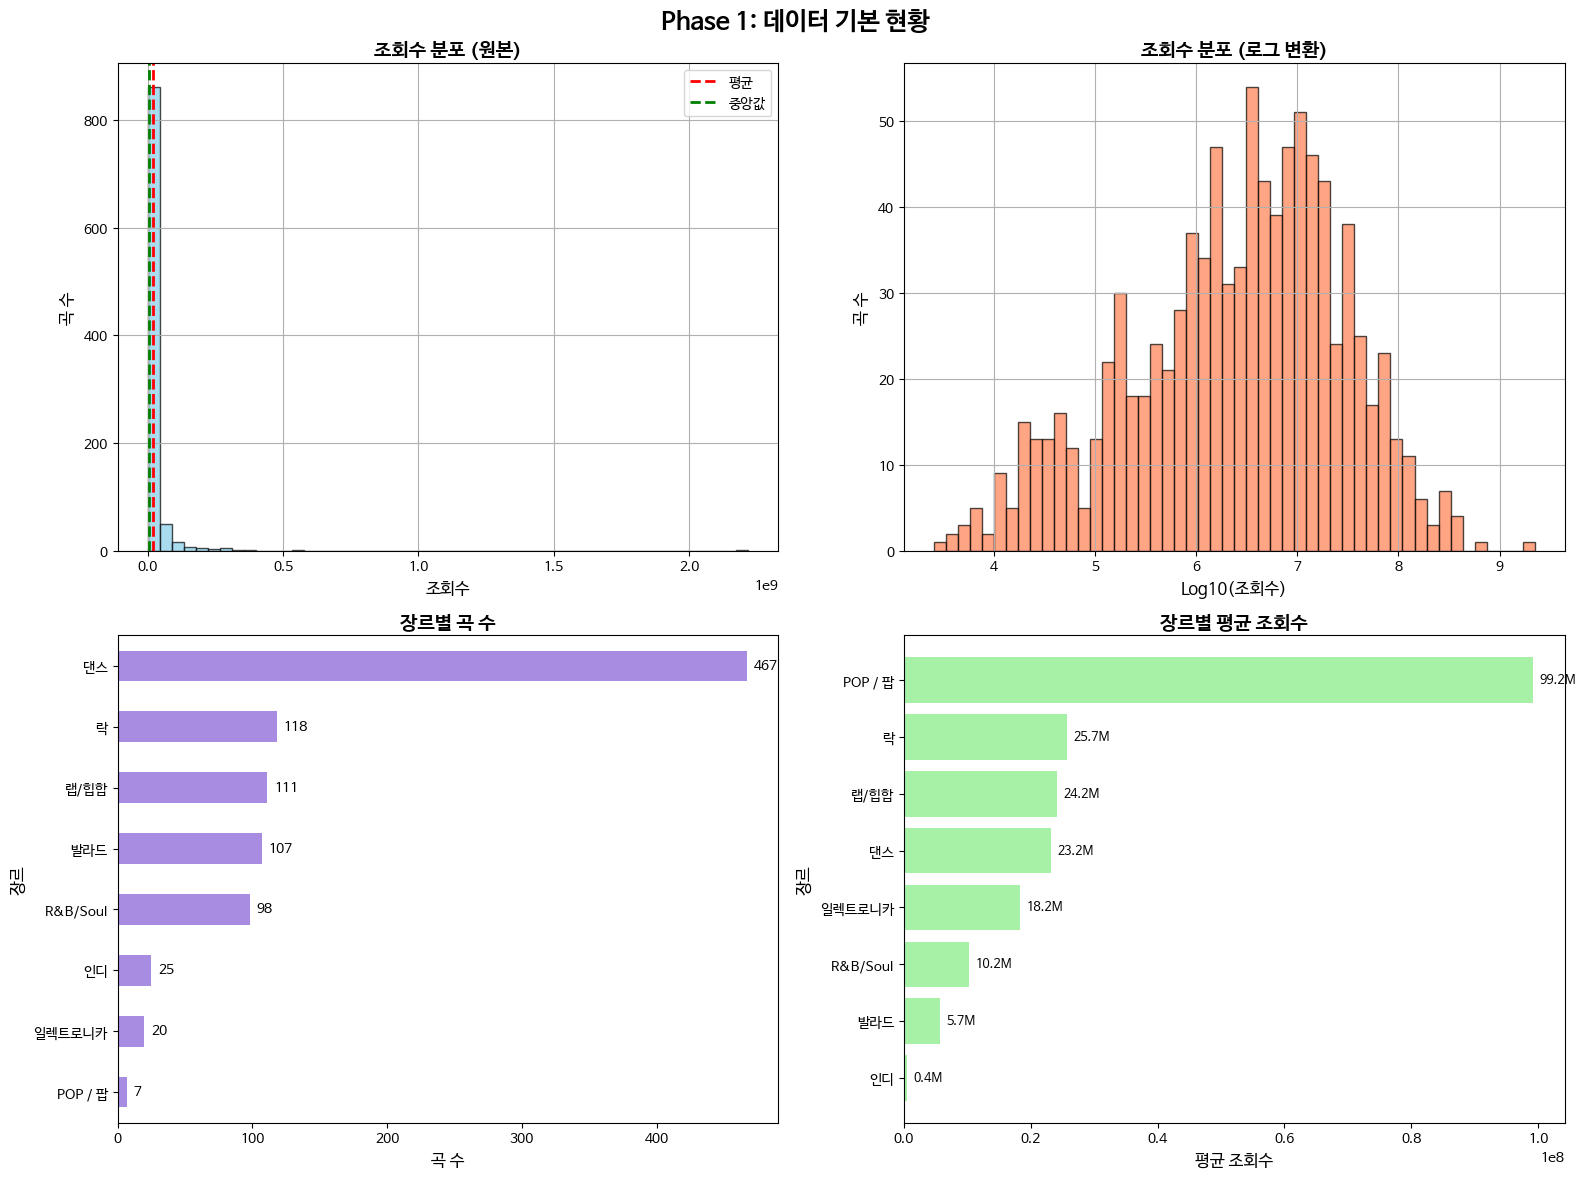

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, ttest_ind, chi2_contingency, pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("husl")

# 출력 폴더 생성
import os
os.makedirs('lyrics_eda_results', exist_ok=True)

print("="*100)
print("🎵 K-POP 뮤직비디오 가사 특성 종합 EDA 시작")
print("="*100)

# ============================================
# PHASE 1: 데이터 이해하기 (Foundation)
# ============================================

print("\n" + "="*100)
print("PHASE 1: 데이터 이해하기")
print("="*100)

# 1.1 기본 통계
print("\n[1.1 데이터 기본 정보]")
print(f"총 곡 수: {len(df_final)}")
print(f"총 변수 수: {len(df_final.columns)}")
print(f"\n데이터 타입:")
print(df_final.dtypes.value_counts())

# 결측치 확인
print(f"\n결측치 현황:")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final) * 100).round(2)
missing_df = pd.DataFrame({
    '결측치 수': missing[missing > 0],
    '결측치 비율(%)': missing_pct[missing > 0]
})
print(missing_df.to_string())

# 연도 정보가 있다면 추출 (publishTime에서)
df_final['year'] = pd.to_datetime(df_final['publishTime']).dt.year
print(f"\n연도별 분포:")
print(df_final['year'].value_counts().sort_index())

# 가사 변수 정의
lyrics_features = [
    'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'token_count', 'unique_token_ratio', 'repeated_token_ratio', 'avg_token_length',
    'hapax_legomenon', 'hapax_dislegomenon', 'hapax_trislegomenon',
    'line_count', 'avg_tokens_per_line', 'unique_tokens_per_line',
    'punctuation_ratio', 'compression_rate', 'pronoun_frequency',
    'korean_ratio', 'english_ratio'
]

# 기술 통계량
print(f"\n가사 변수 기술 통계량:")
desc_stats = df_final[lyrics_features].describe().T
desc_stats['skewness'] = df_final[lyrics_features].skew()
desc_stats['kurtosis'] = df_final[lyrics_features].kurtosis()
print(desc_stats.to_string())
desc_stats.to_csv('lyrics_eda_results/01_descriptive_statistics.csv', encoding='utf-8-sig')

# 조회수 기본 분석
print(f"\n조회수 기본 통계:")
print(df_final['api_view_count'].describe())
print(f"\n조회수 구간별 분포:")
view_bins = [0, 1e6, 10e6, 50e6, 100e6, np.inf]
view_labels = ['<1M', '1-10M', '10-50M', '50-100M', '>100M']
df_final['view_segment'] = pd.cut(df_final['api_view_count'], bins=view_bins, labels=view_labels)
print(df_final['view_segment'].value_counts().sort_index())

# 1.2 장르 분포
print(f"\n[1.2 장르 분포]")
genre_stats = df_final.groupby('genie_genre').agg({
    'api_view_count': ['count', 'mean', 'median', 'std']
}).round(0)
genre_stats.columns = ['곡수', '평균_조회수', '중앙값_조회수', '표준편차']
genre_stats = genre_stats.sort_values('평균_조회수', ascending=False)
print(genre_stats.to_string())
genre_stats.to_csv('lyrics_eda_results/01_genre_distribution.csv', encoding='utf-8-sig')

# Phase 1 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 1: 데이터 기본 현황', fontsize=18, fontweight='bold')

# 1. 조회수 분포
ax1 = axes[0, 0]
df_final['api_view_count'].hist(bins=50, ax=ax1, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('조회수', fontsize=12)
ax1.set_ylabel('곡 수', fontsize=12)
ax1.set_title('조회수 분포 (원본)', fontsize=14, fontweight='bold')
ax1.axvline(df_final['api_view_count'].mean(), color='red', linestyle='--', linewidth=2, label='평균')
ax1.axvline(df_final['api_view_count'].median(), color='green', linestyle='--', linewidth=2, label='중앙값')
ax1.legend()

# 2. 조회수 분포 (로그 변환)
ax2 = axes[0, 1]
np.log10(df_final['api_view_count'] + 1).hist(bins=50, ax=ax2, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Log10(조회수)', fontsize=12)
ax2.set_ylabel('곡 수', fontsize=12)
ax2.set_title('조회수 분포 (로그 변환)', fontsize=14, fontweight='bold')

# 3. 장르별 곡 수
ax3 = axes[1, 0]
genre_counts = df_final['genie_genre'].value_counts().sort_values(ascending=True)
genre_counts.plot(kind='barh', ax=ax3, color='mediumpurple', alpha=0.8)
ax3.set_xlabel('곡 수', fontsize=12)
ax3.set_ylabel('장르', fontsize=12)
ax3.set_title('장르별 곡 수', fontsize=14, fontweight='bold')
for i, v in enumerate(genre_counts.values):
    ax3.text(v + 5, i, str(v), va='center', fontsize=10)

# 4. 장르별 평균 조회수
ax4 = axes[1, 1]
genre_views = df_final.groupby('genie_genre')['api_view_count'].mean().sort_values(ascending=True)
bars = ax4.barh(range(len(genre_views)), genre_views.values, color='lightgreen', alpha=0.8)
ax4.set_yticks(range(len(genre_views)))
ax4.set_yticklabels(genre_views.index)
ax4.set_xlabel('평균 조회수', fontsize=12)
ax4.set_ylabel('장르', fontsize=12)
ax4.set_title('장르별 평균 조회수', fontsize=14, fontweight='bold')
for i, v in enumerate(genre_views.values):
    ax4.text(v + 1e6, i, f'{v/1e6:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('lyrics_eda_results/phase1_data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# 해당 video_id를 가진 모든 행을 생략 없이 출력합니다.
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    display(df_final[df_final['lyrics_cleaned'].isnull()])

,url,songName,artists,publishTime,video_id,api_view_count,api_like_count,api_comment_count,api_published_at,api_duration,api_title,api_channel_title,valence_raw,arousal_raw,valence_normalized,arousal_normalized,energy,energy_variance,loudness,tempo,duration_ms,speechiness,speech_duration_sec,spectral_flatness,harmonic_ratio,acoustic_score,sentiment_compound,sentiment_positive,sentiment_negative,sentiment_neutral,avg_brightness,avg_motion,avg_r_value,avg_g_value,avg_b_value,frames_analyzed,video_duration,video_fps,days_since_release,avg_daily_view,token_count,unique_token_ratio,repeated_token_ratio,avg_token_length,hapax_legomenon,hapax_dislegomenon,hapax_trislegomenon,unique_tokens_per_line,avg_tokens_per_line,line_count,punctuation_ratio,compression_rate,pronoun_frequency,positive_emotion_ratio,negative_emotion_ratio,korean_ratio,english_ratio,genie_genre,sentiment_congruence,lyrics_cleaned,lyrics_complexity_index,is_high_unique,year,view_segment
278,https://www.youtube.com/watch?v=xx8qT6H8bkM,YURA YURA,2598|ZEROBASEONE|ZEROBASEONE|1,2024.03.08,xx8qT6H8bkM,13744698,259700,21661,2024-03-07 15:00:50,PT3M13S,ZEROBASEONE (제로베이스원) 'ゆらゆら -運命の花-' MV,ZEROBASEONE,6.523098,5.993885,0.690387,0.624236,0.282168,0.121097,-10.989807,160.714286,192609.0,0.565732,108.965410,0.017031,0.633569,0.622779,0.7095,0.8547,0.1453,0.2905,106.80,43.15,109.84,103.70,115.21,154.0,192.61,23.98,299,45968.889632,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,댄스,0.164313,NaN,0.000000,False,2024,10-50M
281,https://www.youtube.com/watch?v=DLKgKmc0Qlk,Keep on Moving,2960|NEXZ (넥스지)|NEXZ|1,2024.08.20,DLKgKmc0Qlk,6072590,56349,5751,2024-08-20 14:59:59,PT3M19S,"NEXZ ""Keep on Moving"" M/V",JYP Entertainment,6.362846,6.073467,0.670356,0.634183,0.234682,0.126817,-12.590355,108.173077,198867.0,0.626735,124.637118,0.053568,0.597742,0.565722,0.8129,0.9065,0.0935,0.1871,108.88,54.23,98.65,112.71,116.28,159.0,198.87,23.98,133,45658.571429,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,댄스,0.236144,NaN,0.000000,False,2024,1-10M
381,https://www.youtube.com/watch?v=ZgrEZmAgzM8,WISH (Japanese Ver.),2859|NCT WISH|NCTWISH|1,2024.02.28,ZgrEZmAgzM8,7519200,88381,2880,2024-02-28 09:00:14,PT4M13S,NCT WISH 엔시티 위시 'WISH (Japanese Ver.)' MV,SMTOWN,5.826115,5.007436,0.603264,0.500930,0.259445,0.154182,-11.719045,98.684211,252760.0,0.061958,15.660674,0.014883,0.573303,0.564771,0.7843,0.8921,0.1079,0.2157,102.52,54.87,96.06,107.61,93.61,202.0,252.75,23.98,307,24492.508143,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,댄스,0.288836,NaN,0.000000,False,2024,1-10M
396,https://www.youtube.com/watch?v=1XIi9ofX2kE,Hate Rodrigo (Feat. 우기 ((여자)아이들)),695|YENA (최예나)|YENA|1,2023.06.30,1XIi9ofX2kE,12653742,206609,10398,2023-06-30 06:00:15,PT3M49S,YENA (최예나) - Hate Rodrigo (Feat. 우기 ((여자)아이들)) MV,Stone Music Entertainment,6.832271,5.631468,0.729034,0.578934,0.351016,0.129771,-9.093449,170.454545,227938.0,0.524418,119.535044,0.004720,0.597169,0.594350,0.8053,0.9026,0.0974,0.1947,105.50,54.37,119.44,96.94,113.32,183.0,227.92,24.00,550,23006.803636,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,락,0.173566,NaN,0.000000,False,2023,10-50M
405,https://www.youtube.com/watch?v=2ZdVzQRkS4c,Done,3010|nævis (나이비스)|naevis|0,2024.09.10,2ZdVzQRkS4c,2459871,125876,6423,2024-09-10 09:00:04,PT3M16S,nævis 나이비스 'Done' MV,SMTOWN,5.461504,4.565871,0.557688,0.445734,0.211034,0.145145,-13.512897,148.026316,195918.0,0.318683,62.435856,0.011298,0.758819,0.750245,0.7426,0.8713,0.1287,0.2574,77.27,48.20,65.88,80.63,90.24,157.0,195.90,23.98,112,21963.133929,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0000,0.0000,0.0000,0.00,0.0000,0.0000,0.0000,댄스,0.313612,NaN,0.000000,False,2024,1-10M
408,https://www.youtube.com/watch?v=hvQZs3k6Ytk,WISH (Korean Ver.),2859|NCT WISH|NCTWISH|1,2024.02.28,hvQZs3k6Ytk,6619937,201304,5952,2024-02-28 09:00:03,PT4M2

### 1-3. 전반적 EDA — Phase 2: 단변량 분석
주요 변수들의 분포(히스토그램/박스플롯)를 개별적으로 확인합니다.


PHASE 2: 단변량 분석

[2.1 감정 변수 분석]
                    count      mean       std     min     25%     50%     75%  \
sentiment_compound  953.0  0.785394  0.232266 -0.9440  0.7347  0.8535  0.9283   
sentiment_positive  953.0  0.892696  0.116131  0.0280  0.8673  0.9267  0.9642   
sentiment_negative  953.0  0.107304  0.116131  0.0063  0.0358  0.0733  0.1327   
sentiment_neutral   953.0  0.200205  0.176338  0.0125  0.0715  0.1465  0.2648   

                       max  
sentiment_compound  0.9875  
sentiment_positive  0.9937  
sentiment_negative  0.9720  
sentiment_neutral   0.9971  

감정 카테고리 분포:
emotion_category
긍정적    936
부정적     16
중립       1
Name: count, dtype: int64

[2.2 복잡도/다양성 변수 분석]
                      count        mean         std  min       25%       50%  \
token_count           953.0  605.516264  673.795606  0.0  361.0000  492.0000   
unique_token_ratio    953.0    0.340915    0.096313  0.0    0.2721    0.3326   
repeated_token_ratio  953.0    0.651740    0.107525  0.0    0.5992

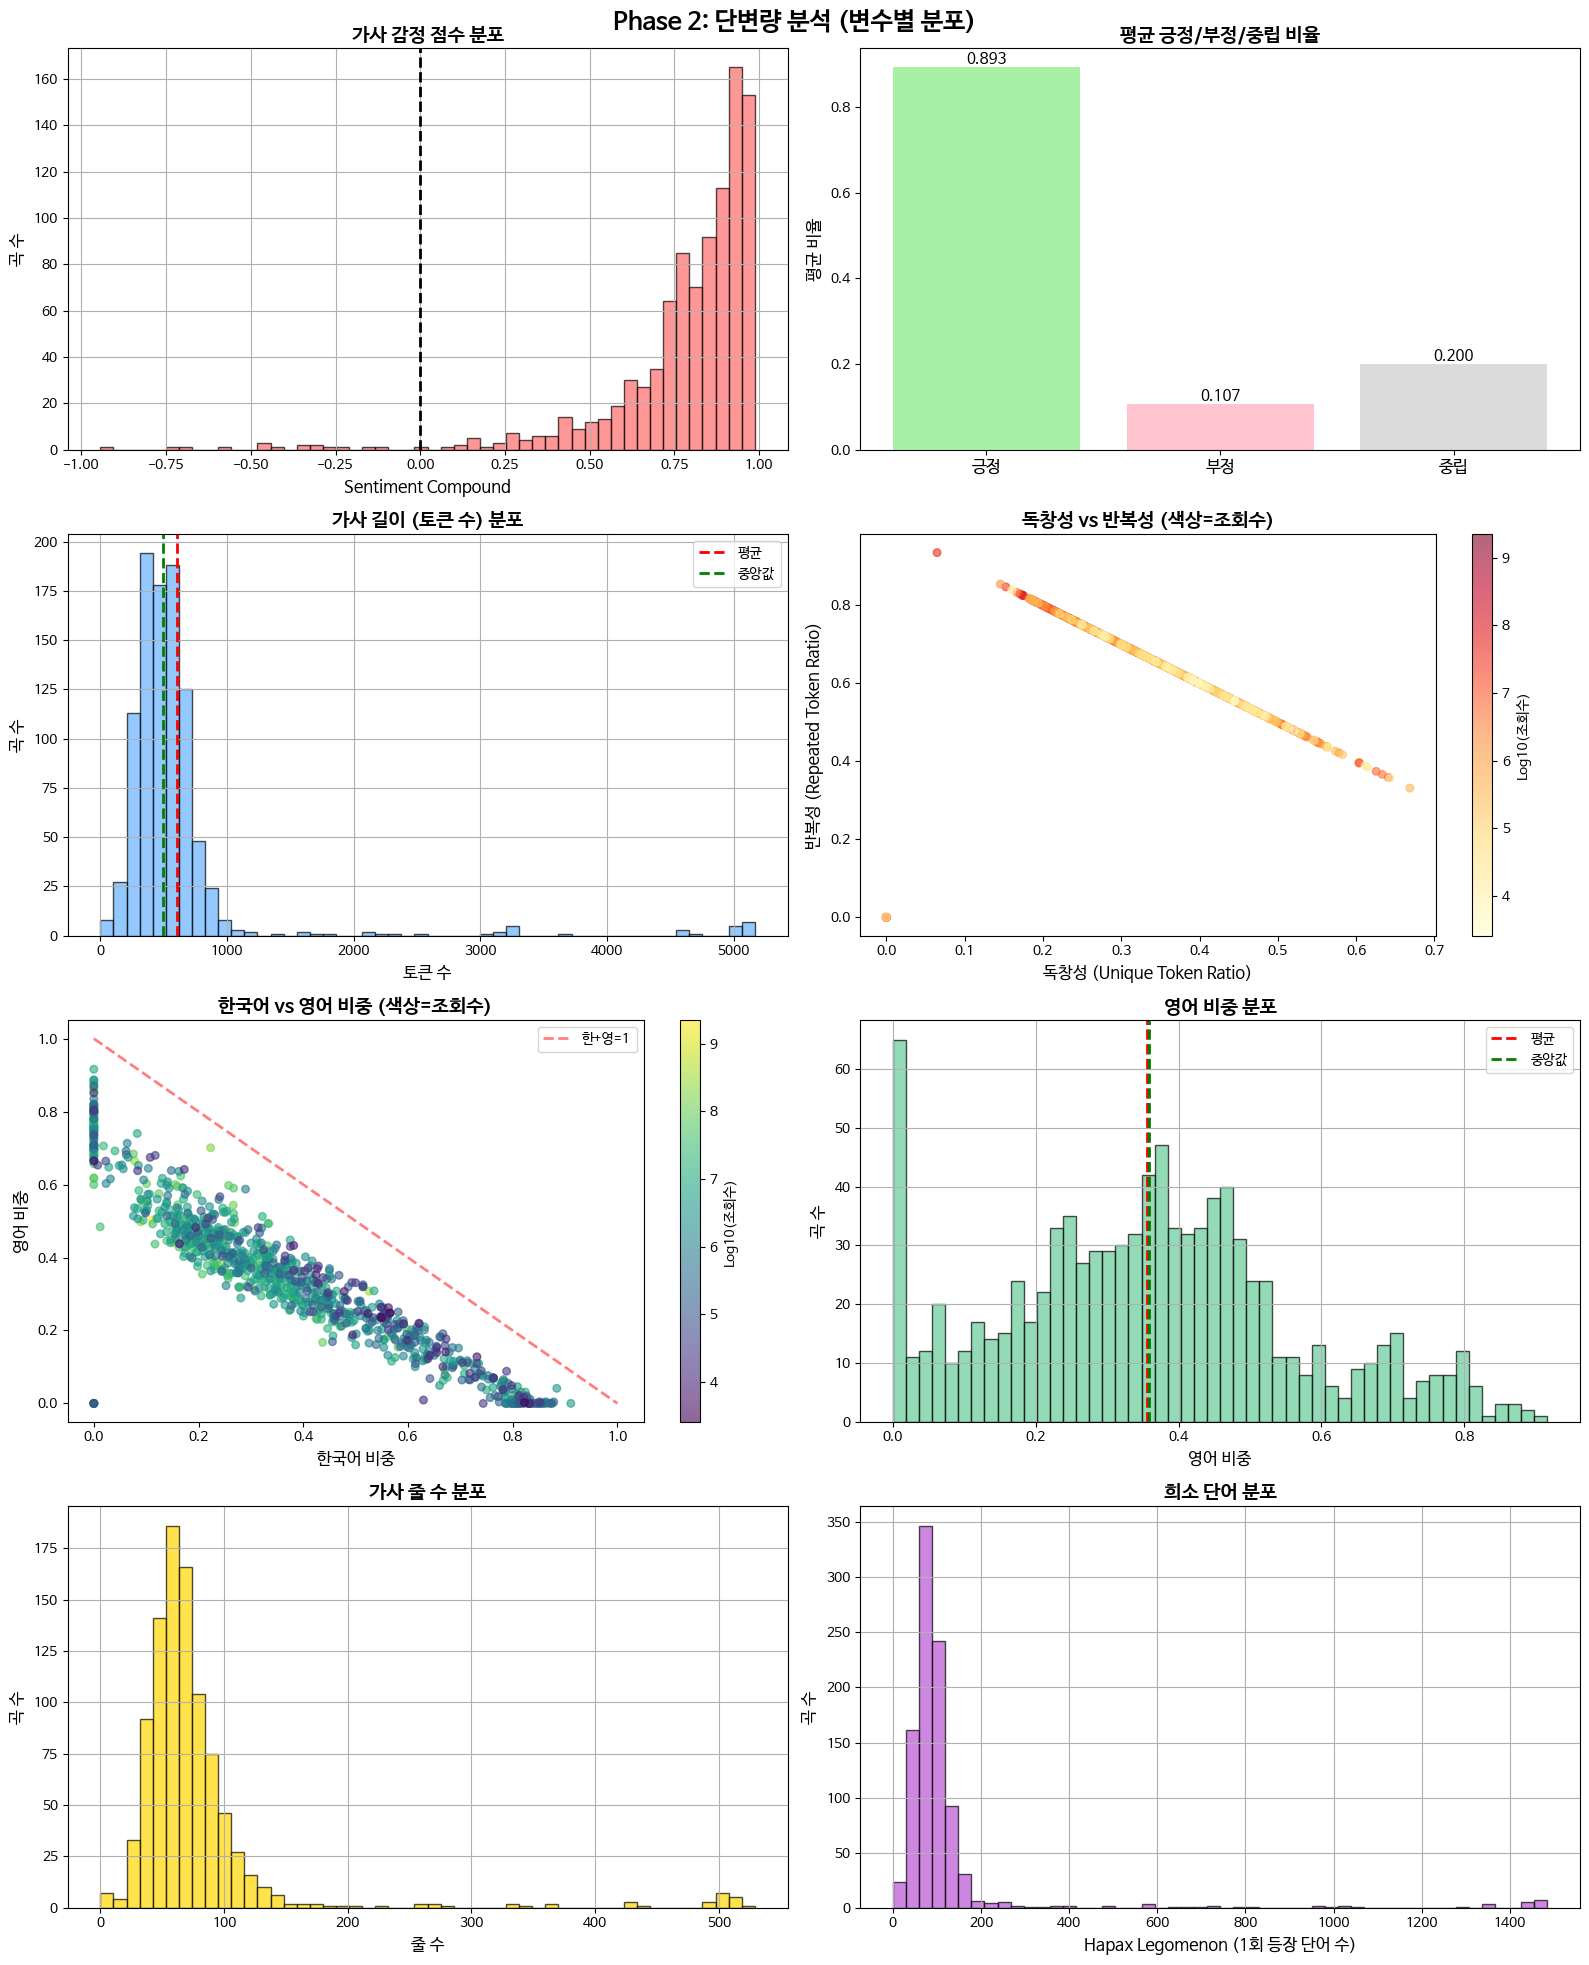

In [ ]:
# ============================================
# PHASE 2: 단변량 분석 (각 변수 깊게 파기)
# ============================================

print("\n" + "="*100)
print("PHASE 2: 단변량 분석")
print("="*100)

# 2.1 감정 변수
print("\n[2.1 감정 변수 분석]")
sentiment_vars = ['sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral']
print(df_final[sentiment_vars].describe().T)

# 감정 분류
df_final['emotion_category'] = pd.cut(
    df_final['sentiment_compound'],
    bins=[-1, -0.05, 0.05, 1],
    labels=['부정적', '중립', '긍정적']
)
print(f"\n감정 카테고리 분포:")
print(df_final['emotion_category'].value_counts())

# 2.2 복잡도/다양성 변수
print("\n[2.2 복잡도/다양성 변수 분석]")
complexity_vars = ['token_count', 'unique_token_ratio', 'repeated_token_ratio', 'avg_token_length']
print(df_final[complexity_vars].describe().T)

print(f"\n독창성 vs 반복성 상관관계: {df_final['unique_token_ratio'].corr(df_final['repeated_token_ratio']):.4f}")

# 2.3 언어 변수 (중요!)
print("\n[2.3 언어 변수 분석]")
print(f"\n한국어 비중 분포:")
print(df_final['korean_ratio'].describe())
print(f"\n영어 비중 분포:")
print(df_final['english_ratio'].describe())

# 언어 카테고리
df_final['language_category'] = pd.cut(
    df_final['english_ratio'],
    bins=[-0.01, 0.1, 0.3, 0.5, 0.7, 1.01],
    labels=['거의 한국어', '한국어 위주', '혼합', '영어 위주', '거의 영어']
)
print(f"\n언어 카테고리 분포:")
print(df_final['language_category'].value_counts().sort_index())

# Phase 2 시각화 (8개 subplot)
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('Phase 2: 단변량 분석 (변수별 분포)', fontsize=18, fontweight='bold')

# 1. 감정 점수 분포
ax1 = axes[0, 0]
df_final['sentiment_compound'].hist(bins=50, ax=ax1, color='#FF6B6B', edgecolor='black', alpha=0.7)
ax1.axvline(0, color='black', linestyle='--', linewidth=2)
ax1.set_xlabel('Sentiment Compound', fontsize=12)
ax1.set_ylabel('곡 수', fontsize=12)
ax1.set_title('가사 감정 점수 분포', fontsize=14, fontweight='bold')

# 2. 긍정/부정/중립 비율
ax2 = axes[0, 1]
sentiment_means = df_final[['sentiment_positive', 'sentiment_negative', 'sentiment_neutral']].mean()
colors = ['#90EE90', '#FFB6C1', '#D3D3D3']
bars = ax2.bar(range(len(sentiment_means)), sentiment_means.values, color=colors, alpha=0.8)
ax2.set_xticks(range(len(sentiment_means)))
ax2.set_xticklabels(['긍정', '부정', '중립'], fontsize=12)
ax2.set_ylabel('평균 비율', fontsize=12)
ax2.set_title('평균 긍정/부정/중립 비율', fontsize=14, fontweight='bold')
for bar, val in zip(bars, sentiment_means.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11)

# 3. 토큰 수 분포
ax3 = axes[1, 0]
df_final['token_count'].hist(bins=50, ax=ax3, color='#66B2FF', edgecolor='black', alpha=0.7)
ax3.axvline(df_final['token_count'].mean(), color='red', linestyle='--', linewidth=2, label='평균')
ax3.axvline(df_final['token_count'].median(), color='green', linestyle='--', linewidth=2, label='중앙값')
ax3.set_xlabel('토큰 수', fontsize=12)
ax3.set_ylabel('곡 수', fontsize=12)
ax3.set_title('가사 길이 (토큰 수) 분포', fontsize=14, fontweight='bold')
ax3.legend()

# 4. 독창성 vs 반복성 산점도
ax4 = axes[1, 1]
scatter = ax4.scatter(df_final['unique_token_ratio'], df_final['repeated_token_ratio'],
                     c=np.log10(df_final['api_view_count']+1), cmap='YlOrRd', alpha=0.6, s=30)
ax4.set_xlabel('독창성 (Unique Token Ratio)', fontsize=12)
ax4.set_ylabel('반복성 (Repeated Token Ratio)', fontsize=12)
ax4.set_title('독창성 vs 반복성 (색상=조회수)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax4, label='Log10(조회수)')

# 5. 한국어 vs 영어 비중
ax5 = axes[2, 0]
scatter = ax5.scatter(df_final['korean_ratio'], df_final['english_ratio'],
                     c=np.log10(df_final['api_view_count']+1), cmap='viridis', alpha=0.6, s=30)
ax5.plot([0, 1], [1, 0], 'r--', linewidth=2, alpha=0.5, label='한+영=1')
ax5.set_xlabel('한국어 비중', fontsize=12)
ax5.set_ylabel('영어 비중', fontsize=12)
ax5.set_title('한국어 vs 영어 비중 (색상=조회수)', fontsize=14, fontweight='bold')
ax5.legend()
plt.colorbar(scatter, ax=ax5, label='Log10(조회수)')

# 6. 영어 비중 분포
ax6 = axes[2, 1]
df_final['english_ratio'].hist(bins=50, ax=ax6, color='#66CC99', edgecolor='black', alpha=0.7)
ax6.axvline(df_final['english_ratio'].mean(), color='red', linestyle='--', linewidth=2, label='평균')
ax6.axvline(df_final['english_ratio'].median(), color='green', linestyle='--', linewidth=2, label='중앙값')
ax6.set_xlabel('영어 비중', fontsize=12)
ax6.set_ylabel('곡 수', fontsize=12)
ax6.set_title('영어 비중 분포', fontsize=14, fontweight='bold')
ax6.legend()

# 7. 줄 수 분포
ax7 = axes[3, 0]
df_final['line_count'].hist(bins=50, ax=ax7, color='#FFD700', edgecolor='black', alpha=0.7)
ax7.set_xlabel('줄 수', fontsize=12)
ax7.set_ylabel('곡 수', fontsize=12)
ax7.set_title('가사 줄 수 분포', fontsize=14, fontweight='bold')

# 8. Hapax Legomenon 분포
ax8 = axes[3, 1]
df_final['hapax_legomenon'].hist(bins=50, ax=ax8, color='#BA55D3', edgecolor='black', alpha=0.7)
ax8.set_xlabel('Hapax Legomenon (1회 등장 단어 수)', fontsize=12)
ax8.set_ylabel('곡 수', fontsize=12)
ax8.set_title('희소 단어 분포', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('lyrics_eda_results/phase2_univariate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 1-4. 전반적 EDA — Phase 3: 타겟변수(조회수) 관계 분석
각 변수와 조회수 간의 관계(상관관계, 산점도)를 탐색합니다.


PHASE 3: 타겟 변수(조회수)와의 관계

[3.1 상관관계 분석]
                        변수      상관계수       p-value  유의함        효과크기
17            korean_ratio -0.166632  2.297466e-07  Yes       Small
18           english_ratio  0.153626  1.892136e-06  Yes       Small
5       unique_token_ratio -0.133194  3.710739e-05  Yes       Small
6     repeated_token_ratio  0.129964  5.724148e-05  Yes       Small
15        compression_rate -0.120307  1.971597e-04  Yes       Small
7         avg_token_length  0.116768  3.034434e-04  Yes       Small
14       punctuation_ratio  0.104733  1.204310e-03  Yes       Small
10     hapax_trislegomenon -0.055639  8.603413e-02   No  Negligible
3        sentiment_neutral  0.053391  9.950782e-02   No  Negligible
12     avg_tokens_per_line  0.052797  1.033358e-01   No  Negligible
8          hapax_legomenon -0.046167  1.544168e-01   No  Negligible
9       hapax_dislegomenon -0.039117  2.276430e-01   No  Negligible
0       sentiment_compound -0.034685  2.847685e-01   No  Negligible
2      

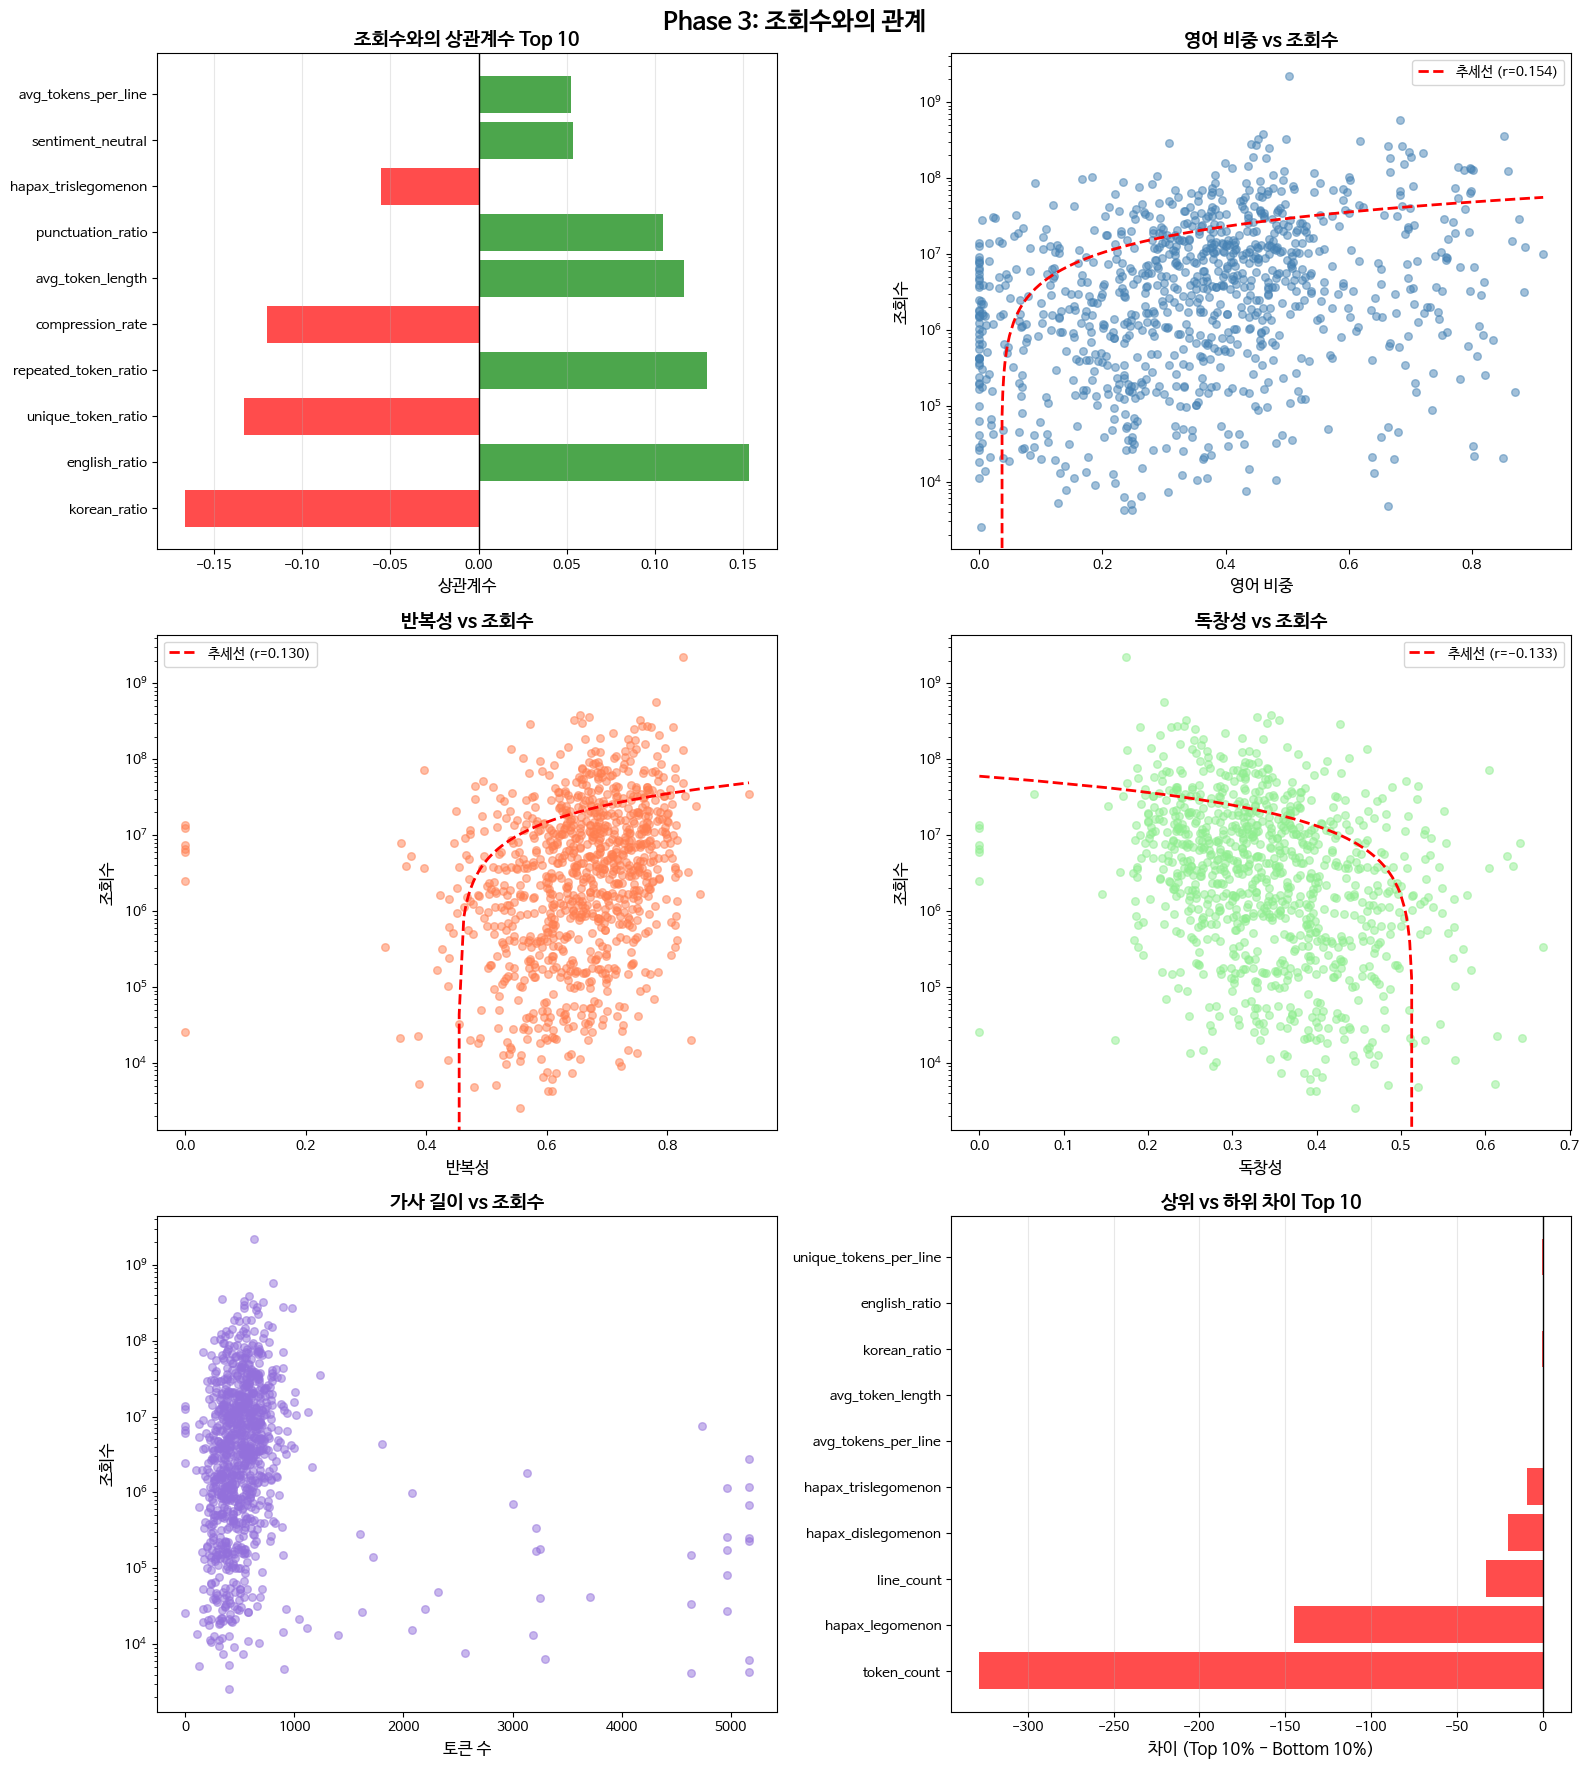

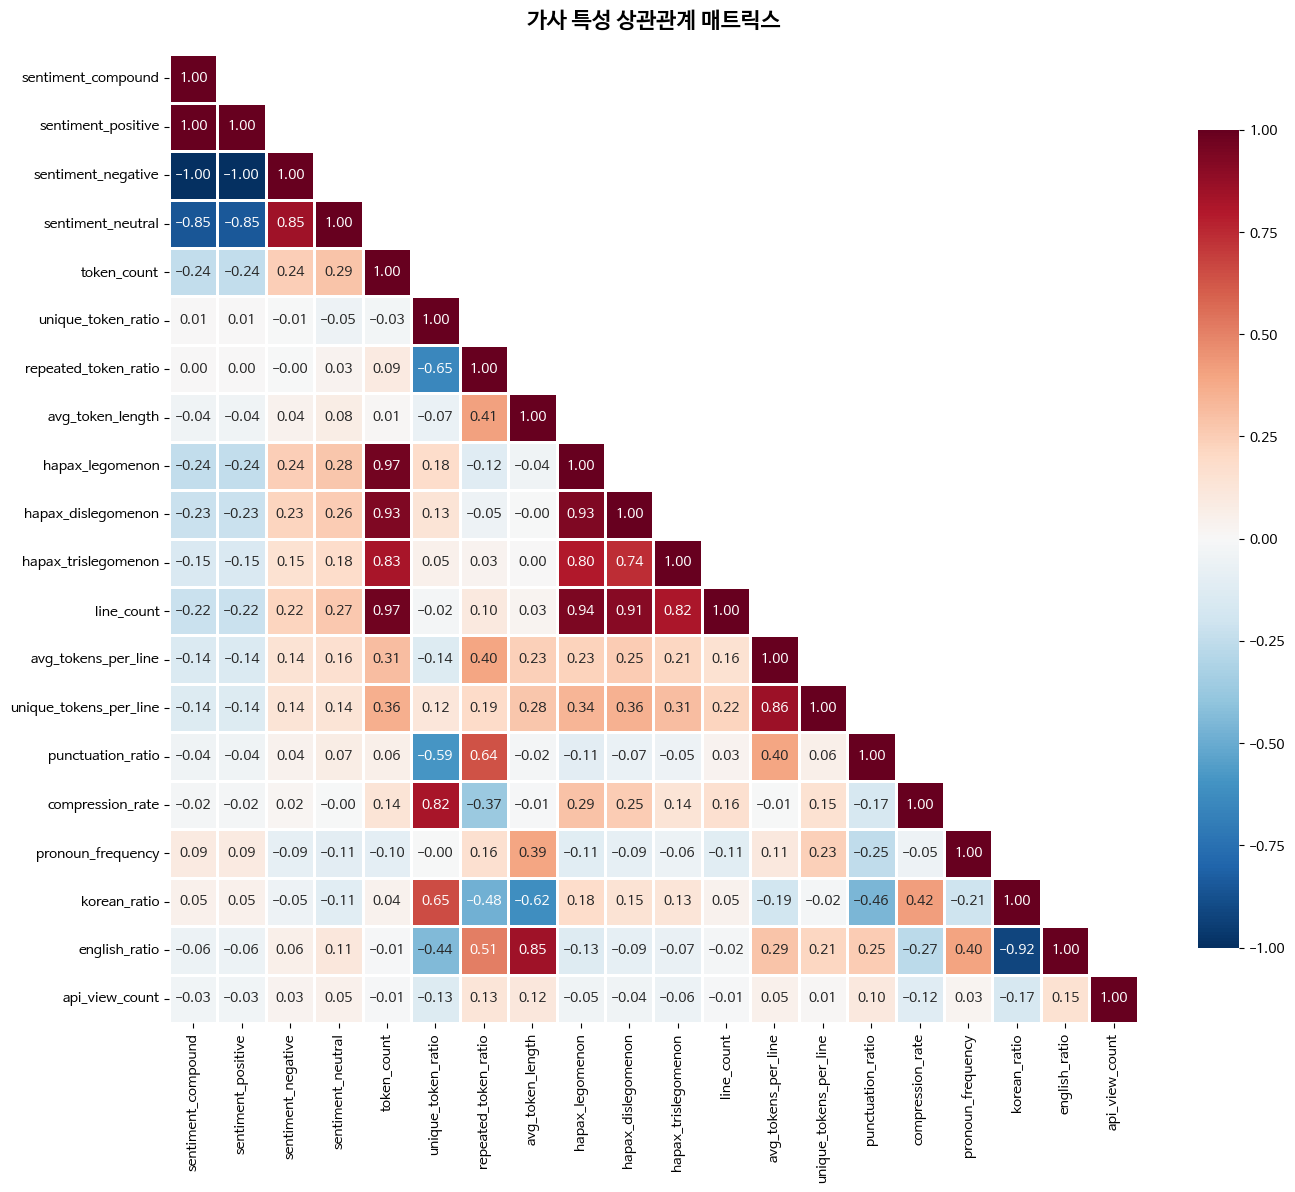


✅ Phase 1-3 완료! 파일 저장됨
계속하려면 엔터를 누르세요...


In [ ]:
# ============================================
# PHASE 3: 타겟 변수와의 관계
# ============================================

print("\n" + "="*100)
print("PHASE 3: 타겟 변수(조회수)와의 관계")
print("="*100)

# 3.1 상관관계 분석
print("\n[3.1 상관관계 분석]")
correlations = []
for feature in lyrics_features:
    corr, pval = pearsonr(df_final[feature], df_final['api_view_count'])
    correlations.append({
        '변수': feature,
        '상관계수': corr,
        'p-value': pval,
        '유의함': 'Yes' if pval < 0.05 else 'No',
        '효과크기': 'Large' if abs(corr) > 0.5 else 'Medium' if abs(corr) > 0.3 else 'Small' if abs(corr) > 0.1 else 'Negligible'
    })

corr_df = pd.DataFrame(correlations).sort_values('상관계수', key=abs, ascending=False)
print(corr_df.to_string())
corr_df.to_csv('lyrics_eda_results/03_correlation_with_views.csv', index=False, encoding='utf-8-sig')

# 3.2 조회수 구간별 분석
print("\n[3.2 조회수 구간별 분석]")
quantiles = [0, 0.1, 0.25, 0.75, 0.9, 1.0]
labels = ['Bottom 10%', 'Low 25%', 'Middle 50%', 'Top 25%', 'Top 10%']
df_final['view_quantile'] = pd.qcut(df_final['api_view_count'], q=quantiles, labels=labels, duplicates='drop')

segment_analysis = df_final.groupby('view_quantile')[lyrics_features].mean()
print(segment_analysis.to_string())
segment_analysis.to_csv('lyrics_eda_results/03_segment_analysis.csv', encoding='utf-8-sig')

# 상위 vs 하위 비교
top_10 = df_final[df_final['api_view_count'] >= df_final['api_view_count'].quantile(0.9)]
bottom_10 = df_final[df_final['api_view_count'] <= df_final['api_view_count'].quantile(0.1)]

comparison = []
for feature in lyrics_features:
    top_mean = top_10[feature].mean()
    bottom_mean = bottom_10[feature].mean()
    diff = top_mean - bottom_mean
    pct_change = (diff / bottom_mean * 100) if bottom_mean != 0 else 0

    # t-test
    t_stat, p_val = ttest_ind(top_10[feature].dropna(), bottom_10[feature].dropna())

    comparison.append({
        '변수': feature,
        'Top_10%': top_mean,
        'Bottom_10%': bottom_mean,
        '차이': diff,
        '변화율(%)': pct_change,
        't-statistic': t_stat,
        'p-value': p_val,
        '유의함': 'Yes' if p_val < 0.05 else 'No'
    })

comparison_df = pd.DataFrame(comparison).sort_values('차이', key=abs, ascending=False)
print("\n상위 10% vs 하위 10% 비교:")
print(comparison_df.to_string())
comparison_df.to_csv('lyrics_eda_results/03_top_vs_bottom.csv', index=False, encoding='utf-8-sig')

# Phase 3 시각화
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Phase 3: 조회수와의 관계', fontsize=18, fontweight='bold')

# 1. 상관계수 Top 10
ax1 = axes[0, 0]
top_corr = corr_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top_corr['상관계수']]
bars = ax1.barh(range(len(top_corr)), top_corr['상관계수'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(top_corr)))
ax1.set_yticklabels(top_corr['변수'], fontsize=10)
ax1.set_xlabel('상관계수', fontsize=12)
ax1.set_title('조회수와의 상관계수 Top 10', fontsize=14, fontweight='bold')
ax1.axvline(0, color='black', linestyle='-', linewidth=1)
ax1.grid(axis='x', alpha=0.3)

# 2. 영어 비중 vs 조회수
ax2 = axes[0, 1]
ax2.scatter(df_final['english_ratio'], df_final['api_view_count'],
           alpha=0.5, s=30, c='steelblue')
z = np.polyfit(df_final['english_ratio'], df_final['api_view_count'], 1)
p = np.poly1d(z)
ax2.plot(df_final['english_ratio'].sort_values(), p(df_final['english_ratio'].sort_values()),
        "r--", linewidth=2, label=f'추세선 (r={corr_df[corr_df["변수"]=="english_ratio"]["상관계수"].values[0]:.3f})')
ax2.set_xlabel('영어 비중', fontsize=12)
ax2.set_ylabel('조회수', fontsize=12)
ax2.set_title('영어 비중 vs 조회수', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_yscale('log')

# 3. 반복성 vs 조회수
ax3 = axes[1, 0]
ax3.scatter(df_final['repeated_token_ratio'], df_final['api_view_count'],
           alpha=0.5, s=30, c='coral')
z = np.polyfit(df_final['repeated_token_ratio'], df_final['api_view_count'], 1)
p = np.poly1d(z)
ax3.plot(df_final['repeated_token_ratio'].sort_values(), p(df_final['repeated_token_ratio'].sort_values()),
        "r--", linewidth=2, label=f'추세선 (r={corr_df[corr_df["변수"]=="repeated_token_ratio"]["상관계수"].values[0]:.3f})')
ax3.set_xlabel('반복성', fontsize=12)
ax3.set_ylabel('조회수', fontsize=12)
ax3.set_title('반복성 vs 조회수', fontsize=14, fontweight='bold')
ax3.legend()
ax3.set_yscale('log')

# 4. 독창성 vs 조회수
ax4 = axes[1, 1]
ax4.scatter(df_final['unique_token_ratio'], df_final['api_view_count'],
           alpha=0.5, s=30, c='lightgreen')
z = np.polyfit(df_final['unique_token_ratio'], df_final['api_view_count'], 1)
p = np.poly1d(z)
ax4.plot(df_final['unique_token_ratio'].sort_values(), p(df_final['unique_token_ratio'].sort_values()),
        "r--", linewidth=2, label=f'추세선 (r={corr_df[corr_df["변수"]=="unique_token_ratio"]["상관계수"].values[0]:.3f})')
ax4.set_xlabel('독창성', fontsize=12)
ax4.set_ylabel('조회수', fontsize=12)
ax4.set_title('독창성 vs 조회수', fontsize=14, fontweight='bold')
ax4.legend()
ax4.set_yscale('log')

# 5. 토큰 수 vs 조회수
ax5 = axes[2, 0]
ax5.scatter(df_final['token_count'], df_final['api_view_count'],
           alpha=0.5, s=30, c='mediumpurple')
ax5.set_xlabel('토큰 수', fontsize=12)
ax5.set_ylabel('조회수', fontsize=12)
ax5.set_title('가사 길이 vs 조회수', fontsize=14, fontweight='bold')
ax5.set_yscale('log')

# 6. 상위 vs 하위 차이 Top 10
ax6 = axes[2, 1]
top_diff = comparison_df.head(10)
colors = ['green' if x > 0 else 'red' for x in top_diff['차이']]
bars = ax6.barh(range(len(top_diff)), top_diff['차이'], color=colors, alpha=0.7)
ax6.set_yticks(range(len(top_diff)))
ax6.set_yticklabels(top_diff['변수'], fontsize=10)
ax6.set_xlabel('차이 (Top 10% - Bottom 10%)', fontsize=12)
ax6.set_title('상위 vs 하위 차이 Top 10', fontsize=14, fontweight='bold')
ax6.axvline(0, color='black', linestyle='-', linewidth=1)
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lyrics_eda_results/phase3_target_relationship.png', dpi=300, bbox_inches='tight')
plt.show()

# 상관관계 히트맵
plt.figure(figsize=(14, 12))
corr_matrix = df_final[lyrics_features + ['api_view_count']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1)
plt.title('가사 특성 상관관계 매트릭스', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('lyrics_eda_results/phase3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### 1-5. 전반적 EDA — Phase 4: 그룹 비교
장르 등 그룹별로 변수들을 비교(ANOVA 등 통계 검정 포함)합니다.


PHASE 4: 그룹별 비교 분석

[4.1 장르별 가사 특성]
             sentiment_compound  sentiment_positive  sentiment_negative  sentiment_neutral  token_count  unique_token_ratio  repeated_token_ratio  avg_token_length  hapax_legomenon  hapax_dislegomenon  hapax_trislegomenon  line_count  avg_tokens_per_line  unique_tokens_per_line  punctuation_ratio  compression_rate  pronoun_frequency  korean_ratio  english_ratio  api_view_count
genie_genre                                                                                                                                                                                                                                                                                                                                                                                
POP / 팝                0.784443            0.892229            0.107771           0.215557   568.857143            0.277943              0.722057          2.737143        81.285714           25.285714   

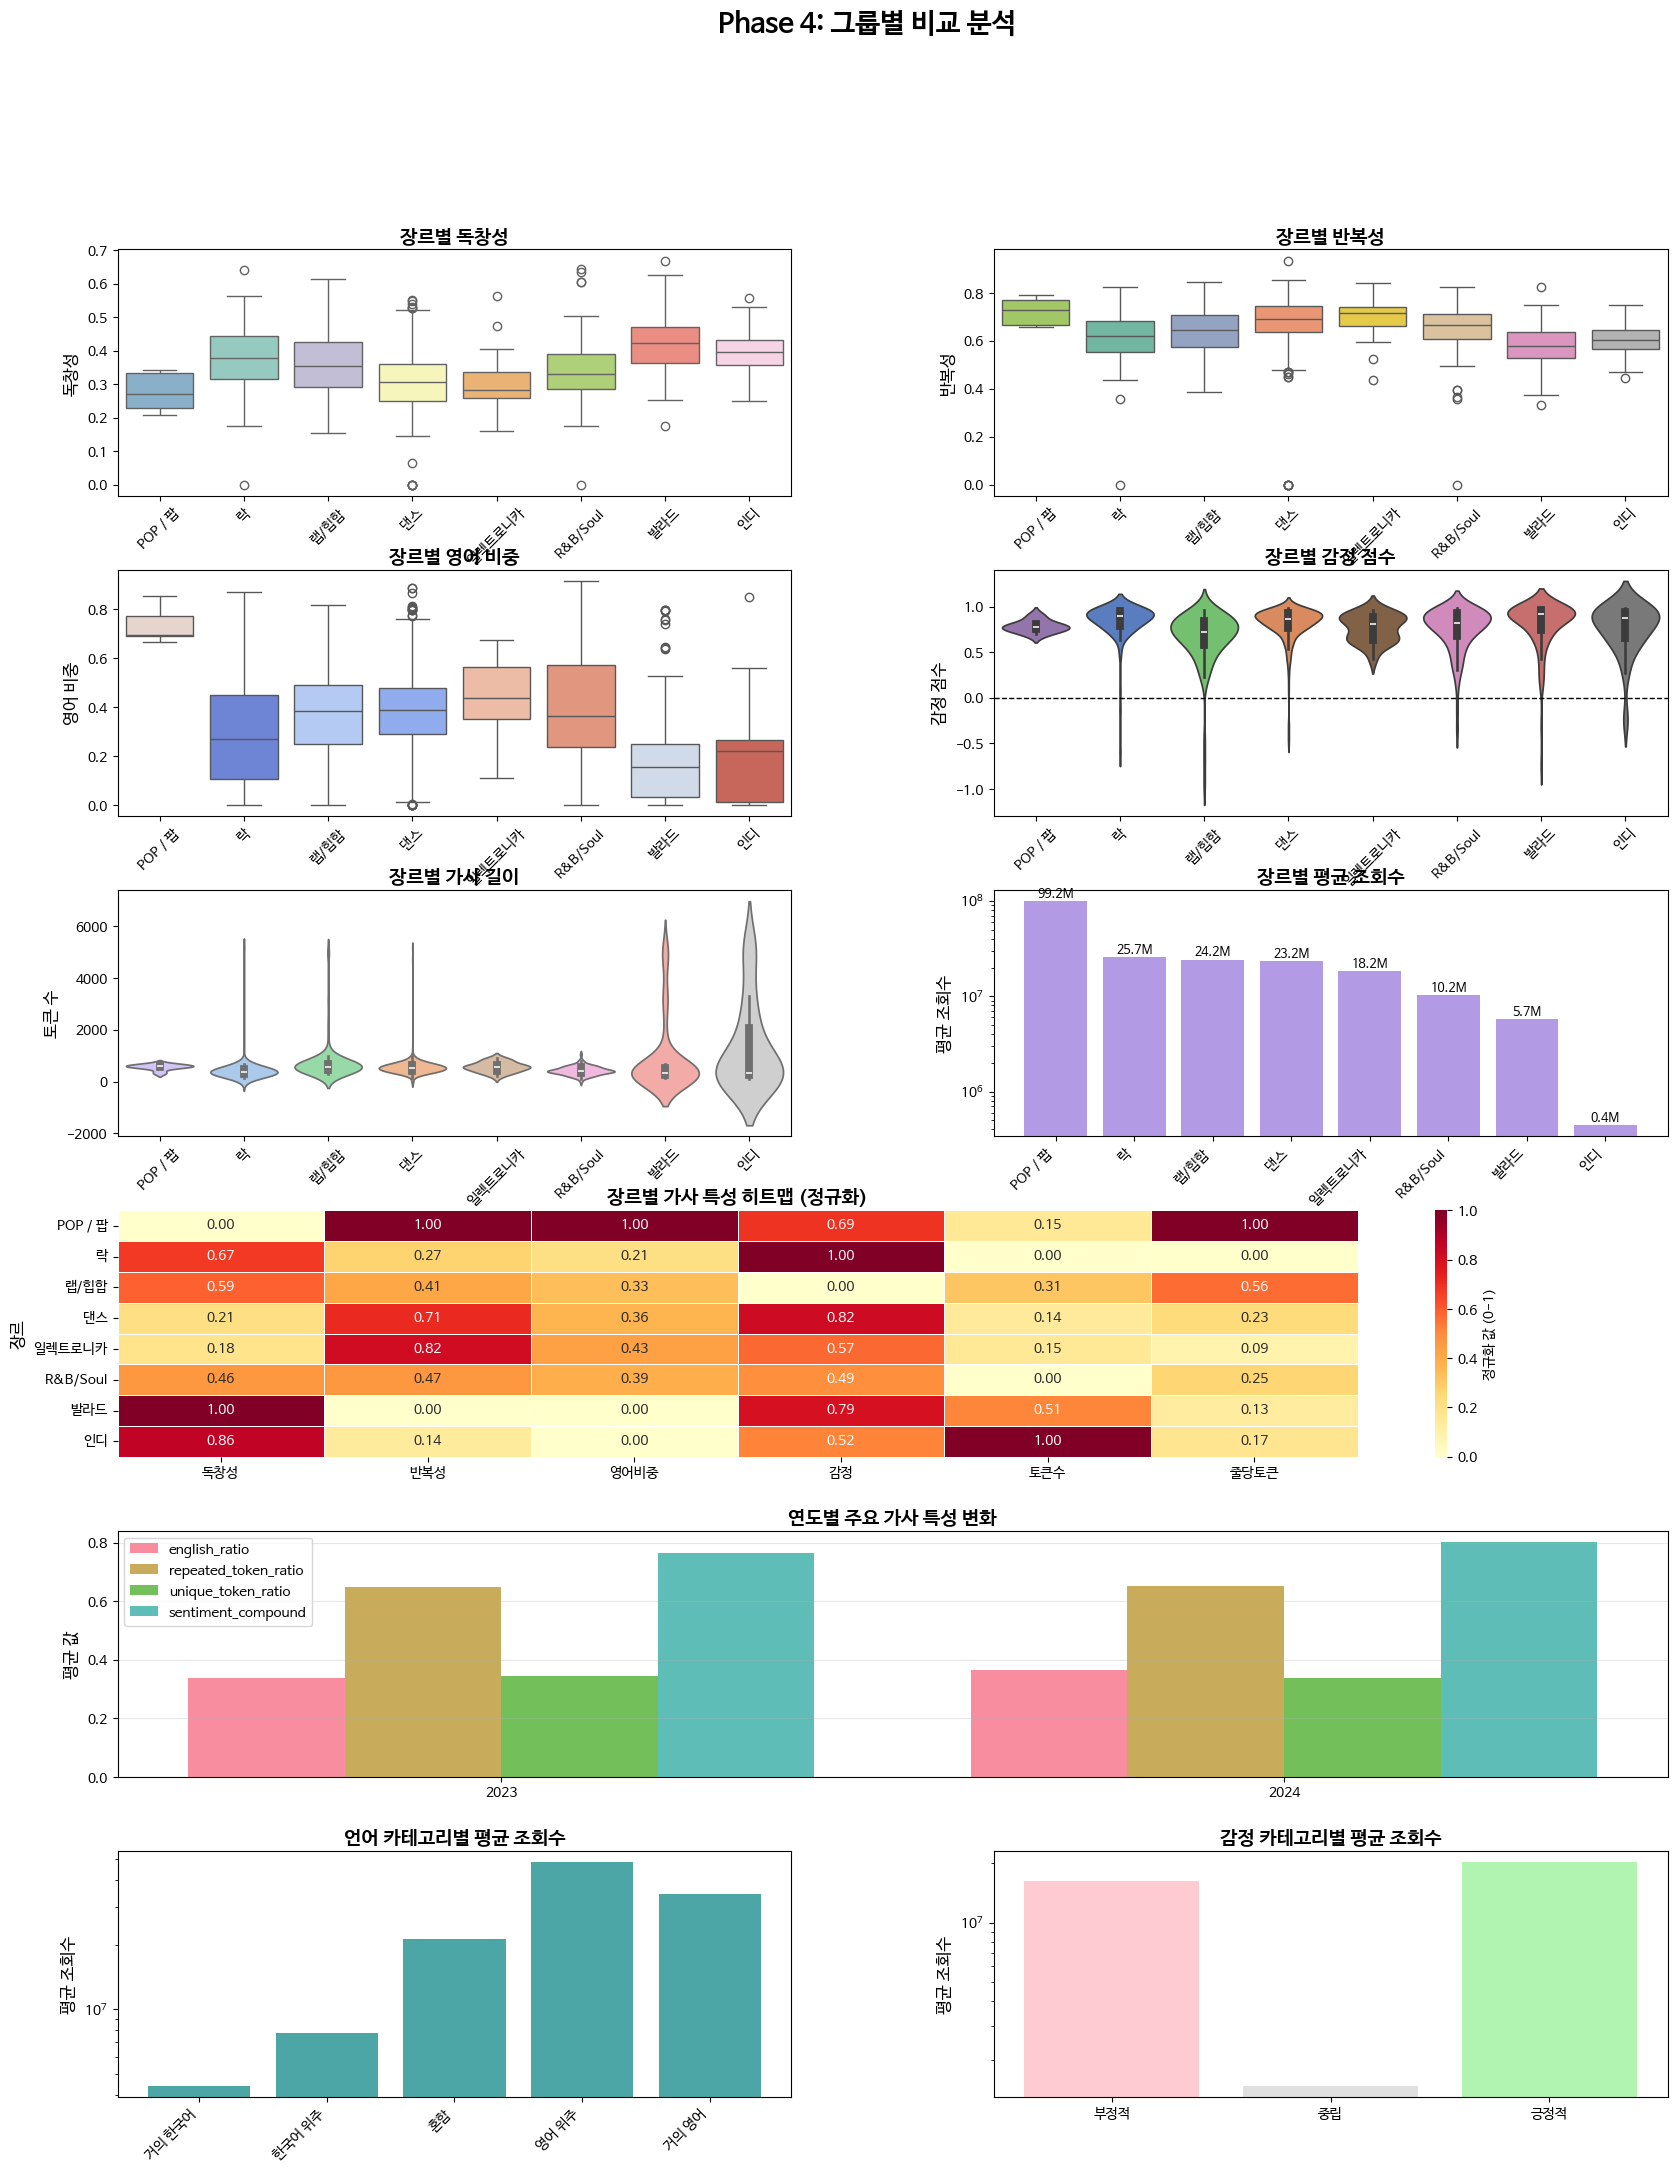


✅ Phase 4 완료!
계속하려면 엔터를 누르세요...


In [ ]:
# ============================================
# PHASE 4: 그룹별 비교 분석
# ============================================

print("\n" + "="*100)
print("PHASE 4: 그룹별 비교 분석")
print("="*100)

# 4.1 장르별 가사 특성
print("\n[4.1 장르별 가사 특성]")
genre_profile = df_final.groupby('genie_genre')[lyrics_features + ['api_view_count']].mean()
genre_profile = genre_profile.sort_values('api_view_count', ascending=False)
print(genre_profile.to_string())
genre_profile.to_csv('lyrics_eda_results/04_genre_profile.csv', encoding='utf-8-sig')

# 장르별 ANOVA
print("\n장르 간 차이 검정 (ANOVA):")
anova_results = []
for feature in lyrics_features:
    groups = [df_final[df_final['genie_genre'] == g][feature].dropna()
              for g in df_final['genie_genre'].unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        '변수': feature,
        'F-통계량': f_stat,
        'p-value': p_val,
        '유의함': 'Yes' if p_val < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results).sort_values('F-통계량', ascending=False)
print(anova_df.to_string())
anova_df.to_csv('lyrics_eda_results/04_anova_results.csv', index=False, encoding='utf-8-sig')

# 4.2 연도별 트렌드
print("\n[4.2 연도별 트렌드 (2023 vs 2024)]")
year_comparison = df_final.groupby('year')[lyrics_features + ['api_view_count']].mean()
print(year_comparison.T.to_string())
year_comparison.T.to_csv('lyrics_eda_results/04_year_comparison.csv', encoding='utf-8-sig')

# 변화율 계산
if len(year_comparison) == 2:
    years = sorted(df_final['year'].unique())
    change_pct = ((year_comparison.loc[years[1]] - year_comparison.loc[years[0]]) /
                  year_comparison.loc[years[0]] * 100)
    print(f"\n{years[0]}년 대비 {years[1]}년 변화율(%):")
    print(change_pct.sort_values(ascending=False).to_string())

# Phase 4 시각화
fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(6, 2, hspace=0.3, wspace=0.3)
fig.suptitle('Phase 4: 그룹별 비교 분석', fontsize=20, fontweight='bold')

genres = genre_profile.index.tolist()

# 1. 장르별 독창성
ax1 = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_final, x='genie_genre', y='unique_token_ratio',
            order=genres, ax=ax1, hue='genie_genre', legend=False, palette='Set3')
ax1.set_xlabel('')
ax1.set_ylabel('독창성', fontsize=12)
ax1.set_title('장르별 독창성', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# 2. 장르별 반복성
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=df_final, x='genie_genre', y='repeated_token_ratio',
            order=genres, ax=ax2, hue='genie_genre', legend=False, palette='Set2')
ax2.set_xlabel('')
ax2.set_ylabel('반복성', fontsize=12)
ax2.set_title('장르별 반복성', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# 3. 장르별 영어 비중
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=df_final, x='genie_genre', y='english_ratio',
            order=genres, ax=ax3, hue='genie_genre', legend=False, palette='coolwarm')
ax3.set_xlabel('')
ax3.set_ylabel('영어 비중', fontsize=12)
ax3.set_title('장르별 영어 비중', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# 4. 장르별 감정 점수
ax4 = fig.add_subplot(gs[1, 1])
sns.violinplot(data=df_final, x='genie_genre', y='sentiment_compound',
              order=genres, ax=ax4, hue='genie_genre', legend=False, palette='muted')
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_xlabel('')
ax4.set_ylabel('감정 점수', fontsize=12)
ax4.set_title('장르별 감정 점수', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# 5. 장르별 토큰 수
ax5 = fig.add_subplot(gs[2, 0])
sns.violinplot(data=df_final, x='genie_genre', y='token_count',
              order=genres, ax=ax5, hue='genie_genre', legend=False, palette='pastel')
ax5.set_xlabel('')
ax5.set_ylabel('토큰 수', fontsize=12)
ax5.set_title('장르별 가사 길이', fontsize=14, fontweight='bold')
ax5.tick_params(axis='x', rotation=45)

# 6. 장르별 평균 조회수
ax6 = fig.add_subplot(gs[2, 1])
avg_views_by_genre = df_final.groupby('genie_genre')['api_view_count'].mean().loc[genres]
bars = ax6.bar(range(len(genres)), avg_views_by_genre.values, color='mediumpurple', alpha=0.7)
ax6.set_xticks(range(len(genres)))
ax6.set_xticklabels(genres, rotation=45, ha='right')
ax6.set_ylabel('평균 조회수', fontsize=12)
ax6.set_title('장르별 평균 조회수', fontsize=14, fontweight='bold')
ax6.set_yscale('log')
for i, (bar, val) in enumerate(zip(bars, avg_views_by_genre.values)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{val/1e6:.1f}M', ha='center', va='bottom', fontsize=9)

# 7. 장르별 히트맵 (정규화)
ax7 = fig.add_subplot(gs[3, :])
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_data = genre_profile[['unique_token_ratio', 'repeated_token_ratio',
                               'english_ratio', 'sentiment_compound',
                               'token_count', 'avg_tokens_per_line']]
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=['독창성', '반복성', '영어비중', '감정', '토큰수', '줄당토큰']
)
sns.heatmap(heatmap_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax7, cbar_kws={'label': '정규화 값 (0-1)'})
ax7.set_title('장르별 가사 특성 히트맵 (정규화)', fontsize=14, fontweight='bold')
ax7.set_ylabel('장르', fontsize=12)

# 8. 연도별 트렌드 (주요 변수)
if len(df_final['year'].unique()) > 1:
    ax8 = fig.add_subplot(gs[4, :])
    trend_vars = ['english_ratio', 'repeated_token_ratio', 'unique_token_ratio', 'sentiment_compound']
    year_trend = df_final.groupby('year')[trend_vars].mean()

    x = range(len(year_trend))
    width = 0.2

    for i, var in enumerate(trend_vars):
        ax8.bar([p + width*i for p in x], year_trend[var], width,
               label=var, alpha=0.8)

    ax8.set_xticks([p + width*1.5 for p in x])
    ax8.set_xticklabels(year_trend.index)
    ax8.set_ylabel('평균 값', fontsize=12)
    ax8.set_title('연도별 주요 가사 특성 변화', fontsize=14, fontweight='bold')
    ax8.legend(loc='best')
    ax8.grid(axis='y', alpha=0.3)

# 9. 언어 카테고리별 평균 조회수
ax9 = fig.add_subplot(gs[5, 0])
lang_cat_views = df_final.groupby('language_category')['api_view_count'].mean()
bars = ax9.bar(range(len(lang_cat_views)), lang_cat_views.values, color='teal', alpha=0.7)
ax9.set_xticks(range(len(lang_cat_views)))
ax9.set_xticklabels(lang_cat_views.index, rotation=45, ha='right')
ax9.set_ylabel('평균 조회수', fontsize=12)
ax9.set_title('언어 카테고리별 평균 조회수', fontsize=14, fontweight='bold')
ax9.set_yscale('log')

# 10. 감정 카테고리별 평균 조회수
ax10 = fig.add_subplot(gs[5, 1])
emotion_cat_views = df_final.groupby('emotion_category')['api_view_count'].mean()
bars = ax10.bar(range(len(emotion_cat_views)), emotion_cat_views.values,
               color=['#FFB6C1', '#D3D3D3', '#90EE90'], alpha=0.7)
ax10.set_xticks(range(len(emotion_cat_views)))
ax10.set_xticklabels(emotion_cat_views.index)
ax10.set_ylabel('평균 조회수', fontsize=12)
ax10.set_title('감정 카테고리별 평균 조회수', fontsize=14, fontweight='bold')
ax10.set_yscale('log')

plt.savefig('lyrics_eda_results/phase4_group_comparison.png', dpi=300, bbox_inches='tight')
plt.show()



### 1-6. 전반적 EDA — Phase 5: 패턴 발견
변수 간 군집·패턴을 탐색해 흥미로운 조합을 찾습니다.


PHASE 5: 패턴 및 특이점 발견

[5.1 극단값 케이스 스터디]

가장 긴 가사 Top 5:
                               songName                     artists  token_count  api_view_count genie_genre
399                             그녀가 웃잖아  1894|루시 (LUCY)|lucy_solo|0       5166.0          680299         발라드
437                                 탕탕탕           3002|구공탄 (비투비)||0       5166.0         2763123          댄스
677  시대유감 (時代遺憾) (2024 Remastered Ver.)            2857|서태지와 아이들||0       5166.0         1194337           락
759                밤새도록 어떤 말을 할까 고민해 봤어                  2531|경서||0       5166.0          254862          인디
767               탈출속도(escape velocity)                  2531|경서||0       5166.0          229435          인디

가장 짧은 가사 Top 5:
                              songName                         artists  token_count  api_view_count genie_genre
278                          YURA YURA  2598|ZEROBASEONE|ZEROBASEONE|1          0.0        13744698          댄스
281                     Keep on Moving          

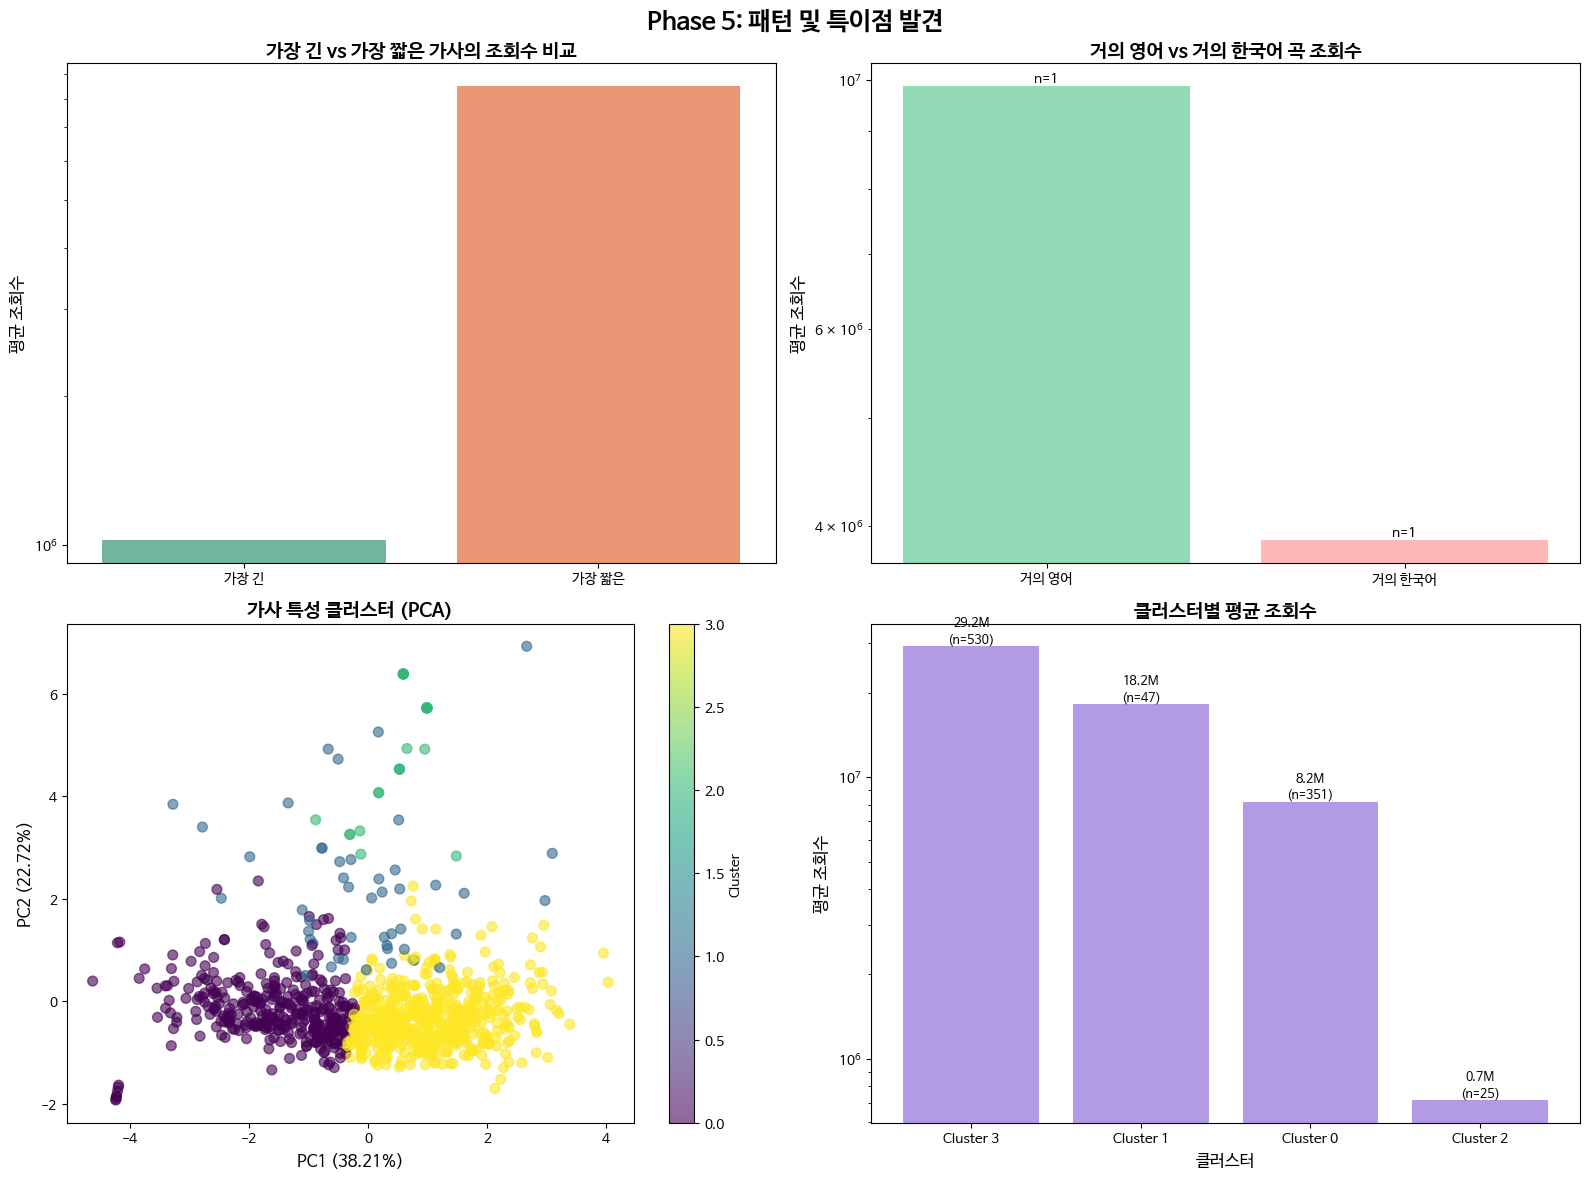


✅ Phase 5 완료!


In [ ]:
# ============================================
# PHASE 5: 패턴 및 특이점 발견
# ============================================

print("\n" + "="*100)
print("PHASE 5: 패턴 및 특이점 발견")
print("="*100)

# 5.1 극단값 케이스
print("\n[5.1 극단값 케이스 스터디]")

# 가장 긴/짧은 가사
longest = df_final.nlargest(5, 'token_count')[['songName', 'artists', 'token_count', 'api_view_count', 'genie_genre']]
shortest = df_final.nsmallest(5, 'token_count')[['songName', 'artists', 'token_count', 'api_view_count', 'genie_genre']]
print("\n가장 긴 가사 Top 5:")
print(longest.to_string())
print("\n가장 짧은 가사 Top 5:")
print(shortest.to_string())

# 100% 영어 vs 100% 한국어
pure_english = df_final[df_final['english_ratio'] > 0.9][['songName', 'artists', 'english_ratio', 'api_view_count', 'genie_genre']]
pure_korean = df_final[df_final['korean_ratio'] > 0.9][['songName', 'artists', 'korean_ratio', 'api_view_count', 'genie_genre']]
print(f"\n거의 100% 영어 곡 ({len(pure_english)}곡):")
if len(pure_english) > 0:
    print(pure_english.head(10).to_string())
    print(f"평균 조회수: {pure_english['api_view_count'].mean():,.0f}")
print(f"\n거의 100% 한국어 곡 ({len(pure_korean)}곡):")
if len(pure_korean) > 0:
    print(pure_korean.head(10).to_string())
    print(f"평균 조회수: {pure_korean['api_view_count'].mean():,.0f}")

# 가장 독창적 vs 가장 반복적
most_unique = df_final.nlargest(5, 'unique_token_ratio')[['songName', 'artists', 'unique_token_ratio', 'api_view_count', 'genie_genre']]
most_repetitive = df_final.nsmallest(5, 'unique_token_ratio')[['songName', 'artists', 'unique_token_ratio', 'repeated_token_ratio', 'api_view_count', 'genie_genre']]
print("\n가장 독창적인 가사 Top 5:")
print(most_unique.to_string())
print("\n가장 반복적인 가사 Top 5:")
print(most_repetitive.to_string())

# 5.2 "예상 밖" 케이스
print("\n[5.2 예상 밖 케이스]")

# 복잡한데 대박 (상위 25% 조회수 & 상위 25% 복잡도)
view_threshold_high = df_final['api_view_count'].quantile(0.75)
unique_threshold_high = df_final['unique_token_ratio'].quantile(0.75)
complex_hit = df_final[(df_final['api_view_count'] > view_threshold_high) &
                       (df_final['unique_token_ratio'] > unique_threshold_high)]
print(f"\n복잡한데 대박 난 곡 ({len(complex_hit)}곡):")
if len(complex_hit) > 0:
    print(complex_hit[['songName', 'artists', 'unique_token_ratio', 'api_view_count', 'genie_genre']].head(10).to_string())

# 단순한데 망함 (하위 25% 조회수 & 하위 25% 독창성)
view_threshold_low = df_final['api_view_count'].quantile(0.25)
unique_threshold_low = df_final['unique_token_ratio'].quantile(0.25)
simple_flop = df_final[(df_final['api_view_count'] < view_threshold_low) &
                       (df_final['unique_token_ratio'] < unique_threshold_low)]
print(f"\n단순한데 망한 곡 ({len(simple_flop)}곡):")
if len(simple_flop) > 0:
    print(simple_flop[['songName', 'artists', 'unique_token_ratio', 'api_view_count', 'genie_genre']].head(10).to_string())

# 영어 적은데 글로벌 히트 (상위 10% 조회수 & 영어 < 30%)
english_threshold = 0.3
global_hit_korean = df_final[(df_final['api_view_count'] > df_final['api_view_count'].quantile(0.9)) &
                             (df_final['english_ratio'] < english_threshold)]
print(f"\n영어 적은데 글로벌 히트 ({len(global_hit_korean)}곡):")
if len(global_hit_korean) > 0:
    print(global_hit_korean[['songName', 'artists', 'english_ratio', 'korean_ratio', 'api_view_count', 'genie_genre']].to_string())

# 5.3 클러스터링
print("\n[5.3 가사 특성 기반 클러스터링]")

# K-means 클러스터링 (k=4)
cluster_features = ['unique_token_ratio', 'repeated_token_ratio', 'english_ratio',
                   'sentiment_compound', 'token_count', 'avg_tokens_per_line']
X = df_final[cluster_features].fillna(df_final[cluster_features].mean())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

print("\n클러스터별 특성:")
cluster_profile = df_final.groupby('cluster')[cluster_features + ['api_view_count']].mean()
cluster_counts = df_final['cluster'].value_counts().sort_index()
print("\n클러스터별 곡 수:")
print(cluster_counts.to_string())
print("\n클러스터별 평균 특성:")
print(cluster_profile.to_string())
cluster_profile.to_csv('lyrics_eda_results/05_cluster_profile.csv', encoding='utf-8-sig')

# Phase 5 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 5: 패턴 및 특이점 발견', fontsize=18, fontweight='bold')

# 1. 극단값 비교 (길이)
ax1 = axes[0, 0]
extreme_length = pd.concat([
    longest.assign(category='가장 긴'),
    shortest.assign(category='가장 짧은')
])
sns.barplot(data=extreme_length, x='category', y='api_view_count', ax=ax1,
           palette='Set2', errorbar=None)
ax1.set_ylabel('평균 조회수', fontsize=12)
ax1.set_xlabel('')
ax1.set_title('가장 긴 vs 가장 짧은 가사의 조회수 비교', fontsize=14, fontweight='bold')
ax1.set_yscale('log')

# 2. 100% 영어 vs 100% 한국어
ax2 = axes[0, 1]
lang_comparison = pd.DataFrame({
    'category': ['거의 영어', '거의 한국어'],
    'avg_views': [pure_english['api_view_count'].mean() if len(pure_english) > 0 else 0,
                  pure_korean['api_view_count'].mean() if len(pure_korean) > 0 else 0],
    'count': [len(pure_english), len(pure_korean)]
})
bars = ax2.bar(lang_comparison['category'], lang_comparison['avg_views'],
              color=['#66CC99', '#FF9999'], alpha=0.7)
ax2.set_ylabel('평균 조회수', fontsize=12)
ax2.set_xlabel('')
ax2.set_title('거의 영어 vs 거의 한국어 곡 조회수', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
for bar, count in zip(bars, lang_comparison['count']):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'n={count}', ha='center', va='bottom', fontsize=10)

# 3. 클러스터 산점도 (PCA 2D)
ax3 = axes[1, 0]
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scatter = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=df_final['cluster'],
                     cmap='viridis', alpha=0.6, s=50)
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
ax3.set_title('가사 특성 클러스터 (PCA)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Cluster')

# 4. 클러스터별 평균 조회수
ax4 = axes[1, 1]
cluster_views = df_final.groupby('cluster')['api_view_count'].mean().sort_values(ascending=False)
bars = ax4.bar(range(len(cluster_views)), cluster_views.values,
              color='mediumpurple', alpha=0.7)
ax4.set_xticks(range(len(cluster_views)))
ax4.set_xticklabels([f'Cluster {i}' for i in cluster_views.index])
ax4.set_ylabel('평균 조회수', fontsize=12)
ax4.set_xlabel('클러스터', fontsize=12)
ax4.set_title('클러스터별 평균 조회수', fontsize=14, fontweight='bold')
ax4.set_yscale('log')
for i, (bar, val) in enumerate(zip(bars, cluster_views.values)):
    height = bar.get_height()
    count = cluster_counts[cluster_views.index[i]]
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{val/1e6:.1f}M\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('lyrics_eda_results/phase5_patterns_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Phase 5 완료!")

### 1-7. 가사 구조와 단순성 (Q2, Q5, Q8)

**분석**: 장르별 가사 독창성(Unique Token Ratio)과 반복성(Repeated Token Ratio)을 boxplot·t-test로 비교.
**결과**: 발라드는 독창성이 높고 반복성이 낮음(서사형 가사), 댄스는 반대로 독창성이 낮고 반복성이 매우 높음(후크 반복 중심) — 가설과 일치.

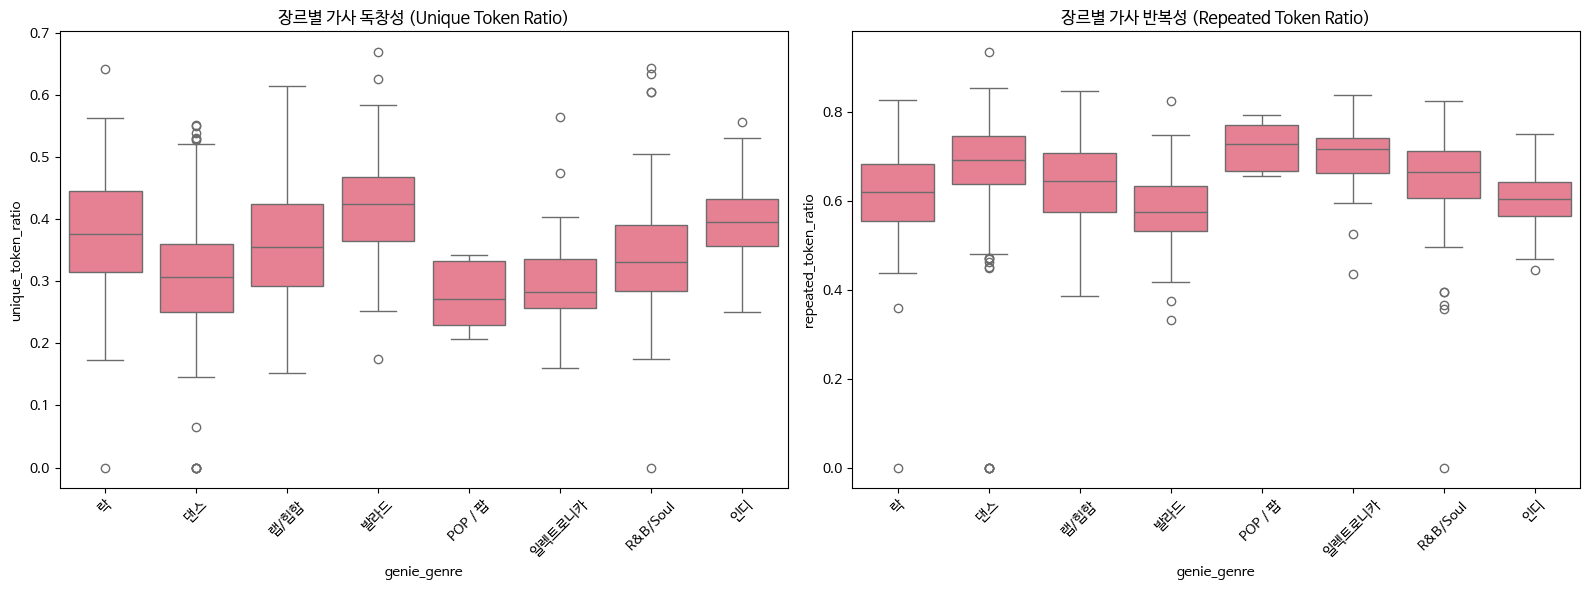

댄스 vs 발라드 반복성 차이 검정 P-value: 0.0000


In [ ]:
# 2. 장르별 가사 복잡도(Unique Token Ratio)와 반복성(Repeated Token Ratio) 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='genie_genre', y='unique_token_ratio', data=df_final, ax=axes[0])
axes[0].set_title('장르별 가사 독창성 (Unique Token Ratio)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(x='genie_genre', y='repeated_token_ratio', data=df_final, ax=axes[1])
axes[1].set_title('장르별 가사 반복성 (Repeated Token Ratio)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 댄스 장르와 발라드 장르의 가사 단순성 비교 (T-test)
dance_rep = df_final[df_final['genie_genre'] == '댄스']['repeated_token_ratio']
ballad_rep = df_final[df_final['genie_genre'] == '발라드']['repeated_token_ratio']
t_stat, p_val = ttest_ind(dance_rep, ballad_rep)
print(f"댄스 vs 발라드 반복성 차이 검정 P-value: {p_val:.4f}")

### 1-8. 인기 요인과 2024년 트렌드 (Q4, Q7)

**분석**: 가사 독창성 상위 10% 그룹의 평균 조회수, 영어 비중과 조회수의 상관관계 확인.
**결과**: 독창적인 가사보다 오히려 '일반적/반복적인 가사'의 평균 조회수가 더 높음 → 지나친 독창성보다 친숙한 반복이 대중적 인기에 유리. 조회수 폭발 곡들은 영어 비중 50% 이상 구간에 많이 분포 → K-POP 글로벌화와 연결.

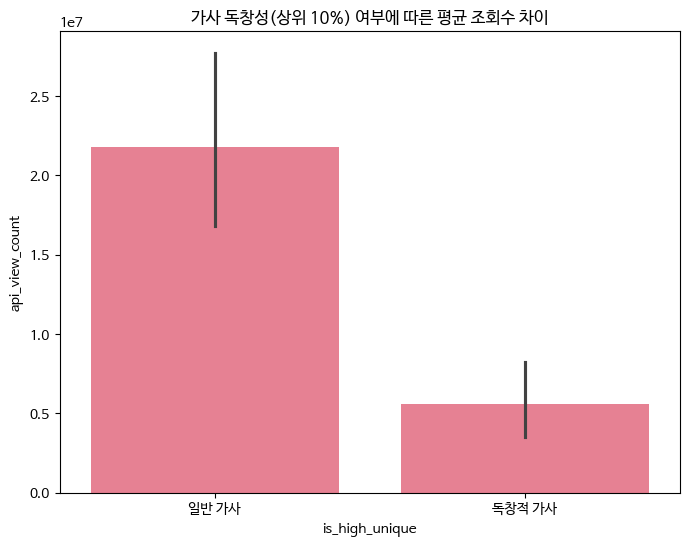

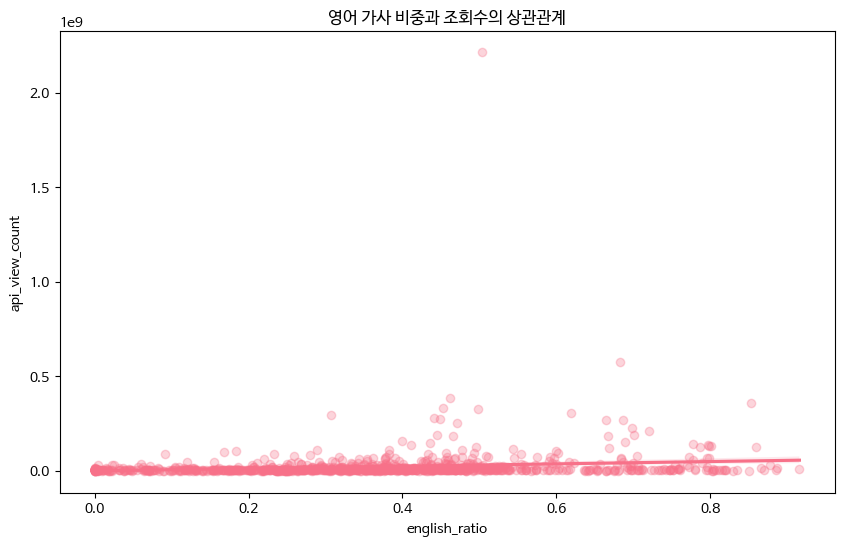

In [ ]:
# 3. 가사 차별화와 인기(조회수)의 관계
# 독창성 상위 10%를 'High Unique' 그룹으로 분류
q_high = df_final['unique_token_ratio'].quantile(0.9)
df_final['is_high_unique'] = df_final['unique_token_ratio'] >= q_high

plt.figure(figsize=(8, 6))
sns.barplot(x='is_high_unique', y='api_view_count', data=df_final)
plt.title('가사 독창성(상위 10%) 여부에 따른 평균 조회수 차이')
plt.xticks([0, 1], ['일반 가사', '독창적 가사'])
plt.show()

# 4. 영어 사용 비중(english_ratio)과 인기의 상관관계
plt.figure(figsize=(10, 6))
sns.regplot(x='english_ratio', y='api_view_count', data=df_final, scatter_kws={'alpha':0.3})
plt.title('영어 가사 비중과 조회수의 상관관계')
plt.show()

### 1-9. 상위 1% 히트곡 비교

**분석**: 조회수 상위 1% '괴물 곡'과 일반 곡의 가사 반복성·영어 비중 비교.
**결과**: 상위 1% 곡은 영어 비중(0.52 vs 0.35)과 반복성(0.70 vs 0.65) 모두 일반 곡보다 높음 → 글로벌 지향 + 중독성 있는 반복 후크가 흥행 공식이라는 가설이 수치로 검증됨.

/tmp/ipython-input-2442498558.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2442498558.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipython-input-2442498558.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-2442498558.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



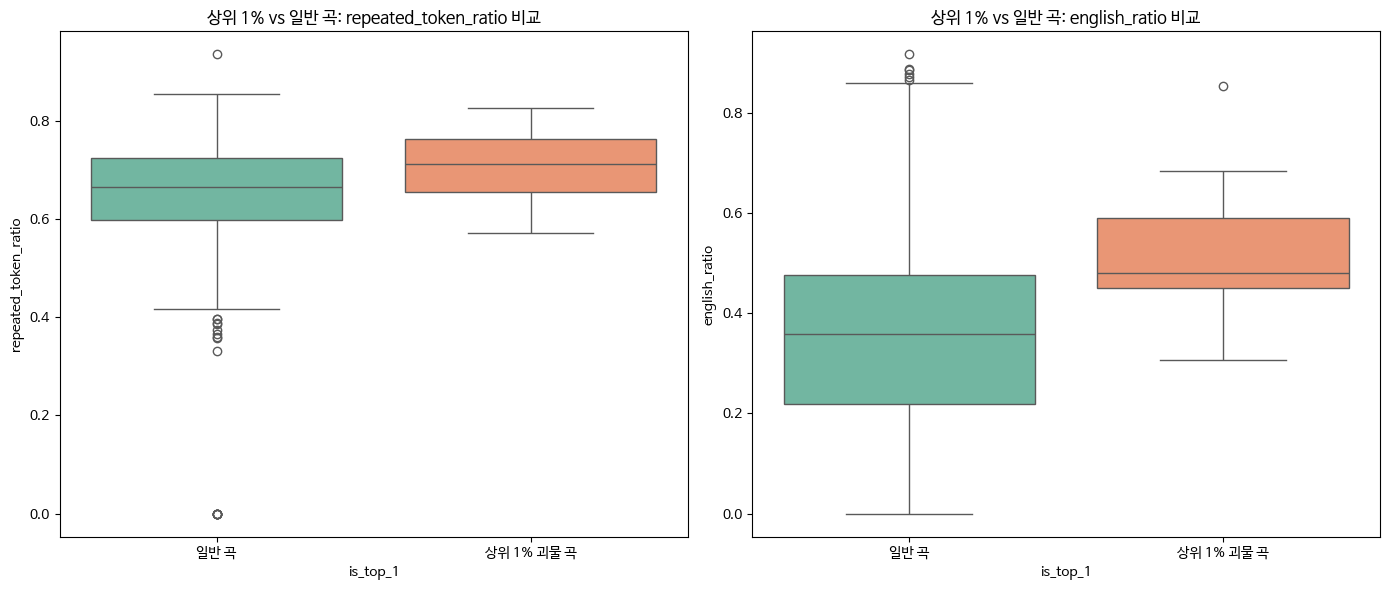

--- 그룹별 평균 비교 ---
          repeated_token_ratio  english_ratio
is_top_1                                     
False                 0.650916       0.354786
True                  0.708590       0.526750


In [ ]:
# 상위 1% 기준값 설정
top_1_threshold = df_final['api_view_count'].quantile(0.99)
df_final['is_top_1'] = df_final['api_view_count'] >= top_1_threshold

# 시각화 데이터 준비
top_metrics = ['repeated_token_ratio', 'english_ratio']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, metric in enumerate(top_metrics):
    sns.boxplot(x='is_top_1', y=metric, data=df_final, ax=axes[i], palette="Set2")
    axes[i].set_title(f'상위 1% vs 일반 곡: {metric} 비교')
    axes[i].set_xticklabels(['일반 곡', '상위 1% 괴물 곡'])

plt.tight_layout()
plt.show()

# 실제 평균값 수치 확인
print("--- 그룹별 평균 비교 ---")
print(df_final.groupby('is_top_1')[top_metrics].mean())

### 1-10. 장르별 가사 복잡도 통합 지수

**분석**: `unique_token_ratio`, `avg_tokens_per_line`, `avg_token_length`를 0~1로 정규화 후 평균 내어 `lyrics_complexity_index`(가사 복잡도 통합 지수)를 만들고 장르별로 비교.
**결과**: POP·랩/힙합·발라드가 복잡도 상위, 댄스·일렉트로니카가 하위 → 댄스는 퍼포먼스·비트를 강조하기 위해 언어 정보를 의도적으로 덜어낸다는 해석.

/tmp/ipython-input-978954689.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




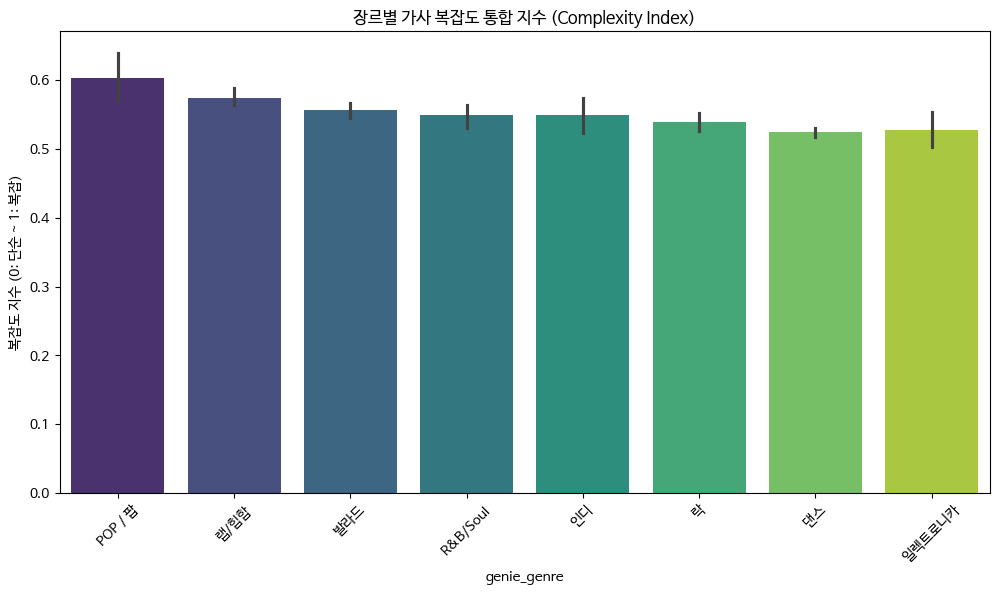

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. 지수화를 위한 스케일링 (0~1 사이로 변환)
scaler = MinMaxScaler()
cols_to_index = ['unique_token_ratio', 'avg_tokens_per_line', 'avg_token_length']
scaled_values = scaler.fit_transform(df_final[cols_to_index])

# 2. 통합 복잡도 지수 계산 (단순 평균)
df_final['lyrics_complexity_index'] = scaled_values.mean(axis=1)

# 3. 장르별 복잡도 시각화
plt.figure(figsize=(12, 6))
order = df_final.groupby('genie_genre')['lyrics_complexity_index'].median().sort_values(ascending=False).index
sns.barplot(x='genie_genre', y='lyrics_complexity_index', data=df_final, order=order, palette="viridis")

plt.title('장르별 가사 복잡도 통합 지수 (Complexity Index)')
plt.ylabel('복잡도 지수 (0: 단순 ~ 1: 복잡)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 장르별 복잡도 평균/중앙값 계산
genre_complexity = (
    df_final
    .groupby('genie_genre')['lyrics_complexity_index']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .rename(columns={
        'genie_genre': 'Genre',
        'mean': 'Avg_Complexity',
        'median': 'Median_Complexity',
        'count': 'Song_Count'
    })
    .sort_values(by='Median_Complexity', ascending=False)
)

genre_complexity


,Genre,Avg_Complexity,Median_Complexity,Song_Count
0,POP / 팝,0.602483,0.601899,7
4,랩/힙합,0.573824,0.575917,111
5,발라드,0.555610,0.556145,107
1,R&B/Soul,0.548575,0.550997,98
6,인디,0.549107,0.546330,25
3,락,0.538243,0.541589,118
2,댄스,0.523824,0.530153,467
7,일렉트로니카,0.527346,0.511463,20


### 1-11. 특이 케이스 개요
장르 문법에서 벗어난 개별 곡 사례를 직접 확인합니다 (예: 발라드인데 너무 단순하거나, 댄스인데 너무 복잡한 경우).

**분석**: 장르 문법에서 벗어난 개별 곡 사례를 직접 확인 — 발라드인데 복잡도가 매우 낮은 곡, 댄스인데 복잡도가 매우 높은 곡의 가사를 눈으로 검토.
**대표 사례**: 발라드 저복잡도 - '366일', '사랑인걸', 'Miss You' 등 / 댄스 고복잡도 - 'Mantra'(제니), 'BADVILLAIN' 등(영어 가사 밀도·랩 비중이 높은 곡들).


🎵 발라드인데 unusually 단순한 곡
                       songName genie_genre  lyrics_complexity_index   z_score
551             366일 (366 Days)         발라드                 0.401133 -2.308143
628                    Miss You         발라드                 0.405306 -2.239853
867                      러브 레시피         발라드                 0.420648 -1.988843
882  라떼 한 잔 (Feat. 이준혁 of 미래소년)         발라드                 0.441363 -1.649901

💃 댄스인데 unusually 복잡한 곡
                             songName genie_genre  lyrics_complexity_index  \
8                              Mantra          댄스                 0.719237   
90                         BADVILLAIN          댄스                 0.705007   
378                       Could It Be          댄스                 0.667081   
344                         Algorithm          댄스                 0.630883   
741  Broke My Heart (Feat. Lay Bankz)          댄스                 0.628802   
261                    Must Have Love          댄스                 0.626033   
335       

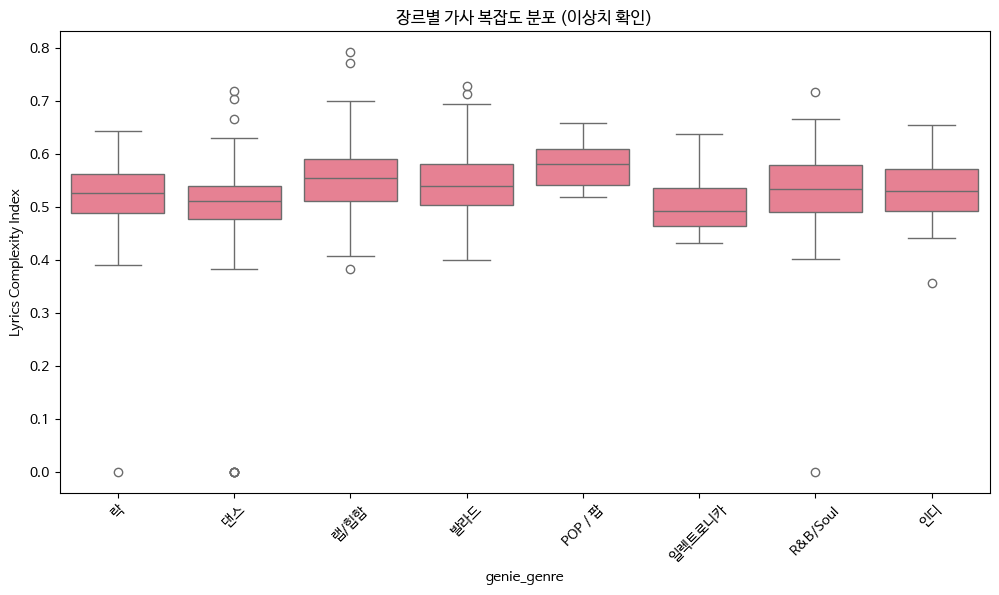

In [ ]:
# ================================
# 1. 라이브러리
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# ================================
# 2. 가사 복잡도 지수 만들기
# ================================
scaler = MinMaxScaler()
cols_to_index = ['unique_token_ratio', 'avg_tokens_per_line', 'avg_token_length']

scaled_values = scaler.fit_transform(df_final[cols_to_index])

df_final['lyrics_complexity_index'] = scaled_values.mean(axis=1)

# ================================
# 3. 장르별 복잡도 통계
# ================================
genre_stats = (
    df_final
    .groupby('genie_genre')['lyrics_complexity_index']
    .agg(['mean', 'std'])
    .reset_index()
)

# ================================
# 4. z-score 계산 (장르 평균에서 얼마나 벗어났는지)
# ================================
df_outlier = df_final.merge(genre_stats, on='genie_genre')

df_outlier['z_score'] = (
    (df_outlier['lyrics_complexity_index'] - df_outlier['mean'])
    / df_outlier['std']
)

# ================================
# 5. 특이 케이스 탐색
# ================================

# 🔹 발라드인데 너무 단순한 곡
simple_ballads = df_outlier[
    (df_outlier['genie_genre'] == '발라드') &
    (df_outlier['z_score'] < -1.5)
][['songName', 'genie_genre', 'lyrics_complexity_index', 'z_score']].sort_values('z_score')

# 🔹 댄스인데 너무 복잡한 곡
complex_dance = df_outlier[
    (df_outlier['genie_genre'] == '댄스') &
    (df_outlier['z_score'] > 1.5)
][['songName', 'genie_genre', 'lyrics_complexity_index', 'z_score']].sort_values('z_score', ascending=False)

print("\n🎵 발라드인데 unusually 단순한 곡")
print(simple_ballads.head(10))

print("\n💃 댄스인데 unusually 복잡한 곡")
print(complex_dance.head(10))

# ================================
# 6. 장르별 복잡도 분포 시각화
# ================================
plt.figure(figsize=(12,6))
sns.boxplot(data=df_final, x='genie_genre', y='lyrics_complexity_index')
plt.xticks(rotation=45)
plt.title("장르별 가사 복잡도 분포 (이상치 확인)")
plt.ylabel("Lyrics Complexity Index")
plt.show()


In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', None)

In [ ]:
# 조회하고 싶은 곡 리스트
target_songs = ['366일 (366 Days)', 'Miss You', '러브 레시피', '라떼 한 잔 (Feat. 이준혁 of 미래소년)' ]

for song in target_songs:
    print(f"\n{'='*50}")
    print(f"🎵 곡 제목: {song}")
    print(f"{'='*50}")

    # loc를 사용하여 lyrics_cleaned 컬럼 추출
    lyrics = df_final.loc[df_final['songName'] == song, 'lyrics_cleaned']

    if not lyrics.empty:
        print(lyrics.values[0])
    else:
        print("해당 곡의 가사를 찾을 수 없습니다.")


🎵 곡 제목: 366일 (366 Days)
우리 오늘 만나기로 했던
밤새 기다렸던 그날
우리 빨리 만나기로 해요
그동안 못 했던 말
많다고 했잖아요

밤이던 아침이던
언제든
만나고 싶어
얼마나 좋아요
근데 헤어질 땐 좀 그래요

하루 더 하루만
아니 삼백육십오일도
짧은 것 같아 혹시 우리
하루가 더 늘면
일 년 삼백육십육일 늘 곁에
(곁에)
곁에 있어요

You
You, woah
You
Ooh

우리 매일 만나기로 해요
서로가 맘속 숨겼던 말
이미 다 알잖아요

밤이던
아침이던
언제든 함께고 싶어
얼마나 좋아요
할 말이 없어도 좀 어때요

하루 더
하루만
아니 삼백육십오일도
짧은 것 같아 혹시 우리
하루가
더 늘면
일 년 삼백육십육일 늘 곁에
(곁에)
곁에 있어요

어쩐지 뭔가 좀 부족하고
어딘가 한구석 구멍 난 느낌
우리에게만 더
하루가 더 채워져 가는 완벽한 꿈
정말 그날이 오면
삼백육십육 번째
안아줄 거야

하루 더
하루만
아니 삼백육십오일도 (
삼백육십오일도
)
짧은 것 같아 혹시 우리 (
Oh-oh-oh
)
하루가
더 늘면
일 년 삼백육십육일 늘 곁에
(
곁에
)
곁에 있어요

You
You, woah
You
Ooh

🎵 곡 제목: Miss You
무슨 말을 하려나?
네 입술만 바라보다
문득 겁이 나더라
무슨 말 할지 잘 알아
오늘이 마지막
마지막일 것만 같아
한 번만 안아볼까
후련할 만큼 꽉 안아

Ah, ah-ah, ah, ah
아프다
말하지 그랬어
Mm
Ah, ah-ah, ah, ah
아쉽다
못 해준 게 많아
Yeah

I miss you
I love you
네 맘도
나와 같다고
Oh, I need you
I hate you
내 전부를
다 주었던 꿈

Na, na-na-na-na, na
Na, na-na-na
Na, na-na-na, na-na
Na-na, na-na
Na, na-na-na-na, na
Na, na-na-na
Na, na-na-na, na-na
Na-na, na

Yeah, I'll take the blame, 너가 원하는 거는

In [ ]:
# 1. 조회하고 싶은 댄스 곡 리스트 (복잡도 상위권)
target_dance_songs = [
    'Mantra', 'BADVILLAIN', 'Could It Be', 'Algorithm',
    'Broke My Heart (Feat. Lay Bankz)', 'Must Have Love',
    'Nightwalker', 'Automatic', "Cherry Gene 'Baddest Mix'"
]

print("🔍 [댄스 장르 고복잡도 곡 가사 분석 결과]")

for song in target_dance_songs:
    print(f"\n{'='*60}")
    print(f"💃 곡 제목: {song}")

    # 해당 곡의 데이터 추출
    row = df_final.loc[df_final['songName'] == song]

    if not row.empty:
        # 지표 정보 출력
        complexity = row['lyrics_complexity_index'].values[0]
        eng_ratio = row['english_ratio'].values[0]
        print(f"📊 복잡도 지수: {complexity:.3f} | 영어 비중: {eng_ratio:.2%}")
        print(f"{'-'*60}")

        # 가사 출력
        print(row['lyrics_cleaned'].values[0])
    else:
        print(f"❌ '{song}' 곡의 가사를 찾을 수 없습니다.")

print(f"\n{'='*60}")

🔍 [댄스 장르 고복잡도 곡 가사 분석 결과]

💃 곡 제목: Mantra
📊 복잡도 지수: 0.719 | 영어 비중: 69.83%
------------------------------------------------------------
Pretty, pretty
Pretty, pretty

This that pretty-girl mantra,
this that flaunt ya, just touched down in L.A.​
Pretty girls don't do drama 'less we wanna, it'll be depending on the day
Pretty girls packed in a Defender, know I'ma defend her, never let her catch no stray
This that pretty-girl mantra, she's that stunna, make you wanna swing both ways

Mix me with the drama (Drama)
Check you like commas (Ah-ah, ah-ah)
My clothes are pajamas ('Jamas)
Straight from the cold plunge (Ah-ah, ah-ah)
Daytime baddie use her mind
Quick switch of the fit for the night (Night)
Swеrvin' through the lane, we'll bе twenty minute late
'Cause we had to do an In-N-Out drive-by

It's not that deep (Deep), I'm not that drunk (Drunk)
Sometimes, girls just gotta have fun
Throw it back, all that ass
Me and my sis, way too attached
It's not that deep (Deep), we're not that dumb (D

### 1-12. 댄스 장르: 가사 복잡도-조회수 상관관계
**분석**: 댄스 장르만 필터링해 복잡도 지수와 조회수의 상관계수 계산.
**결과**: 상관계수 0.0621로 낮음 → "가사가 복잡하다고 무조건 뜨는 것은 아니다"라는 근거.

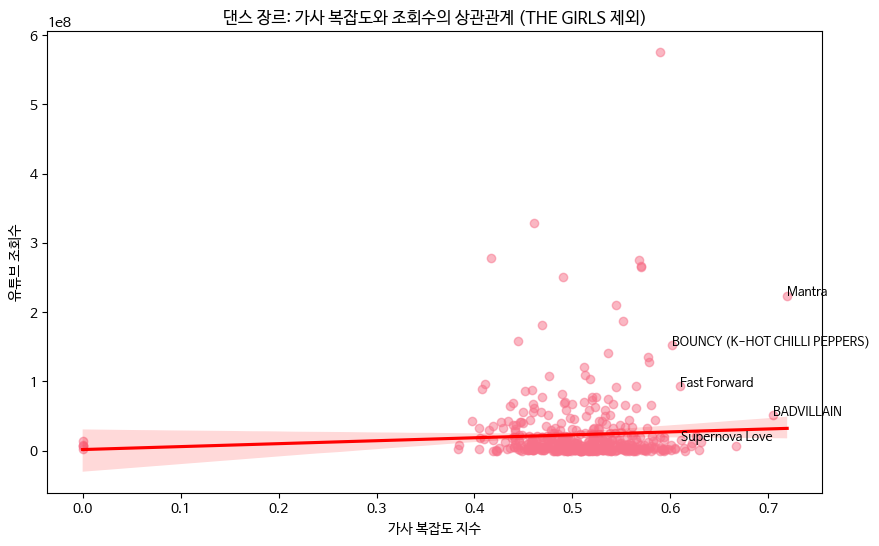

댄스 장르 가사 복잡도-조회수 상관계수 (THE GIRLS 제외): 0.0621


In [ ]:
# ================================
# 1. 댄스 장르 + 특정 곡 제외
# ================================
dance_df = df_final[
    (df_final['genie_genre'] == '댄스') &
    (~df_final['songName'].str.contains('THE GIRLS', case=False, na=False))
].copy()

# ================================
# 2. 산점도 + 회귀선
# ================================
plt.figure(figsize=(10, 6))

sns.regplot(
    data=dance_df,
    x='lyrics_complexity_index',
    y='api_view_count',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'}
)

# ================================
# 3. 상위 복잡도 특이 케이스 표시 (상위 5%)
# ================================
outliers = dance_df[
    dance_df['lyrics_complexity_index'] >
    dance_df['lyrics_complexity_index'].quantile(0.95)
]

for i, row in outliers.head(5).iterrows():
    plt.text(
        row['lyrics_complexity_index'],
        row['api_view_count'],
        row['songName'],
        fontsize=9
    )

plt.title('댄스 장르: 가사 복잡도와 조회수의 상관관계 (THE GIRLS 제외)')
plt.xlabel('가사 복잡도 지수')
plt.ylabel('유튜브 조회수')
plt.show()

# ================================
# 4. 상관계수 계산
# ================================
correlation = dance_df['lyrics_complexity_index'].corr(dance_df['api_view_count'])
print(f"댄스 장르 가사 복잡도-조회수 상관계수 (THE GIRLS 제외): {correlation:.4f}")


### 1-13. 가사 복잡도×감정 4분면 분석 제안
단순히 "무슨 단어를 썼나"가 아니라 "어떤 스타일의 곡이 돈이 되는가"를 보여주는 4분면(복잡도×감정) 프레임을 제안합니다.

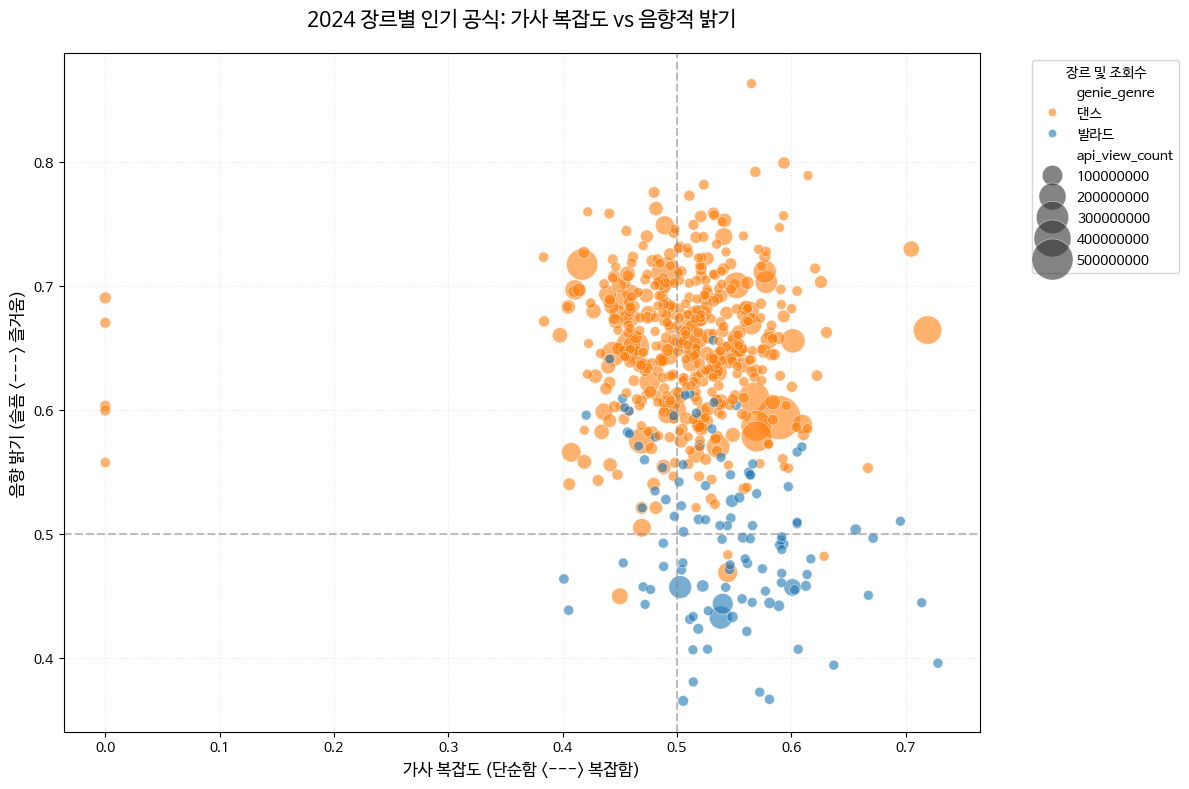

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (환경에 맞게 수정: 'Malgun Gothic' 또는 'AppleGothic')
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))

# 1. 시각화 대상 장르 필터링
target_genres = ['댄스', '발라드']
df_filtered = df_final[df_final['genie_genre'].isin(target_genres)]

# 2. 산점도 생성
# palette='Set1' 또는 직접 색상 지정 (예: {'댄스': '#FF6B6B', '발라드': '#4D96FF'})
sns.scatterplot(
    data=df_filtered,
    x='lyrics_complexity_index',
    y='valence_normalized',
    size='api_view_count',
    hue='genie_genre',
    palette={'댄스': '#ff7f0e', '발라드': '#1f77b4'}, # 댄스(주황), 발라드(파랑)로 명확히 구분
    alpha=0.6,
    sizes=(50, 1000), # 원의 크기 범위를 키워 흥행 곡을 더 잘 보이게 설정
    edgecolor='w',    # 원 테두리를 하얗게 설정하여 겹치는 부분 구분
    linewidth=0.5
)

# 3. 기준선 및 디자인 설정
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5) # 밝기 기준선
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5) # 복잡도 기준선

plt.title('2024 장르별 인기 공식: 가사 복잡도 vs 음향적 밝기', fontsize=15, pad=20)
plt.xlabel('가사 복잡도 (단순함 <---> 복잡함)', fontsize=12)
plt.ylabel('음향 밝기 (슬픔 <---> 즐거움)', fontsize=12)

# 범례 위치 조정
plt.legend(title='장르 및 조회수', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

### 1-14. 발라드/R&B 영어 비율 확인
**분석**: 영어 비중 상위 20% 발라드/R&B 곡 확인.
**결과**: 발라드인데 영어 비중이 80%에 육박하는 곡들(로제, 베이비몬스터, 정국 등)이 존재 → 발라드 장르의 '글로벌화'를 보여주는 증거.

In [ ]:
# 기준: 영어 비중 상위 20% 이상
threshold = df_final['english_ratio'].quantile(0.8)

high_english = df_final[
    (df_final['english_ratio'] >= threshold) &
    (df_final['genie_genre'].isin(['발라드', 'R&B/Soul']))
].copy()

# 보기 좋은 컬럼만
cols = [
    'songName',
    'artists',
    'genie_genre',
    'english_ratio',
    'api_view_count'
]

result = high_english[cols].sort_values(by='english_ratio', ascending=False)

print(result.head(20))


                             songName  \
426             Peanut Butter & Tears   
238                            For Us   
806                              Easy   
171                 What Would You Do   
352            Re: Thinkin' About You   
885  T.I.E (Take It Easy) (feat. 박재범)   
7                     number one girl   
50                Stuck In The Middle   
113                          Hate You   
778                     싸움 (Love War)   
765                            Savior   
156                   Don’t Go Insane   
85                          FRI(END)S   
33                              TOXIC   
250                        Hypnotized   
431                     별 떨어진다 (I Do)   
287         Gimme A Minute (Feat. 청하)   
48               When You Say My Name   
532                  ㅠㅠ (Credit Roll)   
815                              1993   

                                     artists genie_genre  english_ratio  \
426                    2024|DPR IAN|DPRIAN|1    R&B/Soul       

### 1-15. 흥행 결정 요인 회귀분석 (Regression Analysis)
**분석**: 전체 데이터를 대상으로 조회수에 영향을 미치는 변수들의 회귀계수를 분석.
**결과 (2024년 대중가요 3대 흥행 원칙)**: ① 언어의 글로벌화(english_ratio가 가장 강력한 양의 예측변수) ② 구조의 단순화(lyrics_complexity_index는 모든 장르에서 음의 계수) ③ 반복의 미학(repeated_token_ratio는 양의 계수).

In [ ]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

def run_regression_analysis(df, group_name):
    # 1. 분석 변수 선택 및 결측치 제거
    features = ['english_ratio', 'lyrics_complexity_index', 'repeated_token_ratio']
    target = 'api_view_count'

    analysis_df = df[features + [target]].dropna()

    # 2. 독립변수 표준화 (변수 간 단위가 다르므로 영향력 크기 비교를 위해 필수)
    scaler = StandardScaler()
    X = scaler.fit_transform(analysis_df[features])
    X = pd.DataFrame(X, columns=features)
    y = analysis_df[target].values

    # 3. 회귀 모델 학습 (OLS)
    X = sm.add_constant(X) # 절편 추가
    model = sm.OLS(y, X).fit()

    print(f"\n===== [{group_name}] 흥행 요인 영향력 분석 =====")
    # 각 변수의 계수(Coefficient)만 추출하여 영향력 비교
    coef_df = model.params[1:].sort_values(ascending=False)
    for feature, coef in coef_df.items():
        print(f"▶ {feature:25} 영향력 가중치: {coef:,.0f}")

    # R-squared (모델의 설명력)
    print(f"※ 모델 설명력(R-squared): {model.rsquared:.4f}")
    return model

# [전체], [댄스], [발라드] 각각 분석 실행
full_model = run_regression_analysis(df_final, "전체 곡")
dance_model = run_regression_analysis(df_final[df_final['genie_genre'] == '댄스'], "댄스")
ballad_model = run_regression_analysis(df_final[df_final['genie_genre'] == '발라드'], "발라드")


===== [전체 곡] 흥행 요인 영향력 분석 =====
▶ english_ratio             영향력 가중치: 11,111,819
▶ repeated_token_ratio      영향력 가중치: 5,361,386
▶ lyrics_complexity_index   영향력 가중치: -3,459,151
※ 모델 설명력(R-squared): 0.0282

===== [댄스] 흥행 요인 영향력 분석 =====
▶ english_ratio             영향력 가중치: 11,209,677
▶ repeated_token_ratio      영향력 가중치: 2,632,270
▶ lyrics_complexity_index   영향력 가중치: -2,292,949
※ 모델 설명력(R-squared): 0.0588

===== [발라드] 흥행 요인 영향력 분석 =====
▶ english_ratio             영향력 가중치: 8,108,780
▶ repeated_token_ratio      영향력 가중치: 1,892,989
▶ lyrics_complexity_index   영향력 가중치: -2,522,612
※ 모델 설명력(R-squared): 0.1707


### 1-16. 장르별 종합 프로파일
**분석**: 장르별 조회수·가사 복잡도·독창성/반복성·언어비중·감성·구조·음향특성을 모두 모은 종합 프로파일 테이블과 6분할 시각화를 생성하고, ANOVA로 장르 간 차이의 통계적 유의성을 검정한 뒤 히트맵과 요약 리포트를 만듭니다.

장르별 종합 프로파일
         장르   곡수        평균_조회수     중앙값_조회수  avg_complexity  median_complexity  avg_unique_ratio  avg_repeated_ratio  avg_korean_ratio  avg_english_ratio  avg_sentiment  avg_positive_emotion  avg_negative_emotion  avg_token_count  avg_line_count  avg_tokens_per_line  avg_sentiment_congruence  avg_valence  avg_energy   avg_tempo
4   POP / 팝    7  9.922037e+07  38992139.0        0.580405           0.582218          0.277943            0.722057          0.000000           0.735129       0.784443              0.062071              0.039800       568.857143       65.142857             8.140000                  0.280688     0.611541    0.276371  113.755321
0         락  118  2.571674e+07   1748429.0        0.521109           0.525999          0.373992            0.617533          0.444543           0.305120       0.839294              0.037780              0.027698       426.313559       59.593220             5.984576                  0.297885     0.630620    0.252841  122.010308
2

/tmp/ipython-input-3290739882.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='genie_genre', y='lyrics_complexity_index',
/tmp/ipython-input-3290739882.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='genie_genre', y='sentiment_compound',
/tmp/ipython-input-3290739882.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x='genie_genre', y='sentiment_congruence',


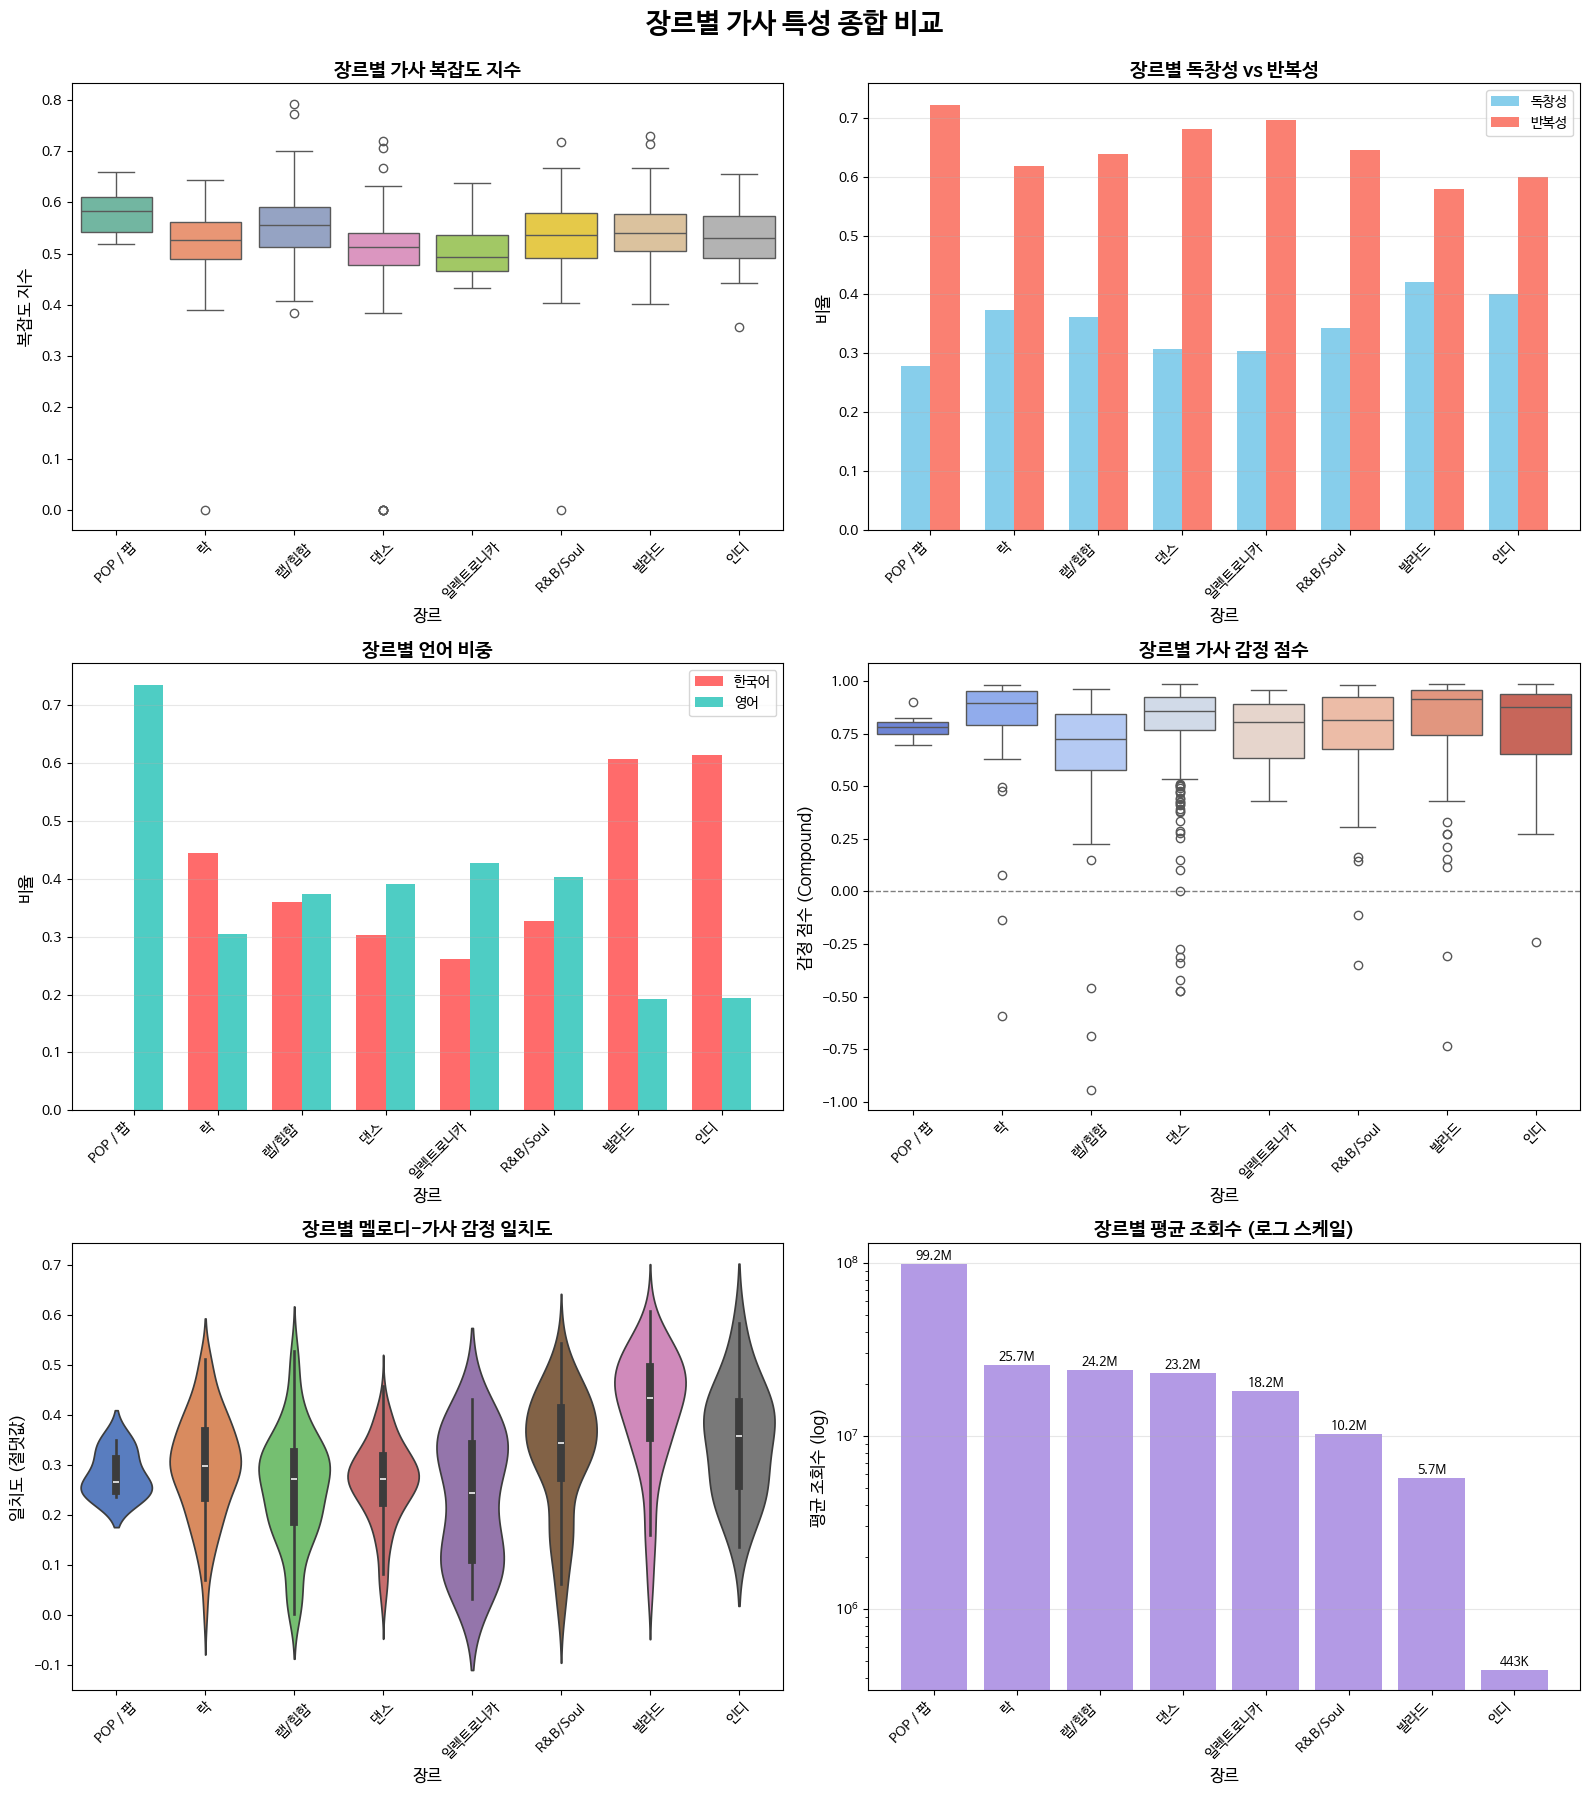


장르별 두드러진 특징

[락]
  - 긍정적 (0.839)

[댄스]
  - 저복잡도 (0.506)
  - 긍정적 (0.807)

[랩/힙합]
  - 고복잡도 (0.556)
  - 부정적 (0.662)
  - 감정괴리높음 (0.256)

[발라드]
  - 저반복성 (0.580)
  - 저영어비중 (0.193)

[POP / 팝]
  - 고복잡도 (0.580)
  - 고반복성 (0.722)
  - 고영어비중 (0.735)

[일렉트로니카]
  - 저복잡도 (0.509)
  - 고반복성 (0.696)
  - 고영어비중 (0.426)
  - 감정괴리높음 (0.230)

[R&B/Soul]
  - 부정적 (0.749)

[인디]
  - 저반복성 (0.599)
  - 저영어비중 (0.193)

장르 간 차이 검정 (ANOVA)

lyrics_complexity_index:
  F-통계량: 9.1033
  p-value: 0.000000
  유의함: Yes (p<0.05)

unique_token_ratio:
  F-통계량: 27.6986
  p-value: 0.000000
  유의함: Yes (p<0.05)

repeated_token_ratio:
  F-통계량: 17.5750
  p-value: 0.000000
  유의함: Yes (p<0.05)

english_ratio:
  F-통계량: 22.4668
  p-value: 0.000000
  유의함: Yes (p<0.05)

sentiment_compound:
  F-통계량: 6.7915
  p-value: 0.000000
  유의함: Yes (p<0.05)

sentiment_congruence:
  F-통계량: 31.3971
  p-value: 0.000000
  유의함: Yes (p<0.05)


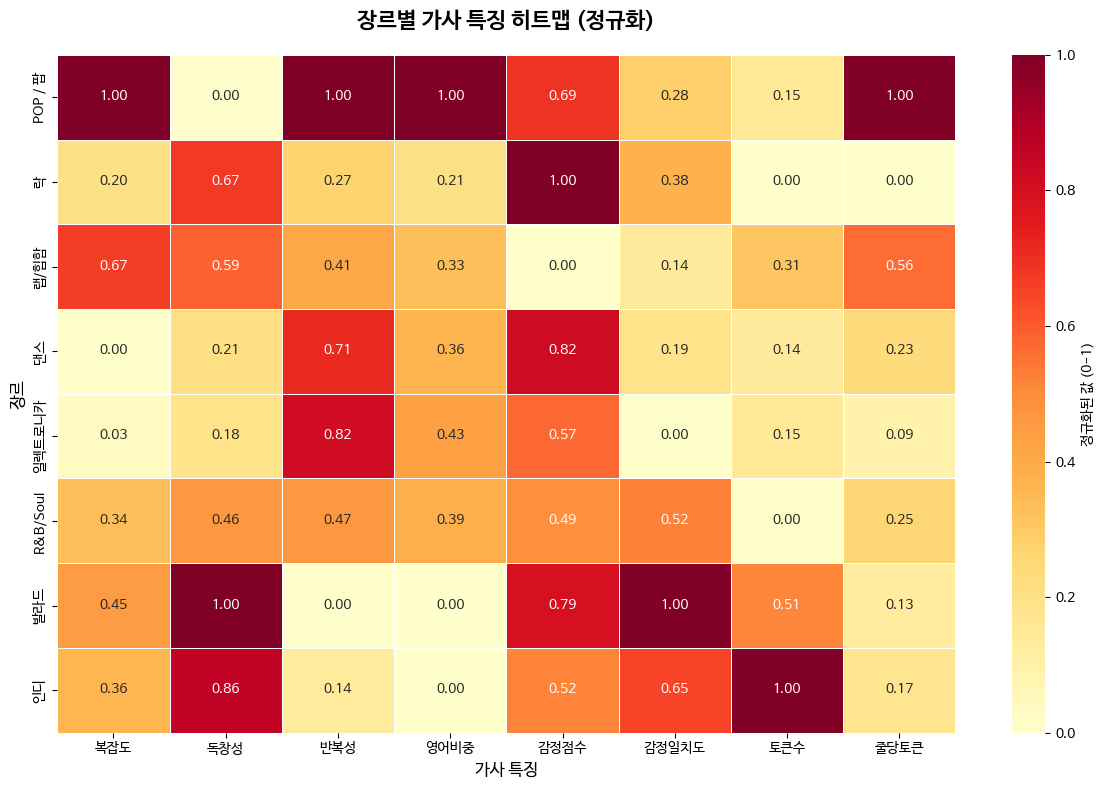


장르별 가사 특성 종합 분석 리포트

1. 분석 대상
   - 총 곡 수: 953곡
   - 장르 수: 8개
   - 장르 목록: 락, 댄스, 랩/힙합, 발라드, POP / 팝, 일렉트로니카, R&B/Soul, 인디

2. 조회수 순위 (평균)
   5. POP / 팝: 99.2M views
   1. 락: 25.7M views
   3. 랩/힙합: 24.2M views
   2. 댄스: 23.2M views
   6. 일렉트로니카: 18.2M views
   7. R&B/Soul: 10.2M views
   4. 발라드: 5.7M views
   8. 인디: 0.4M views

3. 가사 복잡도 순위
   5. POP / 팝: 0.580
   3. 랩/힙합: 0.556
   4. 발라드: 0.540
   8. 인디: 0.533
   7. R&B/Soul: 0.531
   1. 락: 0.521
   6. 일렉트로니카: 0.509
   2. 댄스: 0.506

4. 영어 비중 순위
   5. POP / 팝: 73.51%
   6. 일렉트로니카: 42.64%
   7. R&B/Soul: 40.36%
   2. 댄스: 39.04%
   3. 랩/힙합: 37.42%
   1. 락: 30.51%
   8. 인디: 19.31%
   4. 발라드: 19.28%

5. 주요 발견사항
   - 가장 복잡한 장르: POP / 팝 (0.580)
   - 가장 단순한 장르: 댄스 (0.506)
   - 영어 비중 최고: POP / 팝 (73.51%)
   - 반복성 최고: POP / 팝
   - 독창성 최고: 발라드



분석 완료! 생성된 파일:
1. genre_comprehensive_profile.csv - 장르별 종합 프로파일
2. genre_comprehensive_comparison.png - 6개 subplot 비교 그래프
3. genre_anova_results.csv - ANOVA 검정 결과
4. genre_features_heatmap.png - 히트맵
5. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 장르별 기본 통계 및 가사 특성 요약
# ============================================

def create_genre_profile(df):
    """장르별 종합 프로파일 생성"""

    genres = df['genie_genre'].unique()

    profile_data = []

    for genre in genres:
        genre_df = df[df['genie_genre'] == genre]

        profile = {
            '장르': genre,
            '곡수': len(genre_df),
            '평균_조회수': genre_df['api_view_count'].mean(),
            '중앙값_조회수': genre_df['api_view_count'].median(),

            # 가사 복잡도
            'avg_complexity': genre_df['lyrics_complexity_index'].mean(),
            'median_complexity': genre_df['lyrics_complexity_index'].median(),

            # 독창성/반복성
            'avg_unique_ratio': genre_df['unique_token_ratio'].mean(),
            'avg_repeated_ratio': genre_df['repeated_token_ratio'].mean(),

            # 언어 비중
            'avg_korean_ratio': genre_df['korean_ratio'].mean(),
            'avg_english_ratio': genre_df['english_ratio'].mean(),

            # 감정
            'avg_sentiment': genre_df['sentiment_compound'].mean(),
            'avg_positive_emotion': genre_df['positive_emotion_ratio'].mean(),
            'avg_negative_emotion': genre_df['negative_emotion_ratio'].mean(),

            # 가사 구조
            'avg_token_count': genre_df['token_count'].mean(),
            'avg_line_count': genre_df['line_count'].mean(),
            'avg_tokens_per_line': genre_df['avg_tokens_per_line'].mean(),

            # 멜로디-가사 일치도
            'avg_sentiment_congruence': genre_df['sentiment_congruence'].mean(),

            # 음향적 특성
            'avg_valence': genre_df['valence_normalized'].mean(),
            'avg_energy': genre_df['energy'].mean(),
            'avg_tempo': genre_df['tempo'].mean(),
        }

        profile_data.append(profile)

    profile_df = pd.DataFrame(profile_data)

    # 조회수 기준 정렬
    profile_df = profile_df.sort_values('평균_조회수', ascending=False)

    return profile_df

# 프로파일 생성
df_final['sentiment_congruence'] = abs(df_final['valence_normalized'] - df_final['sentiment_positive'])
genre_profile = create_genre_profile(df_final)

# 결과 저장
genre_profile.to_csv('genre_comprehensive_profile.csv', index=False, encoding='utf-8-sig')

print("=" * 80)
print("장르별 종합 프로파일")
print("=" * 80)
print(genre_profile.to_string())

# ============================================
# 2. 장르별 주요 특징 시각화 (6개 subplot)
# ============================================

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('장르별 가사 특성 종합 비교', fontsize=20, fontweight='bold', y=0.995)

# 정렬을 위해 장르 순서 결정 (조회수 기준)
genre_order = genre_profile.sort_values('평균_조회수', ascending=False)['장르'].tolist()

# 2-1. 가사 복잡도
ax1 = axes[0, 0]
sns.boxplot(data=df_final, x='genie_genre', y='lyrics_complexity_index',
            order=genre_order, palette='Set2', ax=ax1)
ax1.set_title('장르별 가사 복잡도 지수', fontsize=14, fontweight='bold')
ax1.set_xlabel('장르', fontsize=12)
ax1.set_ylabel('복잡도 지수', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 2-2. 독창성 vs 반복성
ax2 = axes[0, 1]
x = np.arange(len(genre_order))
width = 0.35
unique_means = [df_final[df_final['genie_genre']==g]['unique_token_ratio'].mean()
                for g in genre_order]
repeated_means = [df_final[df_final['genie_genre']==g]['repeated_token_ratio'].mean()
                  for g in genre_order]

bars1 = ax2.bar(x - width/2, unique_means, width, label='독창성', color='skyblue')
bars2 = ax2.bar(x + width/2, repeated_means, width, label='반복성', color='salmon')

ax2.set_title('장르별 독창성 vs 반복성', fontsize=14, fontweight='bold')
ax2.set_xlabel('장르', fontsize=12)
ax2.set_ylabel('비율', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(genre_order, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 2-3. 언어 비중 (한국어 vs 영어)
ax3 = axes[1, 0]
korean_means = [df_final[df_final['genie_genre']==g]['korean_ratio'].mean()
                for g in genre_order]
english_means = [df_final[df_final['genie_genre']==g]['english_ratio'].mean()
                 for g in genre_order]

bars1 = ax3.bar(x - width/2, korean_means, width, label='한국어', color='#FF6B6B')
bars2 = ax3.bar(x + width/2, english_means, width, label='영어', color='#4ECDC4')

ax3.set_title('장르별 언어 비중', fontsize=14, fontweight='bold')
ax3.set_xlabel('장르', fontsize=12)
ax3.set_ylabel('비율', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(genre_order, rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 2-4. 감정 점수
ax4 = axes[1, 1]
sns.boxplot(data=df_final, x='genie_genre', y='sentiment_compound',
            order=genre_order, palette='coolwarm', ax=ax4)
ax4.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_title('장르별 가사 감정 점수', fontsize=14, fontweight='bold')
ax4.set_xlabel('장르', fontsize=12)
ax4.set_ylabel('감정 점수 (Compound)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

# 2-5. 멜로디-가사 감정 일치도
ax5 = axes[2, 0]
sns.violinplot(data=df_final, x='genie_genre', y='sentiment_congruence',
               order=genre_order, palette='muted', ax=ax5)
ax5.set_title('장르별 멜로디-가사 감정 일치도', fontsize=14, fontweight='bold')
ax5.set_xlabel('장르', fontsize=12)
ax5.set_ylabel('일치도 (절댓값)', fontsize=12)
ax5.tick_params(axis='x', rotation=45)

# 2-6. 평균 조회수 (로그 스케일)
ax6 = axes[2, 1]
avg_views = [df_final[df_final['genie_genre']==g]['api_view_count'].mean()
             for g in genre_order]
bars = ax6.bar(x, avg_views, color='mediumpurple', alpha=0.7)
ax6.set_yscale('log')
ax6.set_title('장르별 평균 조회수 (로그 스케일)', fontsize=14, fontweight='bold')
ax6.set_xlabel('장르', fontsize=12)
ax6.set_ylabel('평균 조회수 (log)', fontsize=12)
ax6.set_xticks(x)
ax6.set_xticklabels(genre_order, rotation=45, ha='right')
ax6.grid(axis='y', alpha=0.3)

# 조회수 값 표시
for i, (bar, val) in enumerate(zip(bars, avg_views)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('genre_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 3. 장르별 "특징적 차별점" 추출
# ============================================

def find_genre_characteristics(df, profile_df):
    """각 장르의 두드러진 특징 추출"""

    characteristics = {}

    for genre in df['genie_genre'].unique():
        genre_row = profile_df[profile_df['장르'] == genre].iloc[0]

        traits = []

        # 복잡도
        if genre_row['avg_complexity'] > profile_df['avg_complexity'].quantile(0.75):
            traits.append(f"고복잡도 ({genre_row['avg_complexity']:.3f})")
        elif genre_row['avg_complexity'] < profile_df['avg_complexity'].quantile(0.25):
            traits.append(f"저복잡도 ({genre_row['avg_complexity']:.3f})")

        # 반복성
        if genre_row['avg_repeated_ratio'] > profile_df['avg_repeated_ratio'].quantile(0.75):
            traits.append(f"고반복성 ({genre_row['avg_repeated_ratio']:.3f})")
        elif genre_row['avg_repeated_ratio'] < profile_df['avg_repeated_ratio'].quantile(0.25):
            traits.append(f"저반복성 ({genre_row['avg_repeated_ratio']:.3f})")

        # 영어 비중
        if genre_row['avg_english_ratio'] > profile_df['avg_english_ratio'].quantile(0.75):
            traits.append(f"고영어비중 ({genre_row['avg_english_ratio']:.3f})")
        elif genre_row['avg_english_ratio'] < profile_df['avg_english_ratio'].quantile(0.25):
            traits.append(f"저영어비중 ({genre_row['avg_english_ratio']:.3f})")

        # 감정
        if genre_row['avg_sentiment'] > profile_df['avg_sentiment'].quantile(0.75):
            traits.append(f"긍정적 ({genre_row['avg_sentiment']:.3f})")
        elif genre_row['avg_sentiment'] < profile_df['avg_sentiment'].quantile(0.25):
            traits.append(f"부정적 ({genre_row['avg_sentiment']:.3f})")

        # 일치도
        if genre_row['avg_sentiment_congruence'] < profile_df['avg_sentiment_congruence'].quantile(0.25):
            traits.append(f"감정괴리높음 ({genre_row['avg_sentiment_congruence']:.3f})")

        characteristics[genre] = traits

    return characteristics

genre_chars = find_genre_characteristics(df_final, genre_profile)

print("\n" + "=" * 80)
print("장르별 두드러진 특징")
print("=" * 80)
for genre, traits in genre_chars.items():
    print(f"\n[{genre}]")
    for trait in traits:
        print(f"  - {trait}")

# ============================================
# 4. 장르 간 통계적 유의성 검정 (ANOVA + Post-hoc)
# ============================================

from scipy.stats import f_oneway
from scikit_posthocs import posthoc_dunn

# 주요 변수들에 대해 ANOVA 수행
key_variables = [
    'lyrics_complexity_index',
    'unique_token_ratio',
    'repeated_token_ratio',
    'english_ratio',
    'sentiment_compound',
    'sentiment_congruence'
]

print("\n" + "=" * 80)
print("장르 간 차이 검정 (ANOVA)")
print("=" * 80)

anova_results = []

for var in key_variables:
    groups = [df_final[df_final['genie_genre'] == g][var].dropna()
              for g in df_final['genie_genre'].unique()]

    f_stat, p_val = f_oneway(*groups)

    anova_results.append({
        '변수': var,
        'F-통계량': f_stat,
        'p-value': p_val,
        '유의함': 'Yes' if p_val < 0.05 else 'No'
    })

    print(f"\n{var}:")
    print(f"  F-통계량: {f_stat:.4f}")
    print(f"  p-value: {p_val:.6f}")
    print(f"  유의함: {'Yes (p<0.05)' if p_val < 0.05 else 'No'}")

anova_df = pd.DataFrame(anova_results)
anova_df.to_csv('genre_anova_results.csv', index=False, encoding='utf-8-sig')

# ============================================
# 5. 히트맵: 장르 × 가사특징 매트릭스
# ============================================

# 정규화된 값으로 히트맵 생성
heatmap_data = genre_profile.set_index('장르')[[
    'avg_complexity',
    'avg_unique_ratio',
    'avg_repeated_ratio',
    'avg_english_ratio',
    'avg_sentiment',
    'avg_sentiment_congruence',
    'avg_token_count',
    'avg_tokens_per_line'
]]

# 0-1 정규화
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
heatmap_normalized = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=['복잡도', '독창성', '반복성', '영어비중', '감정점수', '감정일치도', '토큰수', '줄당토큰']
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '정규화된 값 (0-1)'})
plt.title('장르별 가사 특징 히트맵 (정규화)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('가사 특징', fontsize=12)
plt.ylabel('장르', fontsize=12)
plt.tight_layout()
plt.savefig('genre_features_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. 요약 리포트 생성
# ============================================

summary_report = f"""
{'='*80}
장르별 가사 특성 종합 분석 리포트
{'='*80}

1. 분석 대상
   - 총 곡 수: {len(df_final)}곡
   - 장르 수: {df_final['genie_genre'].nunique()}개
   - 장르 목록: {', '.join(df_final['genie_genre'].unique())}

2. 조회수 순위 (평균)
"""

for idx, row in genre_profile.iterrows():
    summary_report += f"   {idx+1}. {row['장르']}: {row['평균_조회수']/1e6:.1f}M views\n"

summary_report += f"""
3. 가사 복잡도 순위
"""

complexity_ranking = genre_profile.sort_values('avg_complexity', ascending=False)
for idx, row in complexity_ranking.iterrows():
    summary_report += f"   {idx+1}. {row['장르']}: {row['avg_complexity']:.3f}\n"

summary_report += f"""
4. 영어 비중 순위
"""

english_ranking = genre_profile.sort_values('avg_english_ratio', ascending=False)
for idx, row in english_ranking.iterrows():
    summary_report += f"   {idx+1}. {row['장르']}: {row['avg_english_ratio']:.2%}\n"

summary_report += f"""
5. 주요 발견사항
   - 가장 복잡한 장르: {complexity_ranking.iloc[0]['장르']} ({complexity_ranking.iloc[0]['avg_complexity']:.3f})
   - 가장 단순한 장르: {complexity_ranking.iloc[-1]['장르']} ({complexity_ranking.iloc[-1]['avg_complexity']:.3f})
   - 영어 비중 최고: {english_ranking.iloc[0]['장르']} ({english_ranking.iloc[0]['avg_english_ratio']:.2%})
   - 반복성 최고: {genre_profile.sort_values('avg_repeated_ratio', ascending=False).iloc[0]['장르']}
   - 독창성 최고: {genre_profile.sort_values('avg_unique_ratio', ascending=False).iloc[0]['장르']}

{'='*80}
"""

print(summary_report)

# 리포트 저장
with open('genre_analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)

print("\n분석 완료! 생성된 파일:")
print("1. genre_comprehensive_profile.csv - 장르별 종합 프로파일")
print("2. genre_comprehensive_comparison.png - 6개 subplot 비교 그래프")
print("3. genre_anova_results.csv - ANOVA 검정 결과")
print("4. genre_features_heatmap.png - 히트맵")
print("5. genre_analysis_summary.txt - 요약 리포트")

In [ ]:
!pip install scikit_posthocs

In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 954
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   url                      953 non-null    object 
 1   songName                 953 non-null    object 
 2   artists                  953 non-null    object 
 3   publishTime              953 non-null    object 
 4   video_id                 953 non-null    object 
 5   api_view_count           953 non-null    int64  
 6   api_like_count           953 non-null    int64  
 7   api_comment_count        953 non-null    int64  
 8   api_published_at         953 non-null    object 
 9   api_duration             953 non-null    object 
 10  api_title                953 non-null    object 
 11  api_channel_title        953 non-null    object 
 12  valence_raw              953 non-null    float64
 13  arousal_raw              953 non-null    float64
 14  valence_normalized       953 no

장르별 가사 특성 종합 프로파일
         장르   곡수        평균_조회수     가사_감정     긍정_비율     부정_비율       독창성       반복성          토큰수  평균_토큰_길이  hapax_legomenon          줄수     줄당_토큰    줄당_독창성   문장부호_비율       압축률    대명사_빈도    한국어_비율     영어_비율
4   POP / 팝    7  9.922037e+07  0.784443  0.892229  0.107771  0.277943  0.722057   568.857143  2.737143        81.285714   65.142857  8.140000  7.170000  0.049943  0.353643  0.135157  0.000000  0.735129
0         락  118  2.571674e+07  0.839294  0.919643  0.080357  0.373992  0.617533   426.313559  2.124237        88.584746   59.593220  5.984576  5.447119  0.038750  0.430829  0.093351  0.444543  0.305120
2      랩/힙합  111  2.418257e+07  0.661713  0.830857  0.169143  0.361725  0.638275   713.846847  2.245586       163.297297   89.387387  7.198018  6.253694  0.052182  0.443380  0.088989  0.359187  0.374160
1        댄스  467  2.318221e+07  0.807424  0.903710  0.096290  0.308073  0.681221   557.149893  2.186317        92.835118   74.888651  6.488908  5.602848  0.063310  0.4109

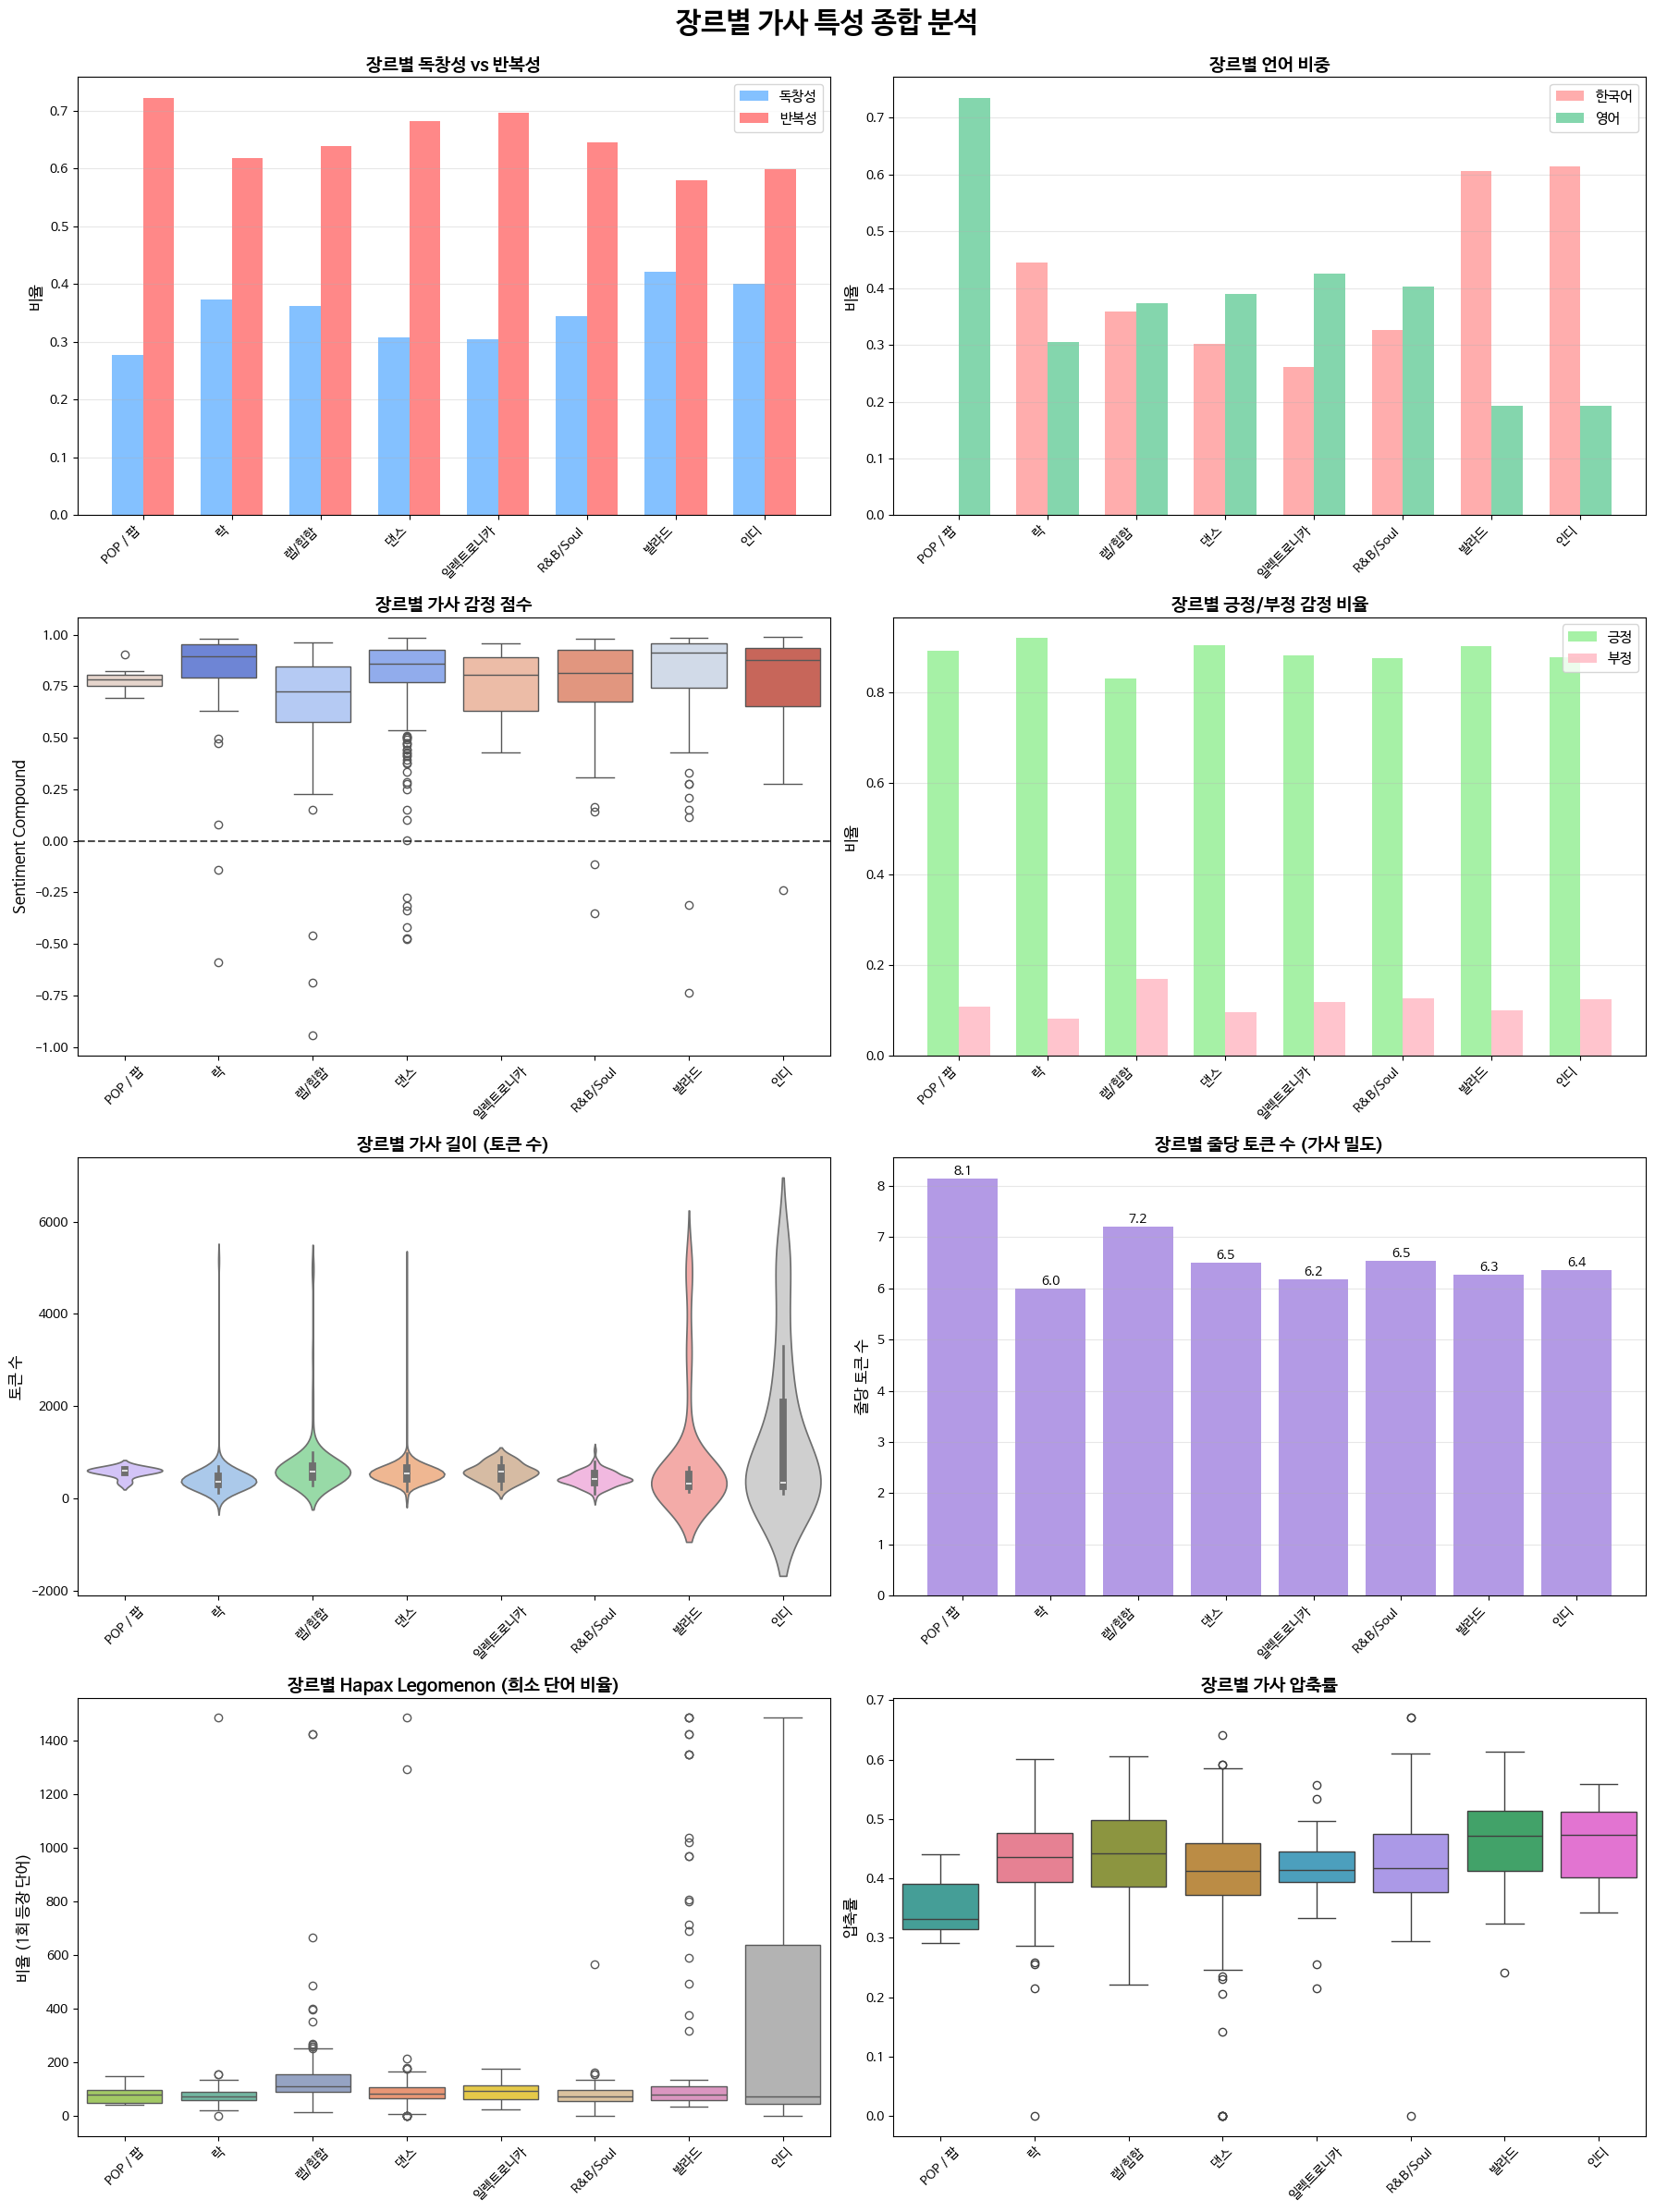

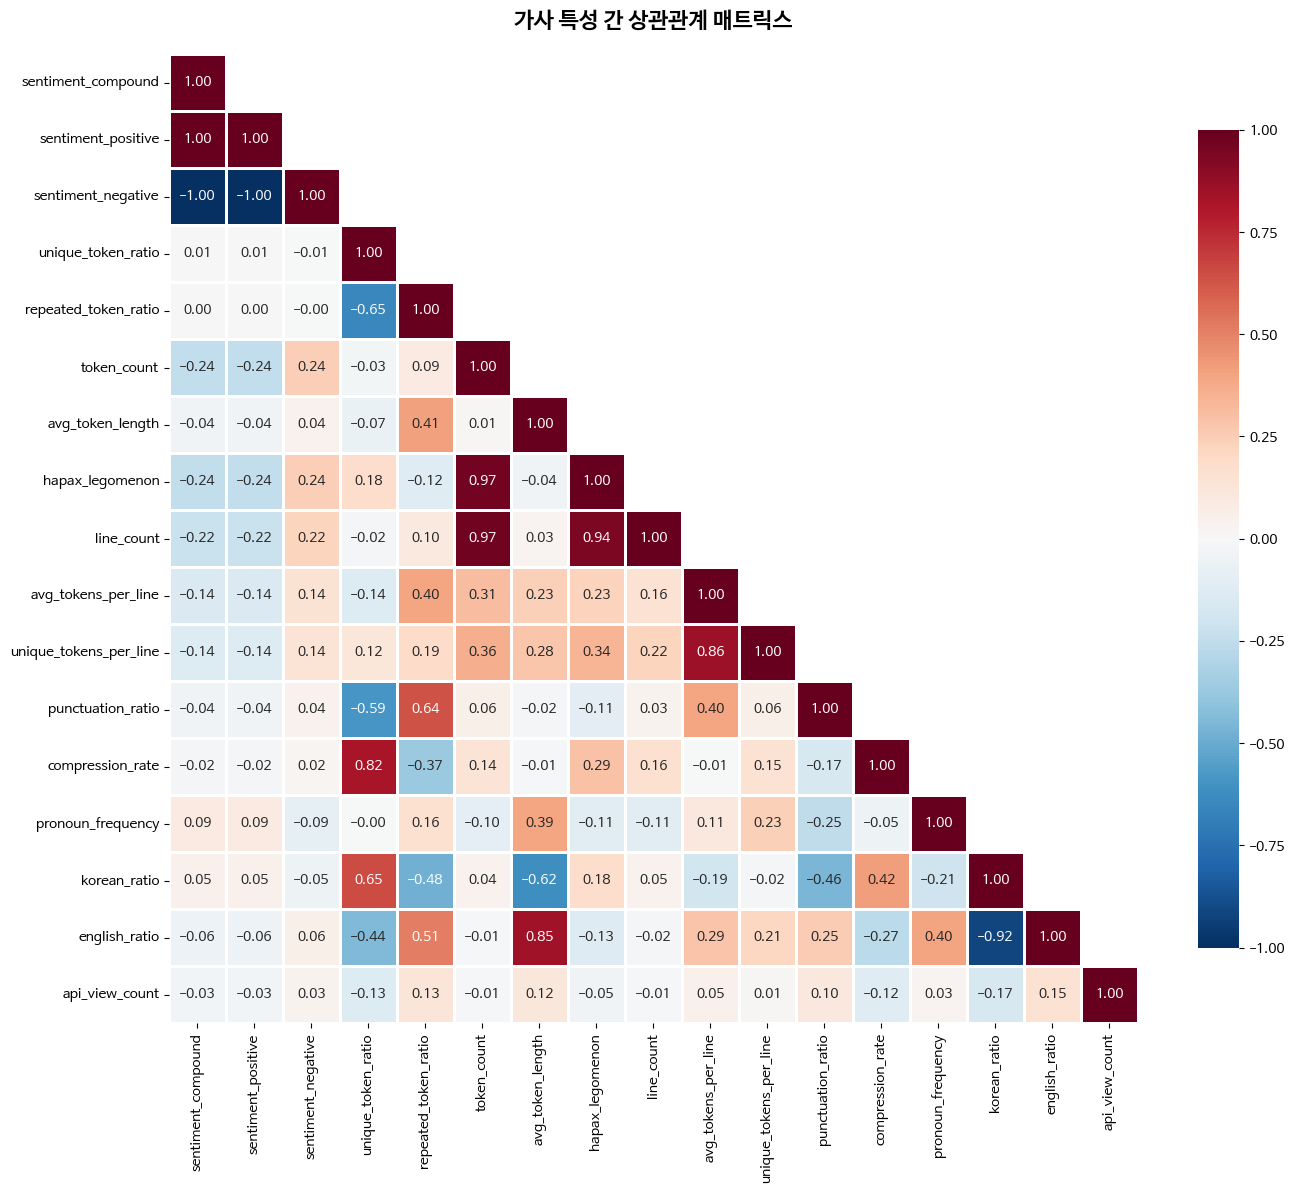


조회수 상위 10% vs 하위 10% 가사 특성 비교
                        변수   상위_10%_평균   하위_10%_평균          차이      차이율(%)
5              token_count  541.854167  870.177083 -328.322917  -37.730586
7          hapax_legomenon   86.406250  231.208333 -144.802083  -62.628402
8               line_count   73.031250  106.114583  -33.083333  -31.176990
9      avg_tokens_per_line    6.715000    6.354479    0.360521    5.673491
6         avg_token_length    2.408750    2.101562    0.307187   14.617100
14            korean_ratio    0.205921    0.504826   -0.298905  -59.209546
15           english_ratio    0.495724    0.268019    0.227705   84.958686
10  unique_tokens_per_line    5.835312    5.978125   -0.142813   -2.388918
4     repeated_token_ratio    0.697494    0.599170    0.098324   16.410033
3       unique_token_ratio    0.302506    0.390415   -0.087908  -22.516662
12        compression_rate    0.405101    0.449160   -0.044059   -9.809274
0       sentiment_compound    0.717842    0.756695   -0.038853   -5.1

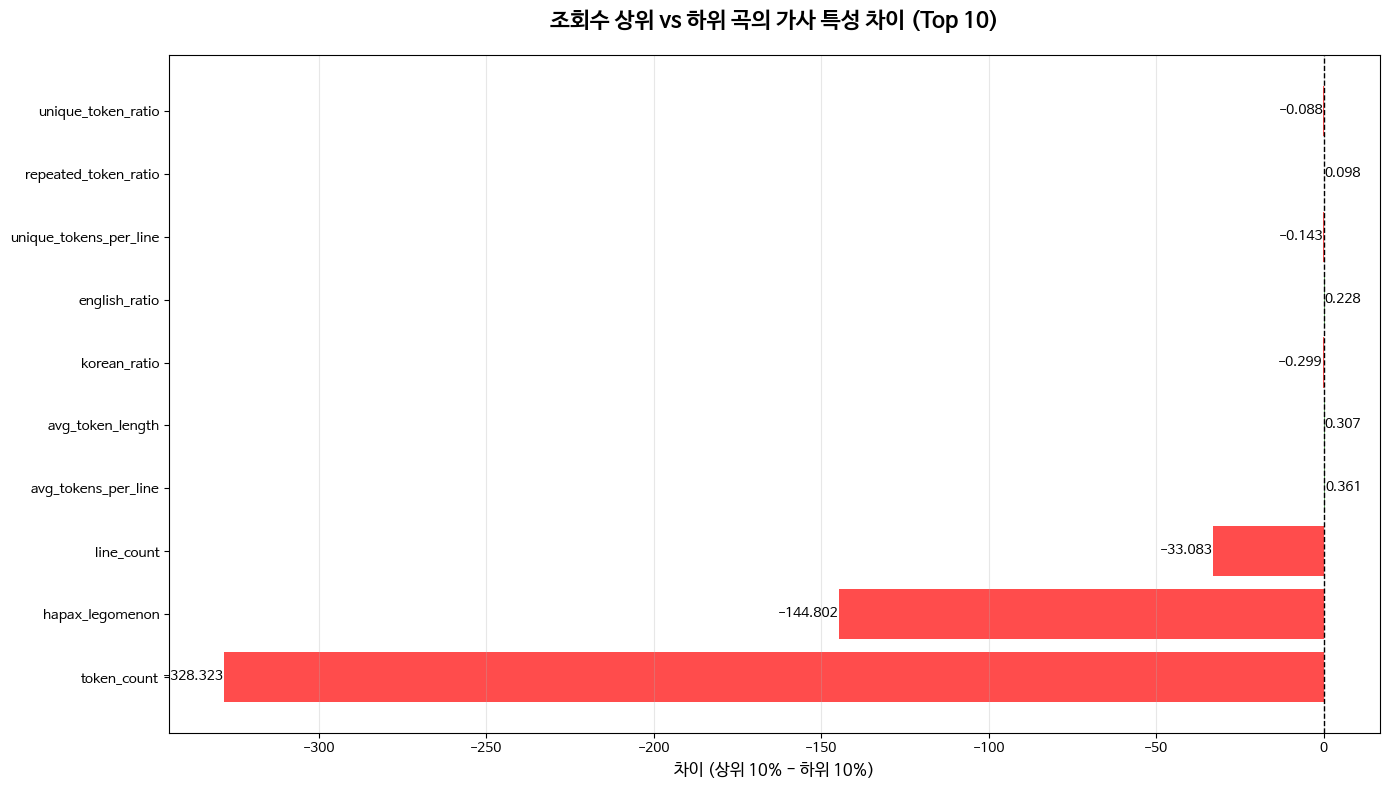


장르별 두드러진 특징

[POP / 팝] (7곡, 평균 99.2M views)
  ✓ 독창성 낮음 (0.278)
  ✓ 반복성 높음 (0.722)
  ✓ 영어 비중 높음 (73.51%)

[락] (118곡, 평균 25.7M views)
  ✓ 가사 짧음 (토큰 426개)
  ✓ 가사 긍정적 (0.839)

[랩/힙합] (111곡, 평균 24.2M views)
  ✓ 가사 부정적 (0.662)

[댄스] (467곡, 평균 23.2M views)
  ✓ 가사 긍정적 (0.807)

[일렉트로니카] (20곡, 평균 18.2M views)
  ✓ 독창성 낮음 (0.304)
  ✓ 반복성 높음 (0.696)
  ✓ 영어 비중 높음 (42.64%)

[R&B/Soul] (98곡, 평균 10.2M views)
  ✓ 가사 짧음 (토큰 428개)
  ✓ 가사 부정적 (0.749)

[발라드] (107곡, 평균 5.7M views)
  ✓ 독창성 높음 (0.420)
  ✓ 반복성 낮음 (0.580)
  ✓ 영어 비중 낮음 (19.28%)
  ✓ 가사 긺 (토큰 900개)

[인디] (25곡, 평균 0.4M views)
  ✓ 독창성 높음 (0.401)
  ✓ 반복성 낮음 (0.599)
  ✓ 영어 비중 낮음 (19.31%)
  ✓ 가사 긺 (토큰 1348개)

가사 특성 종합 분석 리포트

1. 분석 개요
   - 총 곡 수: 953곡
   - 장르 수: 8개
   - 분석 변수: 16개

2. 조회수와의 상관관계 (Top 5)
   15. korean_ratio: -0.1666 (Yes)
   16. english_ratio: 0.1536 (Yes)
   4. unique_token_ratio: -0.1332 (Yes)
   5. repeated_token_ratio: 0.1300 (Yes)
   13. compression_rate: -0.1203 (Yes)

3. 장르별 주요 특징
   - 가장 독창적: 발라드 (0.420)
   - 가장 반복적: POP / 팝 (0.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# 1. 장르별 가사 특성 프로파일 (기존 변수만 사용)
# ============================================

def create_lyrics_profile(df):
    """장르별 가사 특성 종합 프로파일"""

    genres = df['genie_genre'].unique()
    profile_data = []

    for genre in genres:
        genre_df = df[df['genie_genre'] == genre]

        profile = {
            '장르': genre,
            '곡수': len(genre_df),
            '평균_조회수': genre_df['api_view_count'].mean(),

            # 감정
            '가사_감정': genre_df['sentiment_compound'].mean(),
            '긍정_비율': genre_df['sentiment_positive'].mean(),
            '부정_비율': genre_df['sentiment_negative'].mean(),

            # 복잡도/다양성
            '독창성': genre_df['unique_token_ratio'].mean(),
            '반복성': genre_df['repeated_token_ratio'].mean(),
            '토큰수': genre_df['token_count'].mean(),
            '평균_토큰_길이': genre_df['avg_token_length'].mean(),

            # 희소 단어 (1번만 나오는 단어)
            'hapax_legomenon': genre_df['hapax_legomenon'].mean(),

            # 구조
            '줄수': genre_df['line_count'].mean(),
            '줄당_토큰': genre_df['avg_tokens_per_line'].mean(),
            '줄당_독창성': genre_df['unique_tokens_per_line'].mean(),

            # 스타일
            '문장부호_비율': genre_df['punctuation_ratio'].mean(),
            '압축률': genre_df['compression_rate'].mean(),
            '대명사_빈도': genre_df['pronoun_frequency'].mean(),

            # 언어
            '한국어_비율': genre_df['korean_ratio'].mean(),
            '영어_비율': genre_df['english_ratio'].mean(),
        }

        profile_data.append(profile)

    profile_df = pd.DataFrame(profile_data)
    profile_df = profile_df.sort_values('평균_조회수', ascending=False)

    return profile_df

lyrics_profile = create_lyrics_profile(df_final)

print("="*100)
print("장르별 가사 특성 종합 프로파일")
print("="*100)
print(lyrics_profile.to_string())

lyrics_profile.to_csv('lyrics_genre_profile.csv', index=False, encoding='utf-8-sig')

# ============================================
# 2. 조회수와 가사 특성의 상관관계 분석
# ============================================

lyrics_features = [
    'sentiment_compound', 'sentiment_positive', 'sentiment_negative',
    'unique_token_ratio', 'repeated_token_ratio', 'token_count',
    'avg_token_length', 'hapax_legomenon',
    'line_count', 'avg_tokens_per_line', 'unique_tokens_per_line',
    'punctuation_ratio', 'compression_rate', 'pronoun_frequency',
    'korean_ratio', 'english_ratio'
]

correlations = []
for col in lyrics_features:
    corr, pval = stats.pearsonr(df_final[col], df_final['api_view_count'])
    correlations.append({
        '변수': col,
        '상관계수': corr,
        'p-value': pval,
        '유의함': 'Yes' if pval < 0.05 else 'No'
    })

corr_df = pd.DataFrame(correlations).sort_values('상관계수', key=abs, ascending=False)

print("\n" + "="*100)
print("가사 특성과 조회수의 상관관계 (상관계수 절댓값 순)")
print("="*100)
print(corr_df.to_string())

corr_df.to_csv('lyrics_viewcount_correlation.csv', index=False, encoding='utf-8-sig')

# ============================================
# 3. 시각화 1: 8개 subplot - 주요 가사 특성
# ============================================

fig, axes = plt.subplots(4, 2, figsize=(18, 24))
fig.suptitle('장르별 가사 특성 종합 분석', fontsize=22, fontweight='bold', y=0.995)

genre_order = lyrics_profile['장르'].tolist()
x = np.arange(len(genre_order))
width = 0.35

# 3-1. 독창성 vs 반복성
ax1 = axes[0, 0]
unique = [df_final[df_final['genie_genre']==g]['unique_token_ratio'].mean() for g in genre_order]
repeated = [df_final[df_final['genie_genre']==g]['repeated_token_ratio'].mean() for g in genre_order]
ax1.bar(x - width/2, unique, width, label='독창성', color='#66B2FF', alpha=0.8)
ax1.bar(x + width/2, repeated, width, label='반복성', color='#FF6B6B', alpha=0.8)
ax1.set_title('장르별 독창성 vs 반복성', fontsize=14, fontweight='bold')
ax1.set_ylabel('비율', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(genre_order, rotation=45, ha='right')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# 3-2. 언어 비중
ax2 = axes[0, 1]
korean = [df_final[df_final['genie_genre']==g]['korean_ratio'].mean() for g in genre_order]
english = [df_final[df_final['genie_genre']==g]['english_ratio'].mean() for g in genre_order]
ax2.bar(x - width/2, korean, width, label='한국어', color='#FF9999', alpha=0.8)
ax2.bar(x + width/2, english, width, label='영어', color='#66CC99', alpha=0.8)
ax2.set_title('장르별 언어 비중', fontsize=14, fontweight='bold')
ax2.set_ylabel('비율', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(genre_order, rotation=45, ha='right')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# 3-3. 가사 감정 점수
ax3 = axes[1, 0]
sns.boxplot(data=df_final, x='genie_genre', y='sentiment_compound',
            order=genre_order, ax=ax3, hue='genie_genre', legend=False, palette='coolwarm')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.set_title('장르별 가사 감정 점수', fontsize=14, fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Sentiment Compound', fontsize=12)
ax3.tick_params(axis='x', rotation=45)

# 3-4. 긍정/부정 감정 비율
ax4 = axes[1, 1]
positive = [df_final[df_final['genie_genre']==g]['sentiment_positive'].mean() for g in genre_order]
negative = [df_final[df_final['genie_genre']==g]['sentiment_negative'].mean() for g in genre_order]
ax4.bar(x - width/2, positive, width, label='긍정', color='#90EE90', alpha=0.8)
ax4.bar(x + width/2, negative, width, label='부정', color='#FFB6C1', alpha=0.8)
ax4.set_title('장르별 긍정/부정 감정 비율', fontsize=14, fontweight='bold')
ax4.set_ylabel('비율', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(genre_order, rotation=45, ha='right')
ax4.legend(fontsize=11)
ax4.grid(axis='y', alpha=0.3)

# 3-5. 토큰 수 (가사 길이)
ax5 = axes[2, 0]
sns.violinplot(data=df_final, x='genie_genre', y='token_count',
               order=genre_order, ax=ax5, hue='genie_genre', legend=False, palette='pastel')
ax5.set_title('장르별 가사 길이 (토큰 수)', fontsize=14, fontweight='bold')
ax5.set_xlabel('')
ax5.set_ylabel('토큰 수', fontsize=12)
ax5.tick_params(axis='x', rotation=45)

# 3-6. 줄당 토큰 수 (밀도)
ax6 = axes[2, 1]
tokens_per_line = [df_final[df_final['genie_genre']==g]['avg_tokens_per_line'].mean() for g in genre_order]
bars = ax6.bar(x, tokens_per_line, color='mediumpurple', alpha=0.7)
ax6.set_title('장르별 줄당 토큰 수 (가사 밀도)', fontsize=14, fontweight='bold')
ax6.set_ylabel('줄당 토큰 수', fontsize=12)
ax6.set_xticks(x)
ax6.set_xticklabels(genre_order, rotation=45, ha='right')
ax6.grid(axis='y', alpha=0.3)
# 값 표시
for i, (bar, val) in enumerate(zip(bars, tokens_per_line)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# 3-7. Hapax Legomenon (한 번만 나오는 단어 비율)
ax7 = axes[3, 0]
sns.boxplot(data=df_final, x='genie_genre', y='hapax_legomenon',
            order=genre_order, ax=ax7, hue='genie_genre', legend=False, palette='Set2')
ax7.set_title('장르별 Hapax Legomenon (희소 단어 비율)', fontsize=14, fontweight='bold')
ax7.set_xlabel('')
ax7.set_ylabel('비율 (1회 등장 단어)', fontsize=12)
ax7.tick_params(axis='x', rotation=45)

# 3-8. 압축률
ax8 = axes[3, 1]
sns.boxplot(data=df_final, x='genie_genre', y='compression_rate',
            order=genre_order, ax=ax8, hue='genie_genre', legend=False, palette='husl')
ax8.set_title('장르별 가사 압축률', fontsize=14, fontweight='bold')
ax8.set_xlabel('')
ax8.set_ylabel('압축률', fontsize=12)
ax8.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('lyrics_genre_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 4. 시각화 2: 상관관계 히트맵
# ============================================

# 주요 가사 변수들의 상관관계
corr_matrix = df_final[lyrics_features + ['api_view_count']].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            mask=mask, vmin=-1, vmax=1)
plt.title('가사 특성 간 상관관계 매트릭스', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('lyrics_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. 조회수 상위 vs 하위 비교
# ============================================

# 상위 10% vs 하위 10%
top_10_threshold = df_final['api_view_count'].quantile(0.9)
bottom_10_threshold = df_final['api_view_count'].quantile(0.1)

top_songs = df_final[df_final['api_view_count'] >= top_10_threshold]
bottom_songs = df_final[df_final['api_view_count'] <= bottom_10_threshold]

comparison_data = []
for feature in lyrics_features:
    comparison_data.append({
        '변수': feature,
        '상위_10%_평균': top_songs[feature].mean(),
        '하위_10%_평균': bottom_songs[feature].mean(),
        '차이': top_songs[feature].mean() - bottom_songs[feature].mean(),
        '차이율(%)': ((top_songs[feature].mean() / bottom_songs[feature].mean() - 1) * 100)
                    if bottom_songs[feature].mean() != 0 else 0
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('차이', key=abs, ascending=False)

print("\n" + "="*100)
print("조회수 상위 10% vs 하위 10% 가사 특성 비교")
print("="*100)
print(comparison_df.to_string())

comparison_df.to_csv('lyrics_top_vs_bottom_comparison.csv', index=False, encoding='utf-8-sig')

# 시각화: 상위 vs 하위 비교
fig, ax = plt.subplots(figsize=(14, 8))

top_10_features = comparison_df.head(10)
y_pos = np.arange(len(top_10_features))

colors = ['green' if x > 0 else 'red' for x in top_10_features['차이']]
bars = ax.barh(y_pos, top_10_features['차이'], color=colors, alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_10_features['변수'])
ax.set_xlabel('차이 (상위 10% - 하위 10%)', fontsize=12)
ax.set_title('조회수 상위 vs 하위 곡의 가사 특성 차이 (Top 10)',
             fontsize=16, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)

# 값 표시
for i, (bar, val) in enumerate(zip(bars, top_10_features['차이'])):
    width = bar.get_width()
    label_x_pos = width + (0.01 if width > 0 else -0.01)
    ax.text(label_x_pos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='left' if width > 0 else 'right',
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('lyrics_top_vs_bottom_difference.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. 장르별 특이점 분석
# ============================================

print("\n" + "="*100)
print("장르별 두드러진 특징")
print("="*100)

for genre in genre_order:
    genre_row = lyrics_profile[lyrics_profile['장르'] == genre].iloc[0]

    print(f"\n[{genre}] ({genre_row['곡수']}곡, 평균 {genre_row['평균_조회수']/1e6:.1f}M views)")

    # 독창성
    if genre_row['독창성'] > lyrics_profile['독창성'].quantile(0.75):
        print(f"  ✓ 독창성 높음 ({genre_row['독창성']:.3f})")
    elif genre_row['독창성'] < lyrics_profile['독창성'].quantile(0.25):
        print(f"  ✓ 독창성 낮음 ({genre_row['독창성']:.3f})")

    # 반복성
    if genre_row['반복성'] > lyrics_profile['반복성'].quantile(0.75):
        print(f"  ✓ 반복성 높음 ({genre_row['반복성']:.3f})")
    elif genre_row['반복성'] < lyrics_profile['반복성'].quantile(0.25):
        print(f"  ✓ 반복성 낮음 ({genre_row['반복성']:.3f})")

    # 영어 비중
    if genre_row['영어_비율'] > lyrics_profile['영어_비율'].quantile(0.75):
        print(f"  ✓ 영어 비중 높음 ({genre_row['영어_비율']:.2%})")
    elif genre_row['영어_비율'] < lyrics_profile['영어_비율'].quantile(0.25):
        print(f"  ✓ 영어 비중 낮음 ({genre_row['영어_비율']:.2%})")

    # 가사 길이
    if genre_row['토큰수'] > lyrics_profile['토큰수'].quantile(0.75):
        print(f"  ✓ 가사 긺 (토큰 {genre_row['토큰수']:.0f}개)")
    elif genre_row['토큰수'] < lyrics_profile['토큰수'].quantile(0.25):
        print(f"  ✓ 가사 짧음 (토큰 {genre_row['토큰수']:.0f}개)")

    # 감정
    if genre_row['가사_감정'] > lyrics_profile['가사_감정'].quantile(0.75):
        print(f"  ✓ 가사 긍정적 ({genre_row['가사_감정']:.3f})")
    elif genre_row['가사_감정'] < lyrics_profile['가사_감정'].quantile(0.25):
        print(f"  ✓ 가사 부정적 ({genre_row['가사_감정']:.3f})")

# ============================================
# 7. 요약 리포트 생성
# ============================================

summary = f"""
{'='*100}
가사 특성 종합 분석 리포트
{'='*100}

1. 분석 개요
   - 총 곡 수: {len(df_final)}곡
   - 장르 수: {df_final['genie_genre'].nunique()}개
   - 분석 변수: {len(lyrics_features)}개

2. 조회수와의 상관관계 (Top 5)
"""

top_corr = corr_df.head(5)
for idx, row in top_corr.iterrows():
    summary += f"   {idx+1}. {row['변수']}: {row['상관계수']:.4f} ({row['유의함']})\n"

summary += f"""
3. 장르별 주요 특징
   - 가장 독창적: {lyrics_profile.sort_values('독창성', ascending=False).iloc[0]['장르']} ({lyrics_profile.sort_values('독창성', ascending=False).iloc[0]['독창성']:.3f})
   - 가장 반복적: {lyrics_profile.sort_values('반복성', ascending=False).iloc[0]['장르']} ({lyrics_profile.sort_values('반복성', ascending=False).iloc[0]['반복성']:.3f})
   - 영어 비중 최고: {lyrics_profile.sort_values('영어_비율', ascending=False).iloc[0]['장르']} ({lyrics_profile.sort_values('영어_비율', ascending=False).iloc[0]['영어_비율']:.2%})
   - 가사 가장 긺: {lyrics_profile.sort_values('토큰수', ascending=False).iloc[0]['장르']} ({lyrics_profile.sort_values('토큰수', ascending=False).iloc[0]['토큰수']:.0f} 토큰)

4. 상위 vs 하위 곡 차이 (Top 3)
"""

top_diff = comparison_df.head(3)
for idx, row in top_diff.iterrows():
    summary += f"   {idx+1}. {row['변수']}: 차이 {row['차이']:.3f} ({row['차이율(%)']:.1f}%)\n"

summary += f"""
{'='*100}
"""

print(summary)

with open('lyrics_analysis_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print("\n✅ 분석 완료! 생성된 파일:")
print("1. lyrics_genre_profile.csv - 장르별 종합 프로파일")
print("2. lyrics_viewcount_correlation.csv - 조회수 상관관계")
print("3. lyrics_top_vs_bottom_comparison.csv - 상위/하위 비교")
print("4. lyrics_genre_comprehensive_analysis.png - 8개 subplot")
print("5. lyrics_correlation_heatmap.png - 상관관계 히트맵")
print("6. lyrics_top_vs_bottom_difference.png - 상위/하위 차이 시각화")
print("7. lyrics_analysis_summary.txt - 요약 리포트")

### 1-17. 상관관계 히트맵

**분석**: 오디오(valence, arousal, energy, tempo 등)·감성·언어 지표를 모아 상관계수 행렬 히트맵 생성.

In [ ]:
# 분석에 필요한 컬럼 리스트 정의
target_columns = [
    'genie_genre', 'valence_raw', 'arousal_raw', 'valence_normalized', 'arousal_normalized',
    'energy', 'energy_variance', 'loudness', 'tempo', 'duration_ms',
    'speechiness', 'speech_duration_sec', 'acoustic_score', 'sentiment_compound',
    'sentiment_positive', 'sentiment_negative', 'sentiment_neutral',
    'avg_brightness', 'avg_motion', 'avg_r_value', 'avg_g_value', 'avg_b_value',
    'video_duration', 'token_count', 'unique_token_ratio', 'repeated_token_ratio',
    'avg_token_length', 'hapax_legomenon', 'hapax_dislegomenon', 'hapax_trislegomenon',
    'unique_tokens_per_line', 'avg_tokens_per_line', 'line_count',
    'punctuation_ratio', 'compression_rate', 'pronoun_frequency',
    'korean_ratio', 'english_ratio', 'daily_view_count'
]

# 새로운 데이터프레임 생성
분석_df = df_final[target_columns].copy()

# 데이터 요약 정보 확인
print(분석_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 954
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   genie_genre             952 non-null    object 
 1   valence_raw             952 non-null    float64
 2   arousal_raw             952 non-null    float64
 3   valence_normalized      952 non-null    float64
 4   arousal_normalized      952 non-null    float64
 5   energy                  952 non-null    float64
 6   energy_variance         952 non-null    float64
 7   loudness                952 non-null    float64
 8   tempo                   952 non-null    float64
 9   duration_ms             952 non-null    float64
 10  speechiness             952 non-null    float64
 11  speech_duration_sec     952 non-null    float64
 12  acoustic_score          952 non-null    float64
 13  sentiment_compound      952 non-null    float64
 14  sentiment_positive      952 non-null    float64

In [ ]:
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


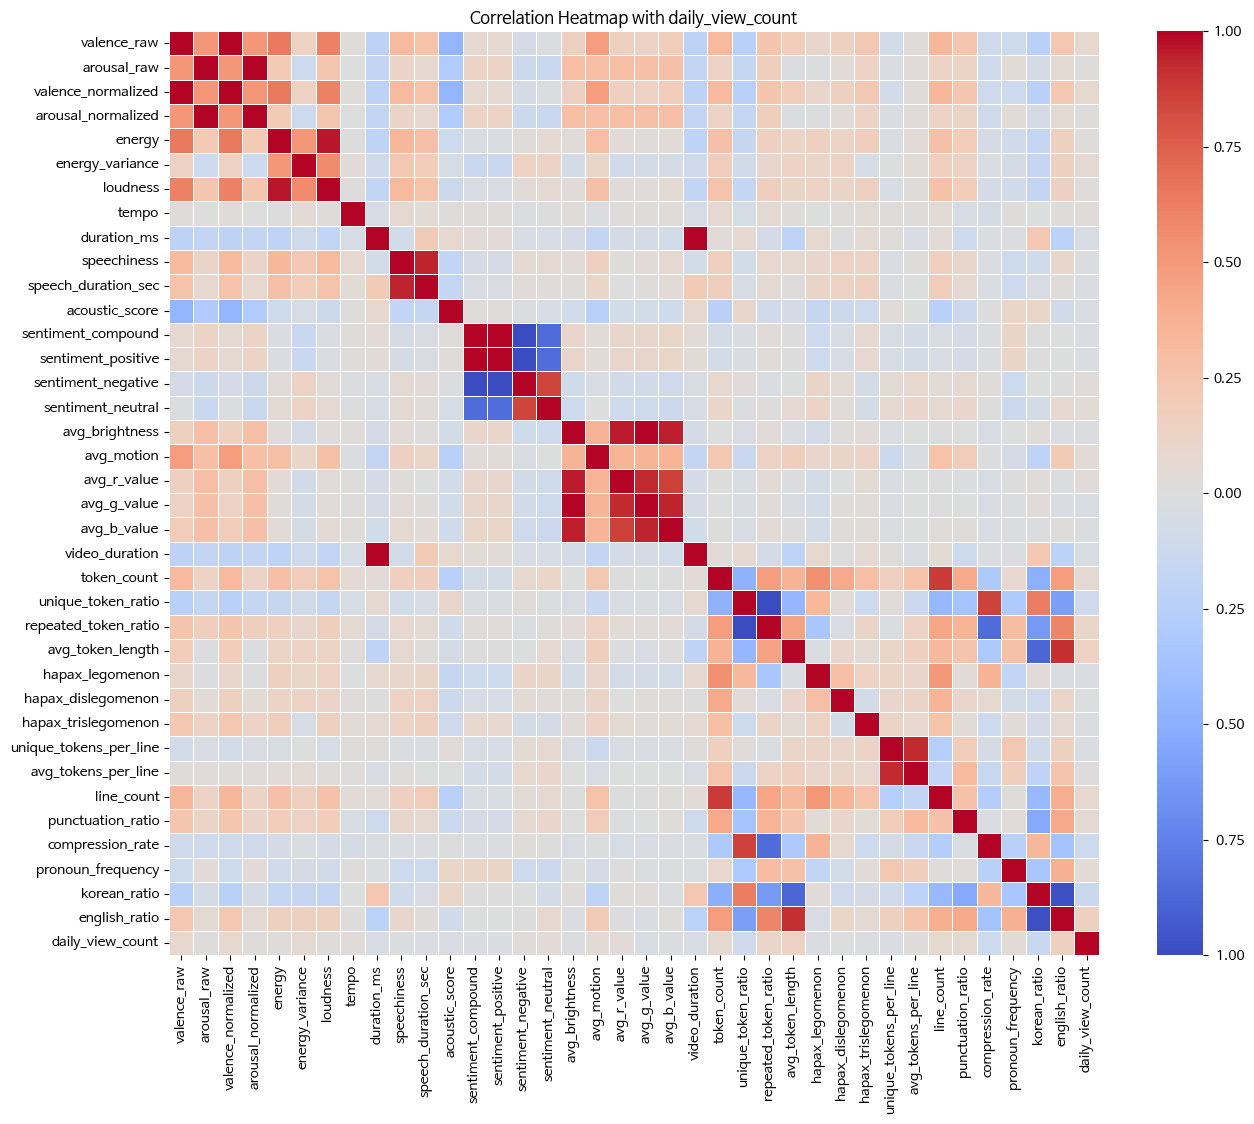

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 수치형 컬럼들만 선택
numeric_df = 분석_df.select_dtypes(include=['float64', 'int64'])

# 2. 상관계수 행렬 계산
corr_matrix = numeric_df.corr()

# 3. daily_view_count와의 상관관계만 따로 정렬해서 보기 (선택 사항)
# print(corr_matrix['daily_view_count'].sort_values(ascending=False))

# 4. 히트맵 시각화
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap with daily_view_count')
plt.show()

### 1-18. 상관관계 상위 10개

**분석**: `daily_view_count`와 상관계수 절댓값 기준 상위 10개 변수만 추출, 장르별 `daily_view_count` 분포(로그 스케일)도 함께 확인.

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


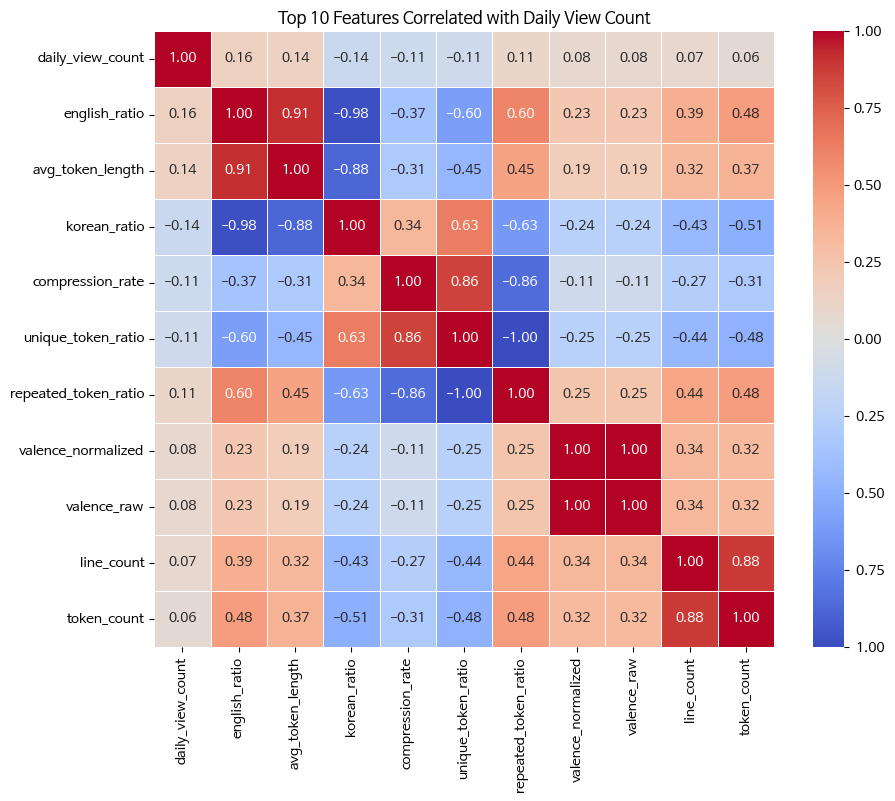

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 수치형 데이터만 추출
numeric_df = 분석_df.select_dtypes(include=[np.number])

# 2. 모든 변수와 daily_view_count 간의 상관계수 계산
correlations = numeric_df.corr()['daily_view_count'].abs().sort_values(ascending=False)

# 3. 상위 11개 추출 (자기 자신인 daily_view_count 포함)
top_10_features = correlations.head(11).index
top_10_corr_matrix = numeric_df[top_10_features].corr()

# 4. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(top_10_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Top 10 Features Correlated with Daily View Count')
plt.show()

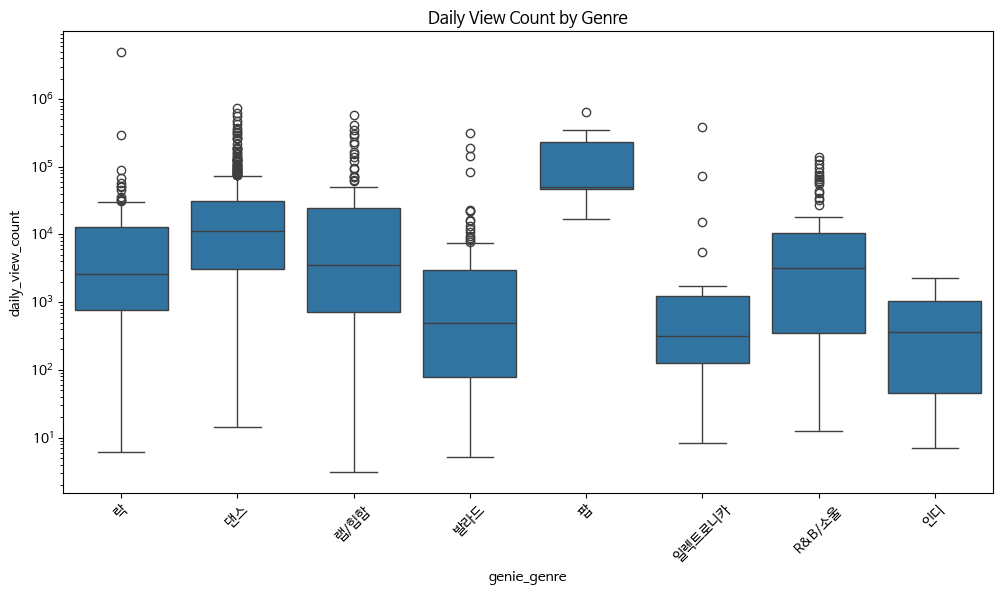

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='genie_genre', y='daily_view_count', data=df_final)
plt.xticks(rotation=45)
plt.title('Daily View Count by Genre')
plt.yscale('log') # 조회수 편차가 크다면 로그 스케일로 보는 것이 좋습니다.
plt.show()

### 1-19. 장르별 핵심 오디오 특징 (레이더차트용 데이터)

**분석**: energy, valence, arousal, speechiness, acoustic_score의 장르별 평균값을 계산해 레이더차트용 프로필 데이터 생성.

--- 장르별 오디오 특징 평균 프로필 ---
               energy  valence_normalized  arousal_normalized  speechiness  \
genie_genre                                                                  
R&B/소울       0.238728            0.560929            0.558131     0.280959   
댄스           0.273674            0.651257            0.600169     0.383236   
락            0.252841            0.630620            0.567476     0.324542   
랩/힙합         0.270422            0.599633            0.543981     0.360210   
발라드          0.209249            0.500094            0.516429     0.228143   
인디           0.239898            0.540904            0.546194     0.236072   
일렉트로니카       0.289673            0.654654            0.541528     0.423782   
팝            0.276371            0.611541            0.565782     0.358301   

             acoustic_score  
genie_genre                  
R&B/소울             0.626931  
댄스                 0.590916  
락                  0.591031  
랩/힙합               0.599118  
발라드          

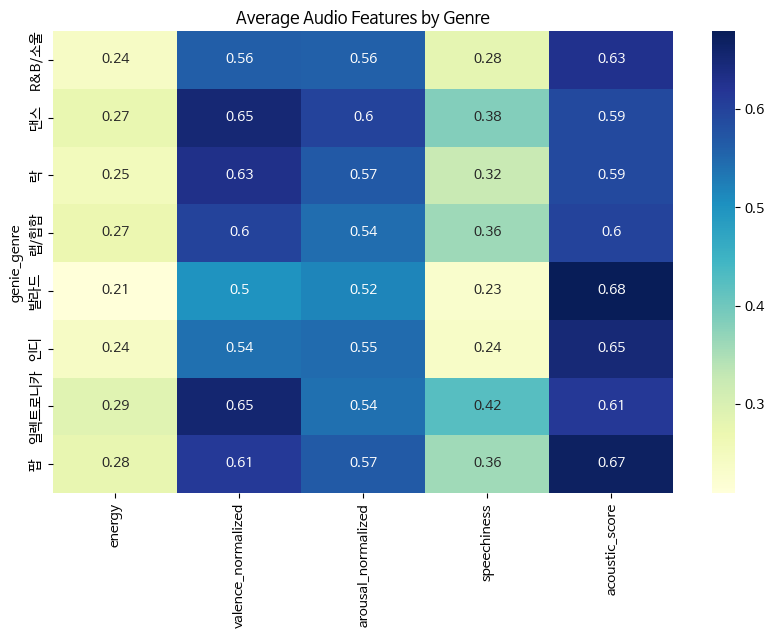

In [ ]:
# 분석할 주요 특징 선택 (정규화된 값 위주)
features_to_compare = ['energy', 'valence_normalized', 'arousal_normalized', 'speechiness', 'acoustic_score']

# 장르별 평균값 계산
genre_profile = 분석_df.groupby('genie_genre')[features_to_compare].mean()

# 결과 확인
print("--- 장르별 오디오 특징 평균 프로필 ---")
print(genre_profile)

# 간단한 히트맵으로 장르별 특징 차이 보기
plt.figure(figsize=(10, 6))
sns.heatmap(genre_profile, annot=True, cmap='YlGnBu')
plt.title('Average Audio Features by Genre')
plt.show()